<a href="https://colab.research.google.com/github/Shafnpt/HE-Fault-detection-and-control-system/blob/main/industrial_data_training_and_validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Imports
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# normal data
df_normal = pd.read_csv('/content/drive/MyDrive/HX_Normal.csv')

df_normal.head()

,Time_hr,Shell_In_Temp_C,Shell_Out_Temp_C,Tube_In_Temp_C,Tube_Out_Temp_C,Shell_Flow_kgph,Tube_Flow_kgph,Heat_Duty_kcalph,Overall_U,DP_Shell_kgfpcm2,DP_Tube_kgfpcm2
0,0.000000,65.444328,39.618152,31.055969,34.729646,125052.5550,923083.4331,3391110.675,605,0.14,0.19
1,0.083333,67.127719,42.134148,32.248472,36.613596,130842.7520,786630.5189,3433739.032,605,0.14,0.19
2,0.166667,63.408560,37.217462,31.501625,35.804807,125968.2336,805034.1615,3464208.620,605,0.14,0.19
3,0.250000,64.880561,39.503111,31.745087,35.844849,128295.5641,833854.4641,3418604.950,605,0.14,0.19
4,0.333333,63.154303,37.077316,32.088929,36.275811,126983.5190,830430.6420,3476914.972,605,0.14,0.19


In [ ]:
# DATA PROPERTIES AND INFO
import pandas as pd
import numpy as np
print(df_normal.shape)
print(df_normal.columns.tolist())
print(df_normal.head())
print(df_normal.info())

(210240, 11)
['Time_hr', 'Shell_In_Temp_C', 'Shell_Out_Temp_C', 'Tube_In_Temp_C', 'Tube_Out_Temp_C', 'Shell_Flow_kgph', 'Tube_Flow_kgph', 'Heat_Duty_kcalph', 'Overall_U', 'DP_Shell_kgfpcm2', 'DP_Tube_kgfpcm2']
    Time_hr  Shell_In_Temp_C  Shell_Out_Temp_C  Tube_In_Temp_C  \
0  0.000000        65.444328         39.618152       31.055969   
1  0.083333        67.127719         42.134148       32.248472   
2  0.166667        63.408560         37.217462       31.501625   
3  0.250000        64.880561         39.503111       31.745087   
4  0.333333        63.154303         37.077316       32.088929   

   Tube_Out_Temp_C  Shell_Flow_kgph  Tube_Flow_kgph  Heat_Duty_kcalph  \
0        34.729646      125052.5550     923083.4331       3391110.675   
1        36.613596      130842.7520     786630.5189       3433739.032   
2        35.804807      125968.2336     805034.1615       3464208.620   
3        35.844849      128295.5641     833854.4641       3418604.950   
4        36.275811      1269

In [ ]:
numerical_cols_clean = df_normal.select_dtypes(include=np.number).columns.tolist()
print("Numerical columns in df_normal:", numerical_cols_clean)

Numerical columns in df_normal: ['Time_hr', 'Shell_In_Temp_C', 'Shell_Out_Temp_C', 'Tube_In_Temp_C', 'Tube_Out_Temp_C', 'Shell_Flow_kgph', 'Tube_Flow_kgph', 'Heat_Duty_kcalph', 'Overall_U', 'DP_Shell_kgfpcm2', 'DP_Tube_kgfpcm2']


In [ ]:
# OUTLIER DETECTION AND REMOVAL
import pandas as pd
import numpy as np
def remove_outliers_iqr(df, col):
    """Removes outliers from a DataFrame column using the IQR method."""
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_cleaned = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)].copy()
    return df_cleaned

clean_df = df_normal.copy() # Initialize clean_df with a copy of df_normal

print("Shape of clean_df before outlier removal:", clean_df.shape)

for col in numerical_cols_clean:
    clean_df = remove_outliers_iqr(clean_df, col)

print("Shape of clean_df after outlier removal:", clean_df.shape)
display(clean_df.head())

Shape of clean_df before outlier removal: (210240, 11)
Shape of clean_df after outlier removal: (205655, 11)


,Time_hr,Shell_In_Temp_C,Shell_Out_Temp_C,Tube_In_Temp_C,Tube_Out_Temp_C,Shell_Flow_kgph,Tube_Flow_kgph,Heat_Duty_kcalph,Overall_U,DP_Shell_kgfpcm2,DP_Tube_kgfpcm2
0,0.000000,65.444328,39.618152,31.055969,34.729646,125052.5550,923083.4331,3391110.675,605,0.14,0.19
1,0.083333,67.127719,42.134148,32.248472,36.613596,130842.7520,786630.5189,3433739.032,605,0.14,0.19
2,0.166667,63.408560,37.217462,31.501625,35.804807,125968.2336,805034.1615,3464208.620,605,0.14,0.19
3,0.250000,64.880561,39.503111,31.745087,35.844849,128295.5641,833854.4641,3418604.950,605,0.14,0.19
4,0.333333,63.154303,37.077316,32.088929,36.275811,126983.5190,830430.6420,3476914.972,605,0.14,0.19


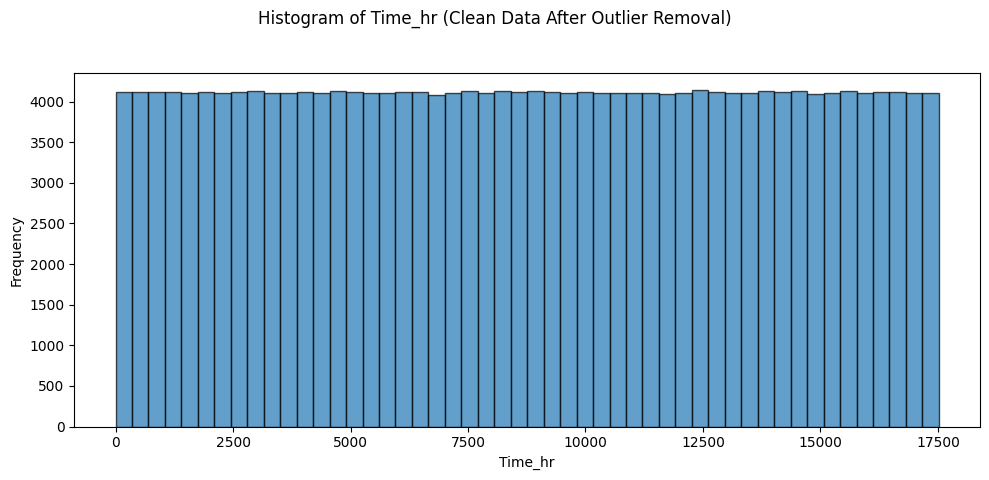

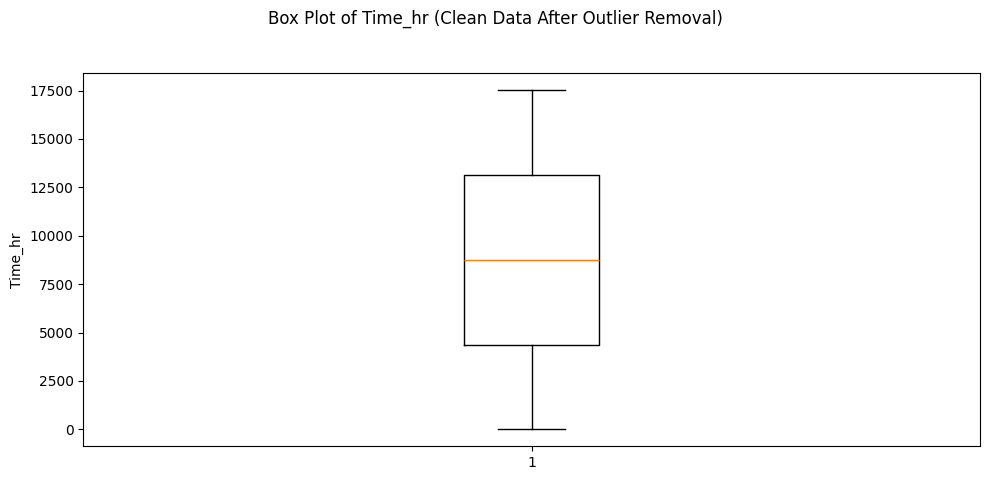

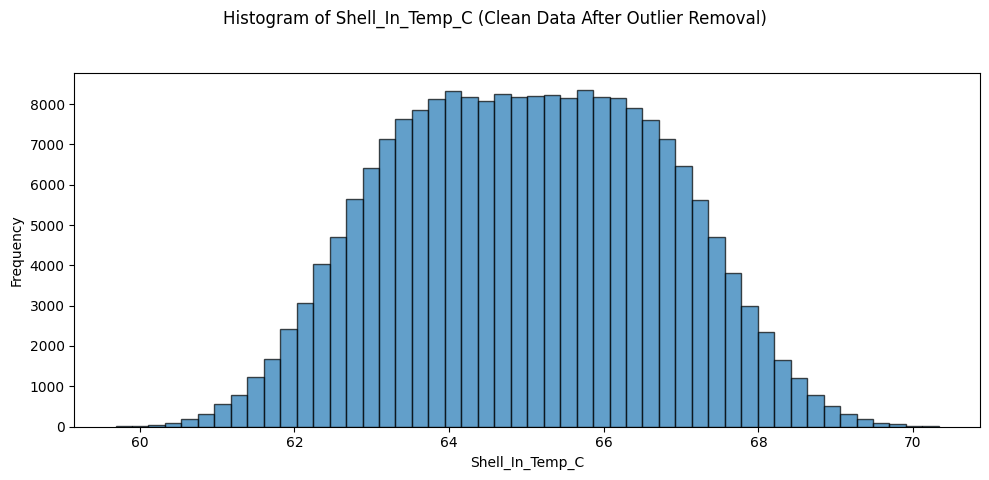

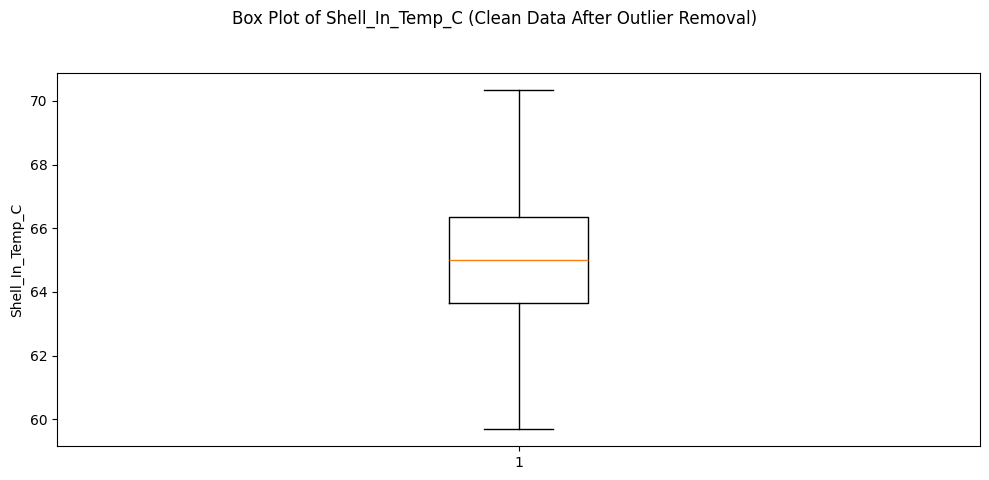

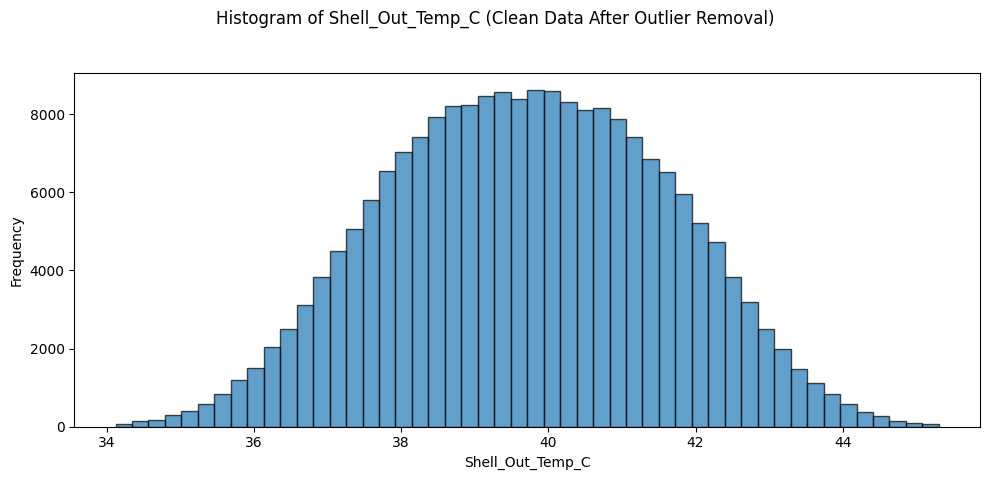

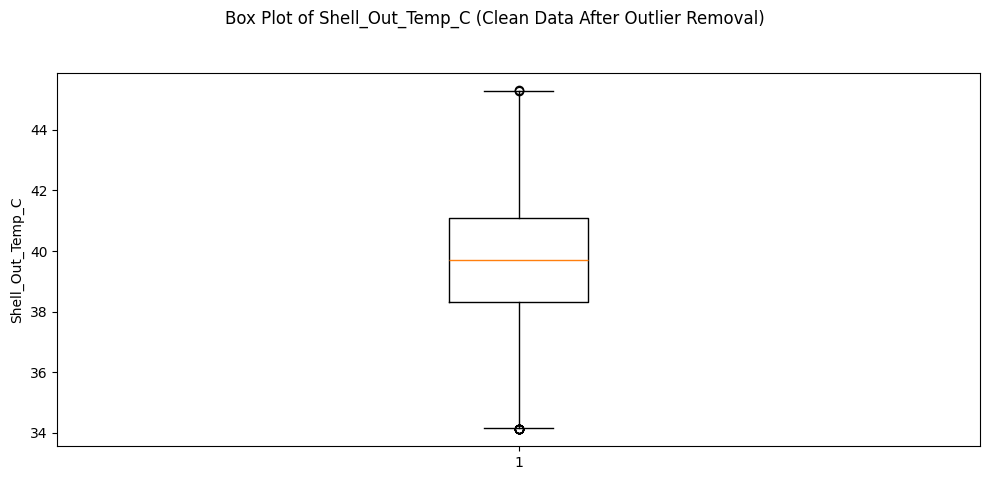

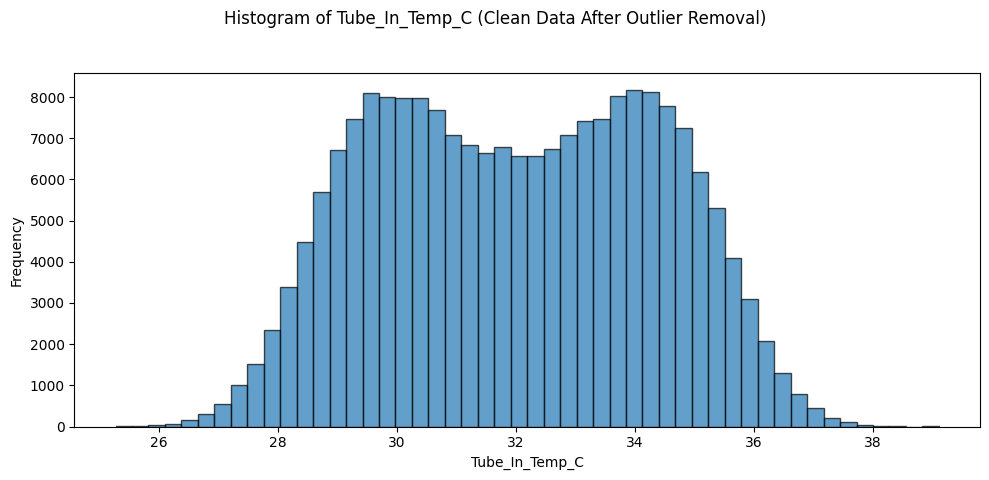

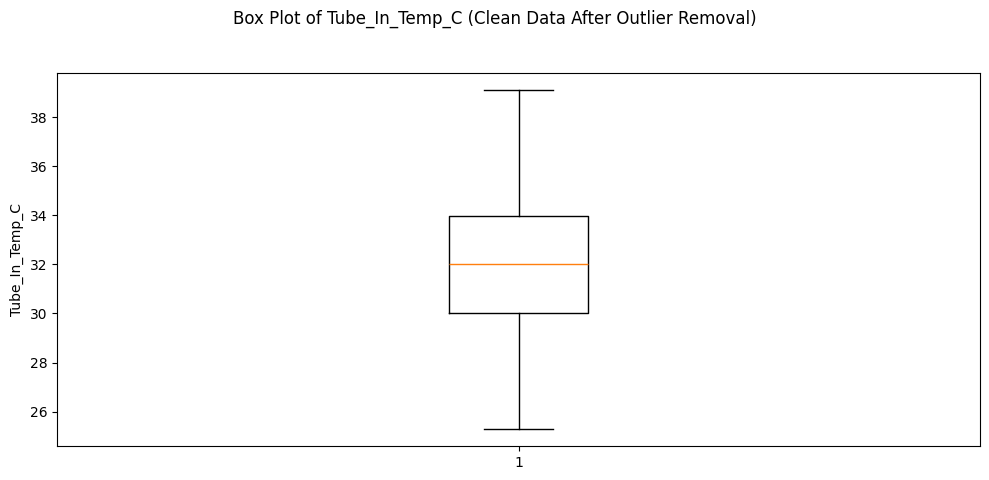

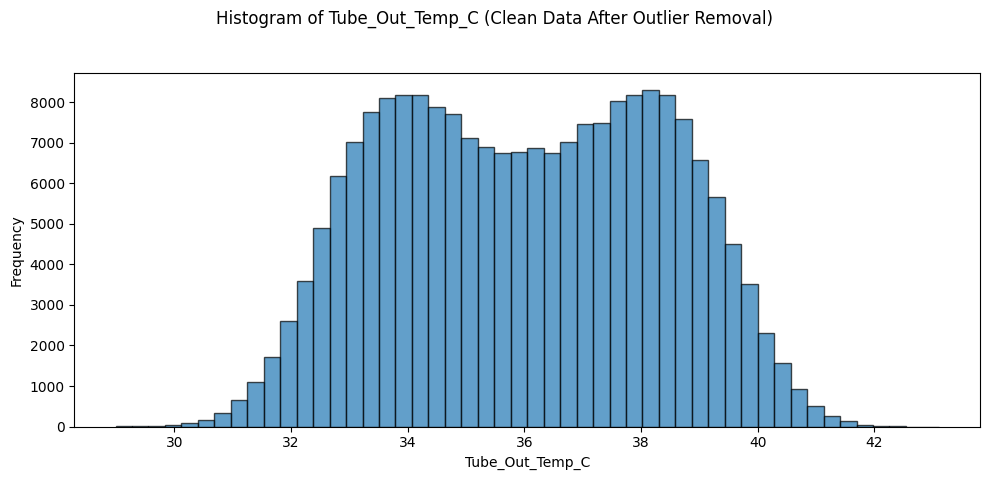

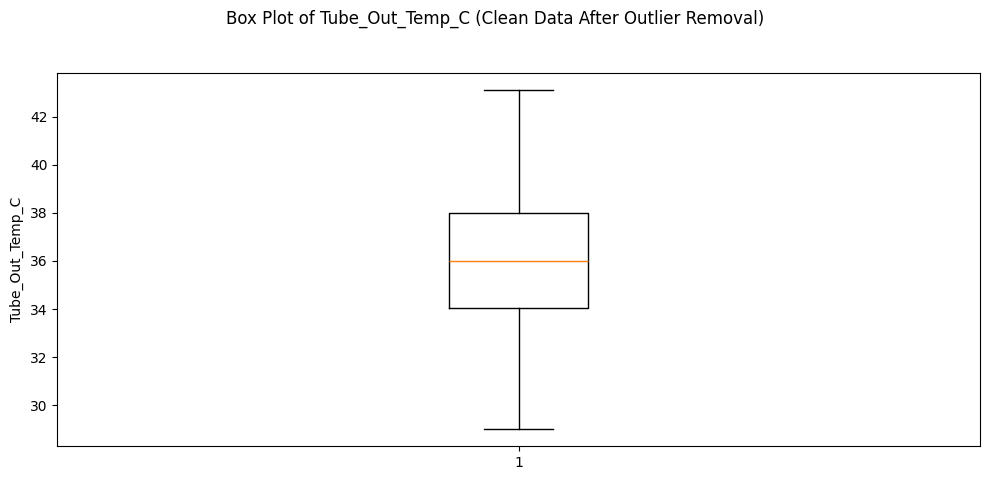

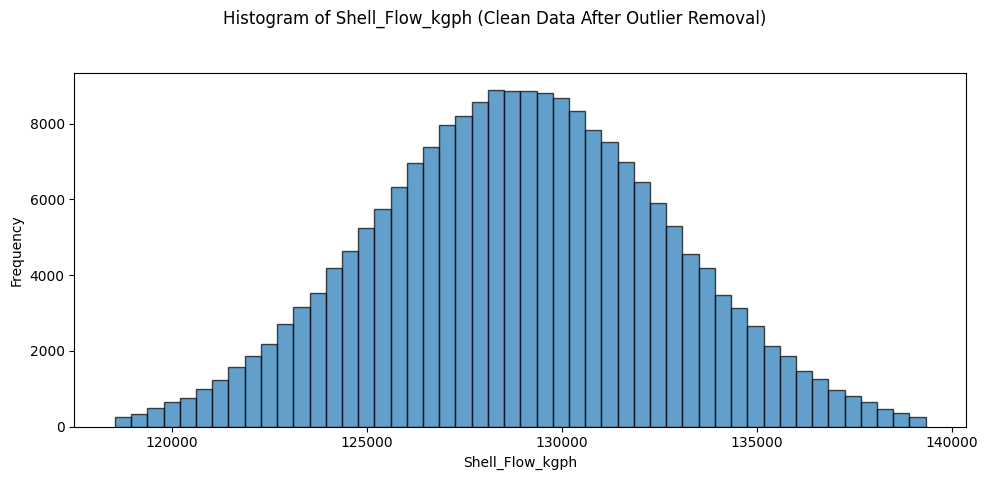

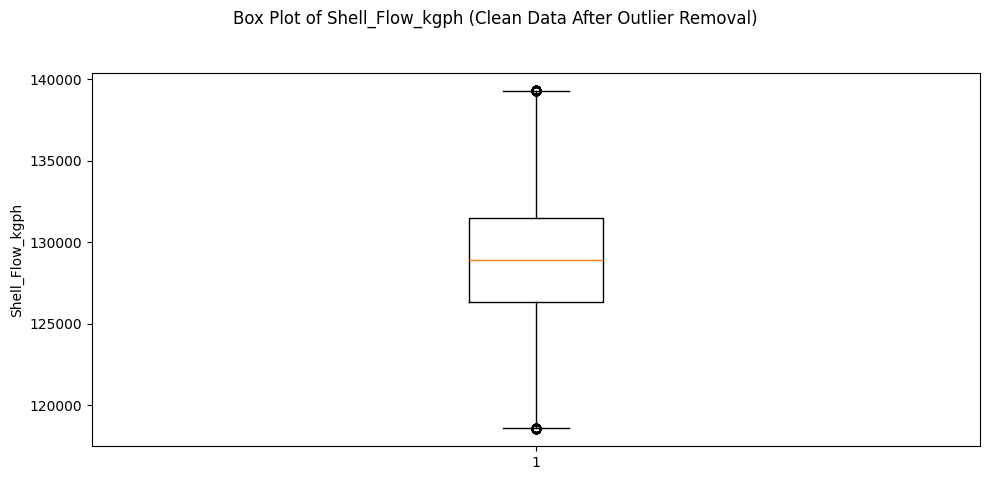

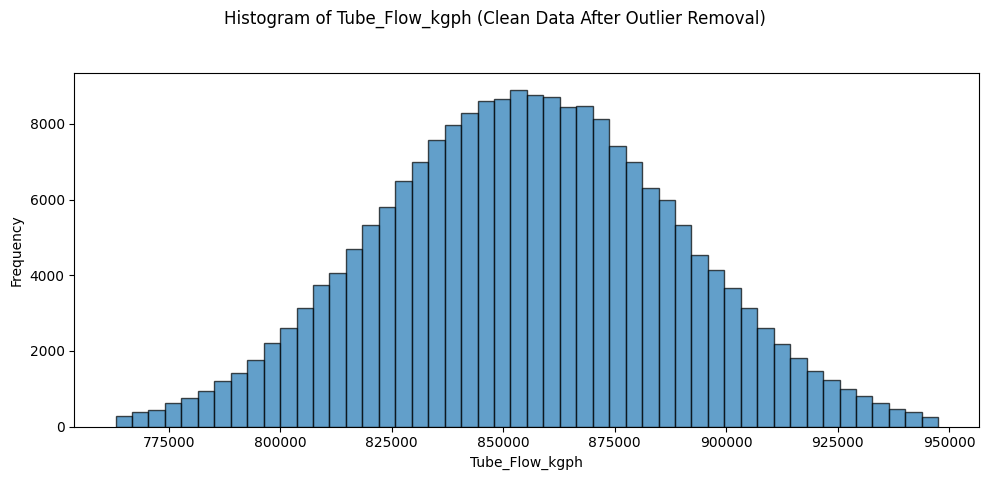

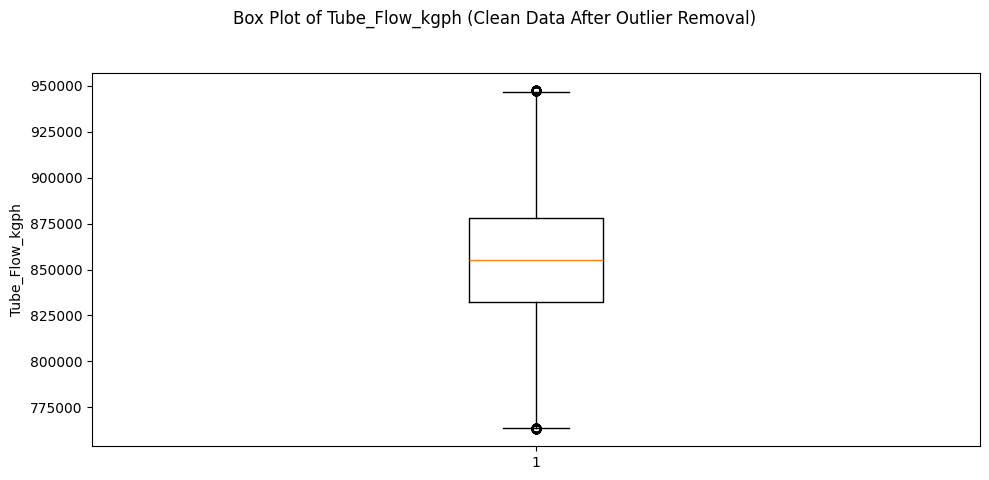

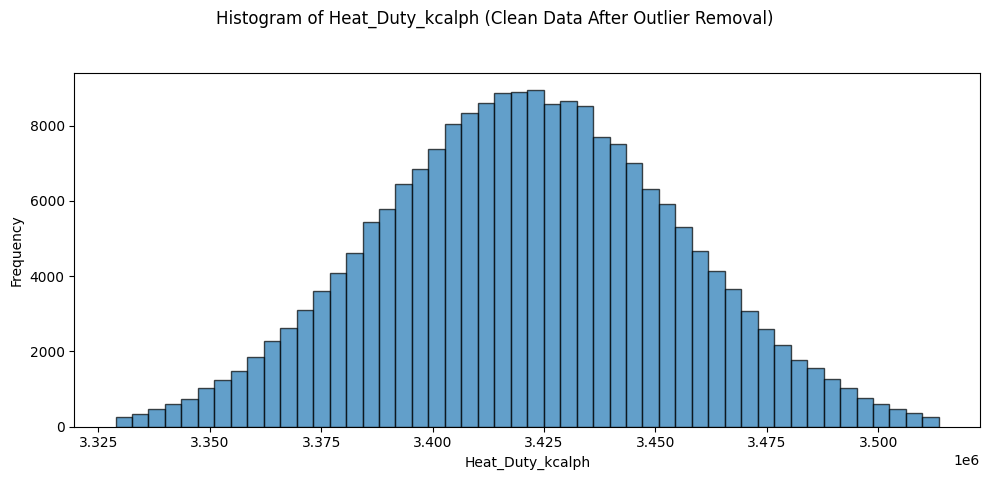

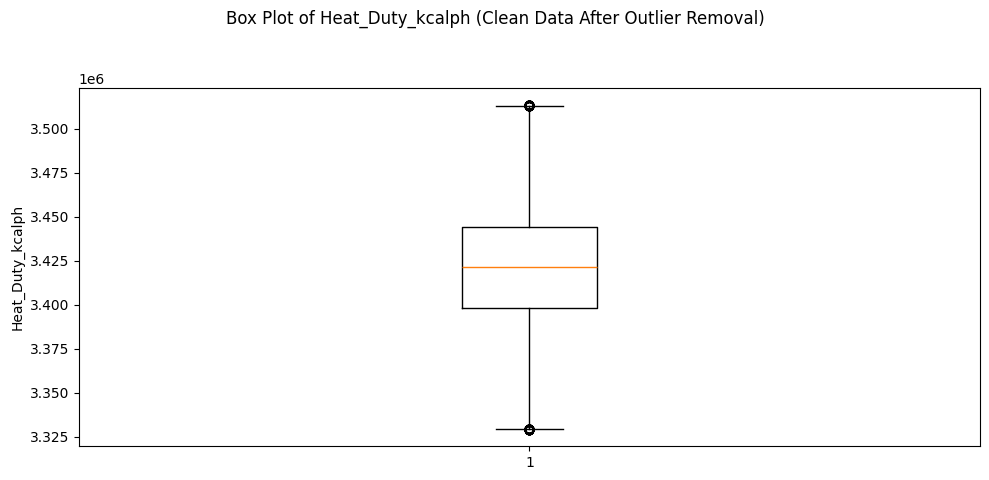

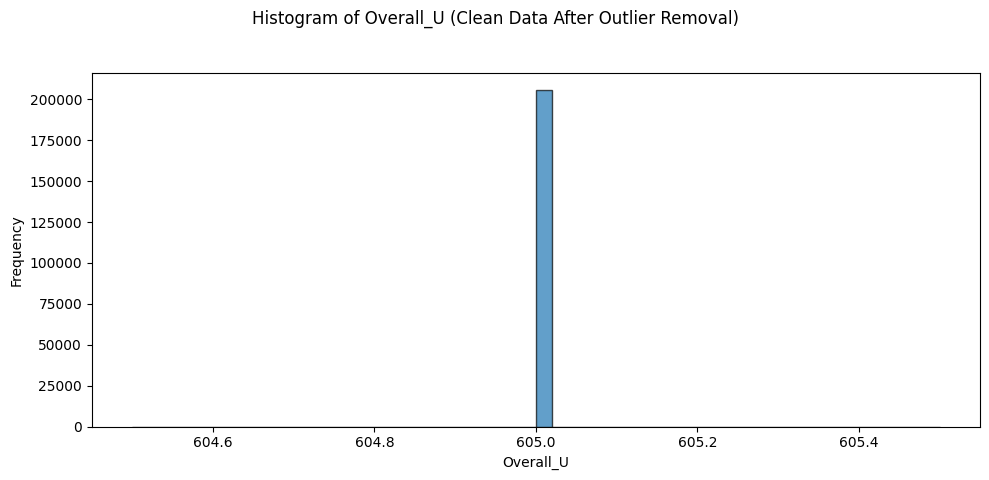

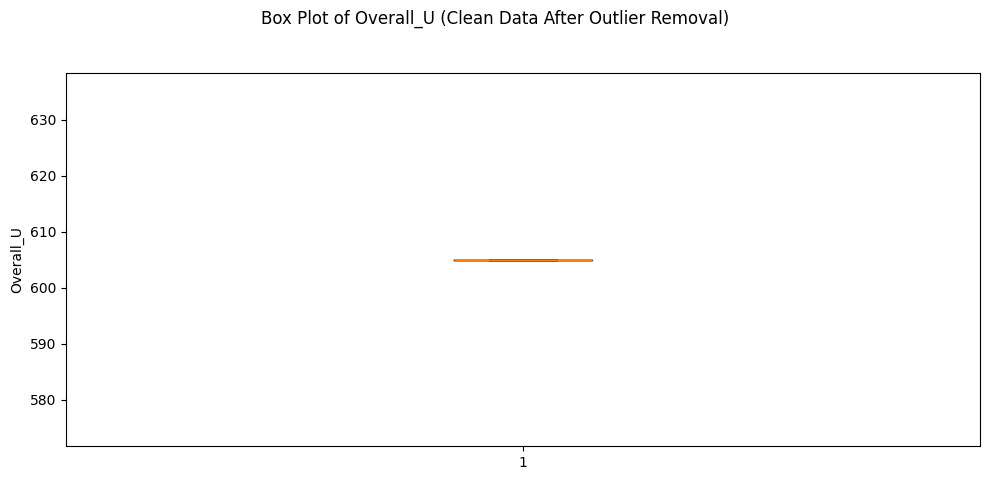

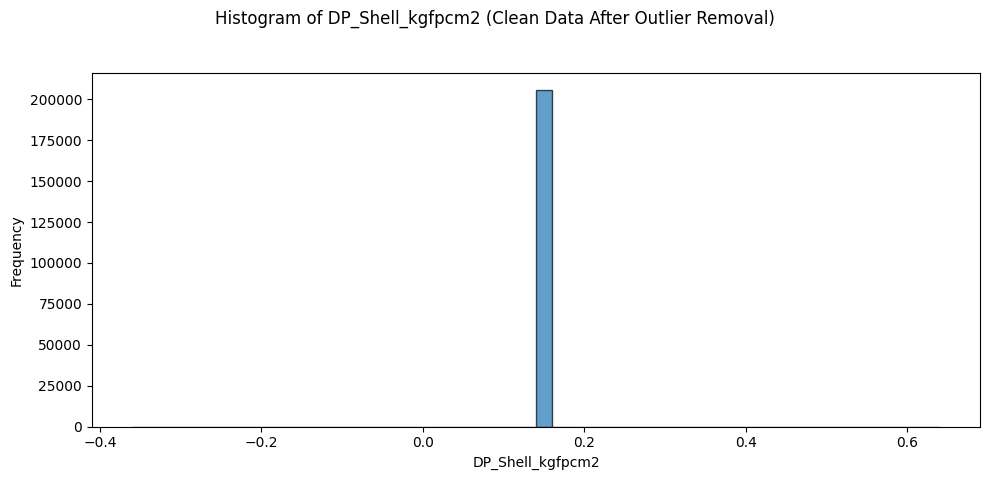

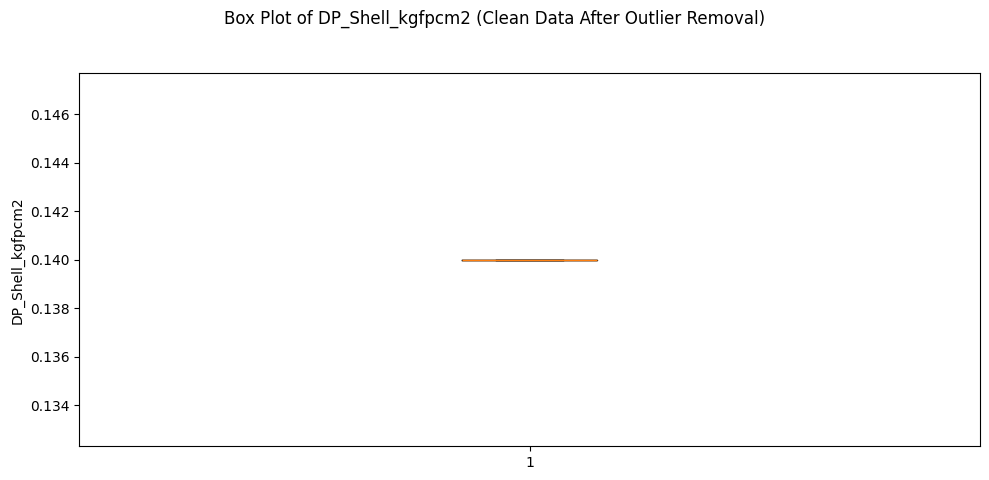

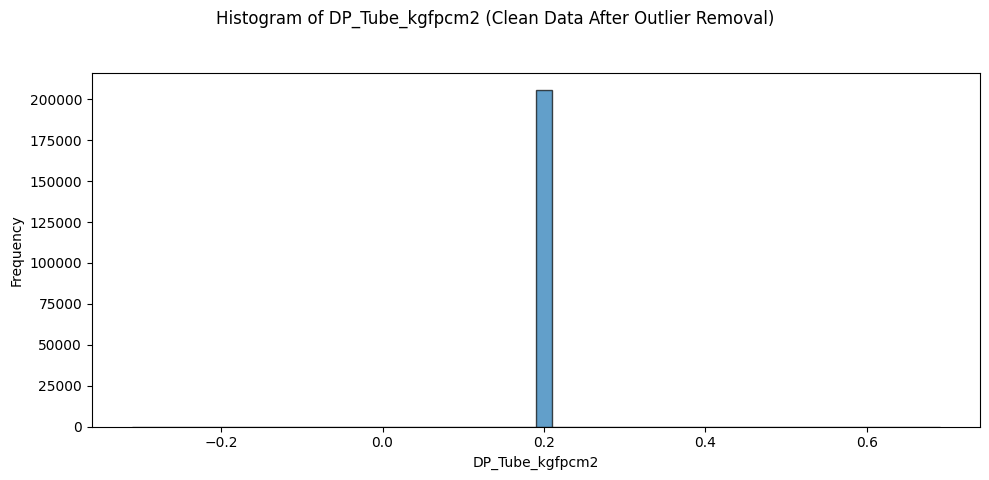

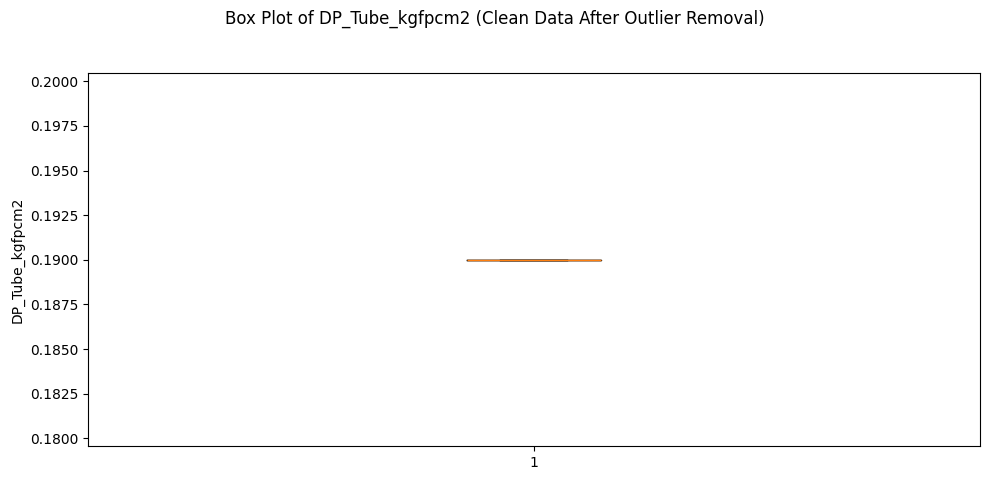

In [ ]:
import matplotlib.pyplot as plt

# data visual after outlier removal
for col in numerical_cols_clean:
    # Create figure for histograms
    fig_hist, axes_hist = plt.subplots(1, 1, figsize=(10, 5))
    fig_hist.suptitle(f'Histogram of {col} (Clean Data After Outlier Removal)')

    # Histogram for cleaned data
    axes_hist.hist(clean_df[col], bins=50, edgecolor='k', alpha=0.7)
    axes_hist.set_xlabel(col)
    axes_hist.set_ylabel('Frequency')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    # Create figure for box plots
    fig_box, axes_box = plt.subplots(1, 1, figsize=(10, 5))
    fig_box.suptitle(f'Box Plot of {col} (Clean Data After Outlier Removal)')

    # Box plot for cleaned data
    axes_box.boxplot(clean_df[col])
    axes_box.set_ylabel(col)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [ ]:
# Save the dataframe with outliers removed from clean_df
clean_df.to_csv('/content/drive/MyDrive/HX_Normal_outliers_removed.csv', index=False)

print("Cleaned dataframes saved successfully.")

Cleaned dataframes saved successfully.


In [ ]:
#Autodetecting time,T,P,Flow columns
df = pd.read_csv('/content/drive/MyDrive/HX_Normal_outliers_removed.csv')

print("Dataset shape:", df.shape)
print("\nColumns:")
for c in df.columns:
    print(" -", c)

print("\nRows:")
display(df.head())


# Time handling, duplicates, and missing-value basic strategy
# Try to detect time column automatically

time_col = None
for c in df.columns:
    if "time" in c.lower() or "date" in c.lower():
        time_col = c
        break

if time_col:
    print("Detected time column:", time_col)
    df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
else:
    print("No time column found — creating synthetic time index (10s step).")
    df["time"] = pd.to_timedelta(np.arange(len(df))*10, unit="s")
    time_col = "time"

# Drop exact duplicates
before = len(df)
df.drop_duplicates(inplace=True)
print(f"Dropped {before - len(df)} duplicate rows")

# Fill missing values: interpolate then ffill/bfill
num_missing_before = df.isna().sum().sum()
df = df.interpolate(method="linear", limit_direction="both")
df = df.fillna(method="ffill").fillna(method="bfill")
num_missing_after = df.isna().sum().sum()
print(f"Missing values before: {num_missing_before}, after cleaning: {num_missing_after}")

display(df[[time_col]].head())

# Detect pressure, flow, and temperature columns (auto-detect)
cols = df.columns.tolist()

# Common names we'll look for (adjust if your file uses different labels)
candidates = {
    "pressure_hot": ["hot_outlet_pressure_pa","hot_pressure","pressure_hot","P_hot","Hot_Pressure"],
    "pressure_cold": ["cold_outlet_pressure_pa","cold_pressure","pressure_cold","P_cold","Cold_Pressure"],
    "flow_hot": ["hot_outlet_mass_flow_kg_s", "hot_mass_flow", "Flow_hot","flow_hot","flowHot","hot_flow"],
    "flow_cold": ["cold_inlet_mass_flow_kg_s", "cold_outlet_mass_flow_kg_s", "cold_mass_flow", "Flow_cold","flow_cold","flowCold","cold_flow"],
    "T_hot_in": ["hot_inlet_temperature_k", "T_hot_in","Th_in","T_hot_inlet","T_hot_inlet"],
    "T_hot_out": ["hot_outlet_temperature_k", "T_hot_out","Th_out","T_hot_outlet"],
    "T_cold_in": ["cold_inlet_temperature_k", "T_cold_in","Tc_in","T_cold_inlet"],
    "T_cold_out": ["cold_outlet_temperature_k", "T_cold_out","Tc_out","T_cold_outlet"]
}

found = {}
for key, names in candidates.items():
    found[key] = None
    for n in names:
        if n in cols:
            found[key] = n
            break

print("Auto-detected column mapping (None = not found):")
for k,v in found.items():
    print(f" {k:12s} -> {v}")

# If any important column is None, show a hint for manual selection
missing = [k for k,v in found.items() if v is None]
if missing:
    print("\nPlease verify column names for:", missing)
    print("Available columns:", cols)

Dataset shape: (205655, 11)

Columns:
 - Time_hr
 - Shell_In_Temp_C
 - Shell_Out_Temp_C
 - Tube_In_Temp_C
 - Tube_Out_Temp_C
 - Shell_Flow_kgph
 - Tube_Flow_kgph
 - Heat_Duty_kcalph
 - Overall_U
 - DP_Shell_kgfpcm2
 - DP_Tube_kgfpcm2

Rows:


,Time_hr,Shell_In_Temp_C,Shell_Out_Temp_C,Tube_In_Temp_C,Tube_Out_Temp_C,Shell_Flow_kgph,Tube_Flow_kgph,Heat_Duty_kcalph,Overall_U,DP_Shell_kgfpcm2,DP_Tube_kgfpcm2
0,0.000000,65.444328,39.618152,31.055969,34.729646,125052.5550,923083.4331,3391110.675,605,0.14,0.19
1,0.083333,67.127719,42.134148,32.248472,36.613596,130842.7520,786630.5189,3433739.032,605,0.14,0.19
2,0.166667,63.408560,37.217462,31.501625,35.804807,125968.2336,805034.1615,3464208.620,605,0.14,0.19
3,0.250000,64.880561,39.503111,31.745087,35.844849,128295.5641,833854.4641,3418604.950,605,0.14,0.19
4,0.333333,63.154303,37.077316,32.088929,36.275811,126983.5190,830430.6420,3476914.972,605,0.14,0.19


Detected time column: Time_hr
Dropped 0 duplicate rows
Missing values before: 0, after cleaning: 0


/tmp/ipython-input-3534669176.py:38: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method="ffill").fillna(method="bfill")


,Time_hr
0,1970-01-01
1,1970-01-01
2,1970-01-01
3,1970-01-01
4,1970-01-01


Auto-detected column mapping (None = not found):
 pressure_hot -> None
 pressure_cold -> None
 flow_hot     -> None
 flow_cold    -> None
 T_hot_in     -> None
 T_hot_out    -> None
 T_cold_in    -> None
 T_cold_out   -> None

Please verify column names for: ['pressure_hot', 'pressure_cold', 'flow_hot', 'flow_cold', 'T_hot_in', 'T_hot_out', 'T_cold_in', 'T_cold_out']
Available columns: ['Time_hr', 'Shell_In_Temp_C', 'Shell_Out_Temp_C', 'Tube_In_Temp_C', 'Tube_Out_Temp_C', 'Shell_Flow_kgph', 'Tube_Flow_kgph', 'Heat_Duty_kcalph', 'Overall_U', 'DP_Shell_kgfpcm2', 'DP_Tube_kgfpcm2']


In [ ]:
# Manual mapping of columns
found["pressure_hot"] = "DP_Shell_kgfpcm2"
found["pressure_cold"] = "DP_Tube_kgfpcm2"
found["flow_hot"] = "Shell_Flow_kgph"
found["flow_cold"] = "Tube_Flow_kgph"
found["T_hot_in"] = "Shell_In_Temp_C"
found["T_hot_out"] = "Shell_Out_Temp_C"
found["T_cold_in"] = "Tube_In_Temp_C"
found["T_cold_out"] = "Tube_Out_Temp_C"

print("Manually mapped column mapping:")
for k,v in found.items():
    print(f" {k:12s} -> {v}")

NameError: name 'found' is not defined

In [ ]:
# ================================================================
#  Derived variables (ΔP, ΔT_hot, ΔT_cold, Flow Change)
# ================================================================

# ---- Column Mapping (auto-detected earlier or edit manually if needed) ----
PH = found.get("pressure_hot")     # e.g. 'hot_outlet_pressure_pa'
PC = found.get("pressure_cold")    # e.g. 'cold_outlet_pressure_pa'
FH = found.get("flow_hot")         # e.g. 'Flow_hot'
FC = found.get("flow_cold")        # e.g. 'Flow_cold'
Th_in = found.get("T_hot_in")      # e.g. 'T_hot_in'
Th_out = found.get("T_hot_out")    # e.g. 'T_hot_out'
Tc_in = found.get("T_cold_in")     # e.g. 'T_cold_in'
Tc_out = found.get("T_cold_out")   # e.g. 'T_cold_out'

# ✅ Skip LMTD computation if it already exists
if "LMTD" in df.columns:
    print("ℹ️ Existing 'LMTD' column detected — skipping recalculation.")
else:
    print("⚙️ 'LMTD' not found — computing from temperature differences.")
    if all([Th_in, Th_out, Tc_in, Tc_out]):
        ΔT1 = df[Th_in] - df[Tc_out]
        ΔT2 = df[Th_out] - df[Tc_in]
        eps = 1e-6
        ΔT1 = np.where(ΔT1 <= 0, eps, ΔT1)
        ΔT2 = np.where(ΔT2 <= 0, eps, ΔT2)
        df["LMTD"] = (ΔT1 - ΔT2) / np.log(np.maximum(ΔT1 / ΔT2, eps))
        df["LMTD"].replace([np.inf, -np.inf], np.nan, inplace=True)
        df["LMTD"].fillna(df["LMTD"].mean(), inplace=True)
    else:
        df["LMTD"] = np.nan

# ---- Pressure Drop (ΔP) ----
if PH and PC:
    df["Pressure_Drop"] = df[PH].astype(float) - df[PC].astype(float)
elif PH:
    df["Pressure_Drop"] = np.gradient(df[PH].astype(float))
else:
    df["Pressure_Drop"] = 0.0

# ---- Temperature Differences ----
if Th_in and Th_out:
    df["DeltaT_hot"] = df[Th_in] - df[Th_out]
else:
    df["DeltaT_hot"] = np.nan

if Tc_out and Tc_in:
    df["DeltaT_cold"] = df[Tc_out] - df[Tc_in]
else:
    df["DeltaT_cold"] = np.nan

# ---- Flow Rate Changes ----
if FH:
    df["FH_Change"] = df[FH].diff().fillna(0)
if FC:
    df["FC_Change"] = df[FC].diff().fillna(0)

# ---- Display Key Columns ----
cols_to_display = [time_col, PH, PC, "Pressure_Drop", "FH_Change", "FC_Change",
                   "DeltaT_hot", "DeltaT_cold"]
cols_to_display = [c for c in cols_to_display if c in df.columns]
print("✅ Derived columns calculated successfully.")
display(df[cols_to_display].head())


⚙️ 'LMTD' not found — computing from temperature differences.
✅ Derived columns calculated successfully.


/tmp/ipython-input-2467195099.py:27: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["LMTD"].replace([np.inf, -np.inf], np.nan, inplace=True)
/tmp/ipython-input-2467195099.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=T

,Time_hr,DP_Shell_kgfpcm2,DP_Tube_kgfpcm2,Pressure_Drop,FH_Change,FC_Change,DeltaT_hot,DeltaT_cold
0,1970-01-01,0.14,0.19,-0.05,0.0000,0.0000,25.826175,3.673677
1,1970-01-01,0.14,0.19,-0.05,5790.1970,-136452.9142,24.993571,4.365123
2,1970-01-01,0.14,0.19,-0.05,-4874.5184,18403.6426,26.191098,4.303182
3,1970-01-01,0.14,0.19,-0.05,2327.3305,28820.3026,25.377450,4.099762
4,1970-01-01,0.14,0.19,-0.05,-1312.0451,-3423.8221,26.076987,4.186882


In [ ]:
# ----------------------------------------------------------------
# Additional Derived Features for Classification
# ----------------------------------------------------------------

# Temperature Efficiency (Effectiveness) - simplified
# Using the 'found' mappings for clarity
epsilon = 1e-6 # Small value to avoid division by zero
df["Temp_Efficiency"] = (df[found["T_cold_out"]] - df[found["T_cold_in"]]) / \
                          (df[found["T_hot_in"]] - df[found["T_cold_in"]] + epsilon)
df["Temp_Efficiency"] = df["Temp_Efficiency"].replace([np.inf, -np.inf], np.nan).fillna(0)

# Flow Ratio (e.g., hot flow / cold flow)
df["Flow_Ratio"] = df[found["flow_hot"]] / (df[found["flow_cold"]] + epsilon)
df["Flow_Ratio"] = df["Flow_Ratio"].replace([np.inf, -np.inf], np.nan).fillna(0)

# Derivative of Pressure Drop with respect to time
# Convert time differences to seconds for consistent units
time_diff_seconds = df[time_col].diff().dt.total_seconds().fillna(1) # Fillna 1 to avoid division by zero at start
df["dP_dt"] = df["Pressure_Drop"].diff() / time_diff_seconds
df["dP_dt"] = df["dP_dt"].replace([np.inf, -np.inf], np.nan).fillna(0)

print("✅ Additional features 'Temp_Efficiency', 'Flow_Ratio', and 'dP_dt' created successfully.")

✅ Additional features 'Temp_Efficiency', 'Flow_Ratio', and 'dP_dt' created successfully.


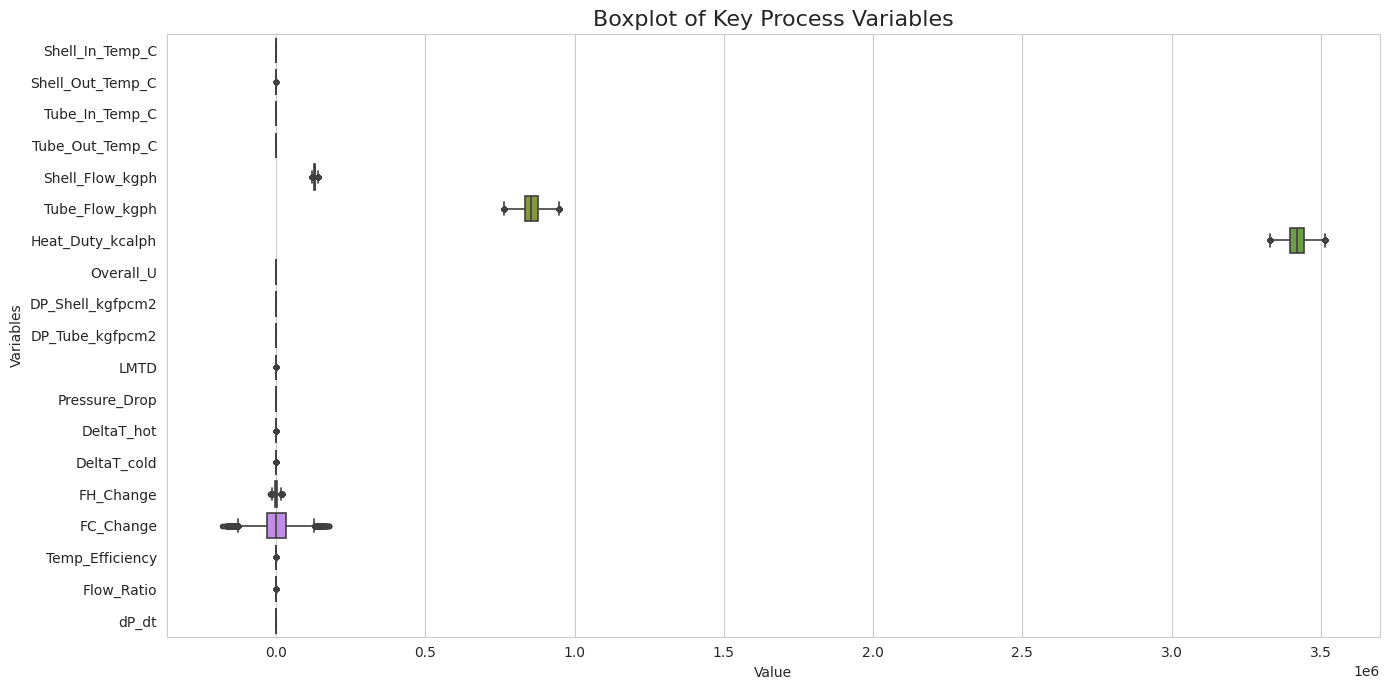

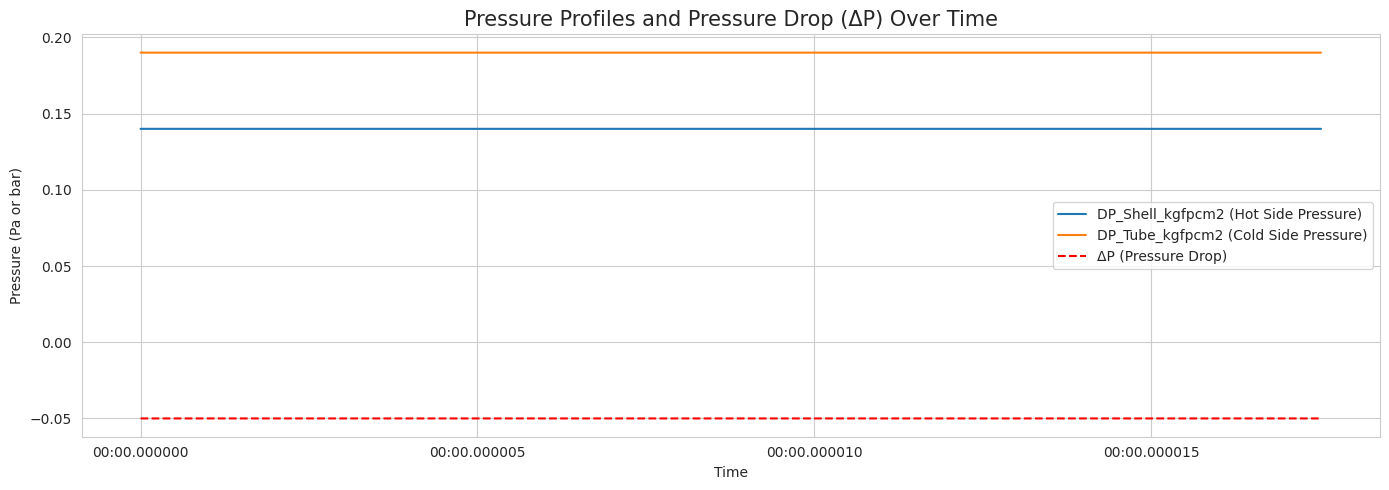

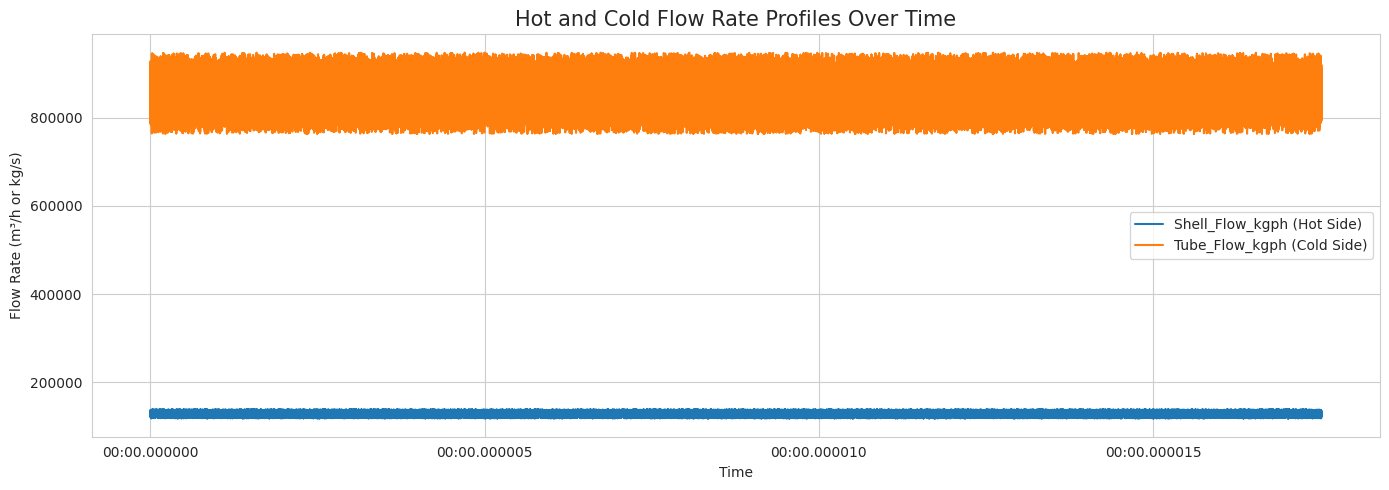

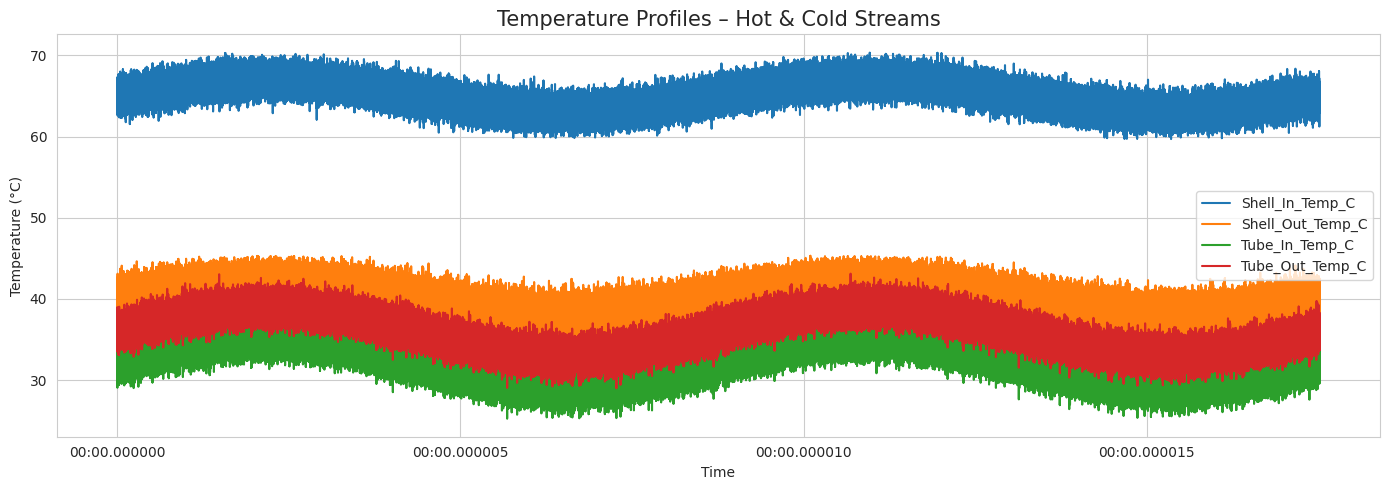

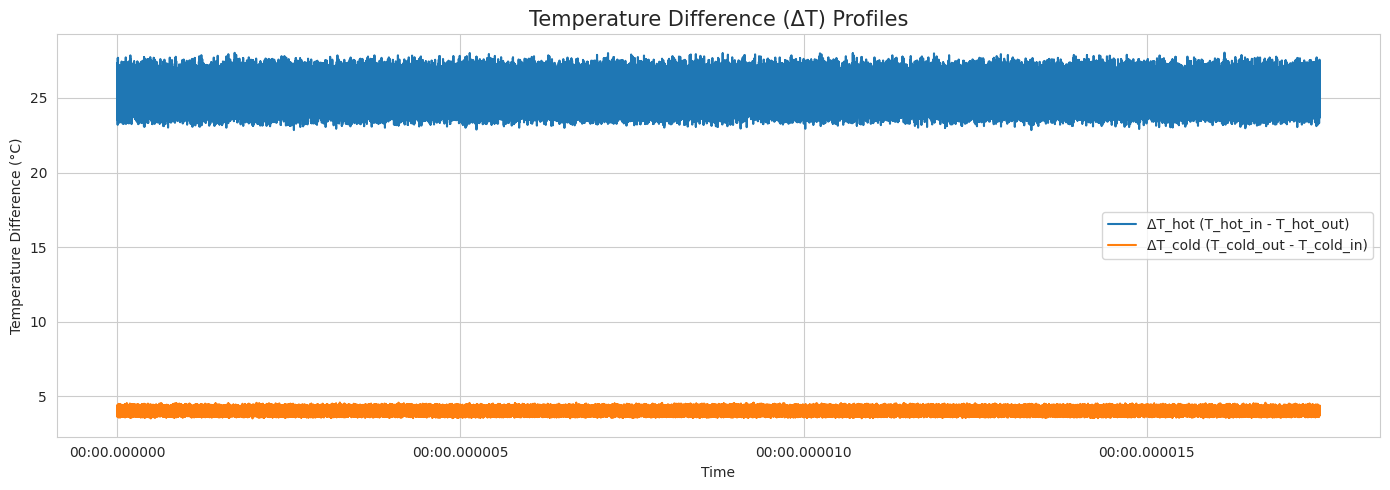

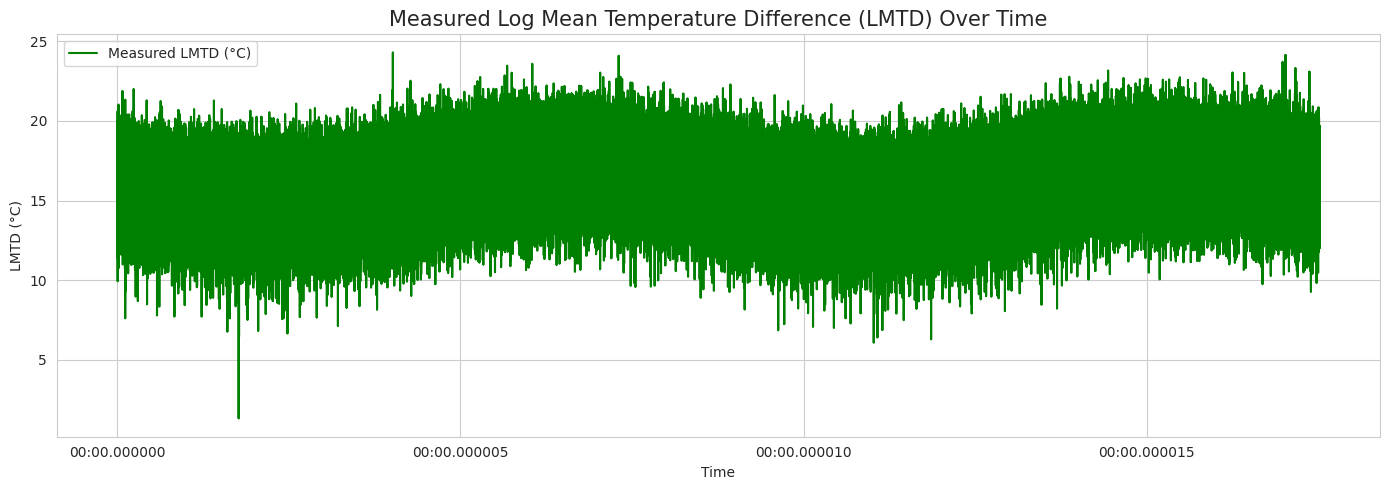

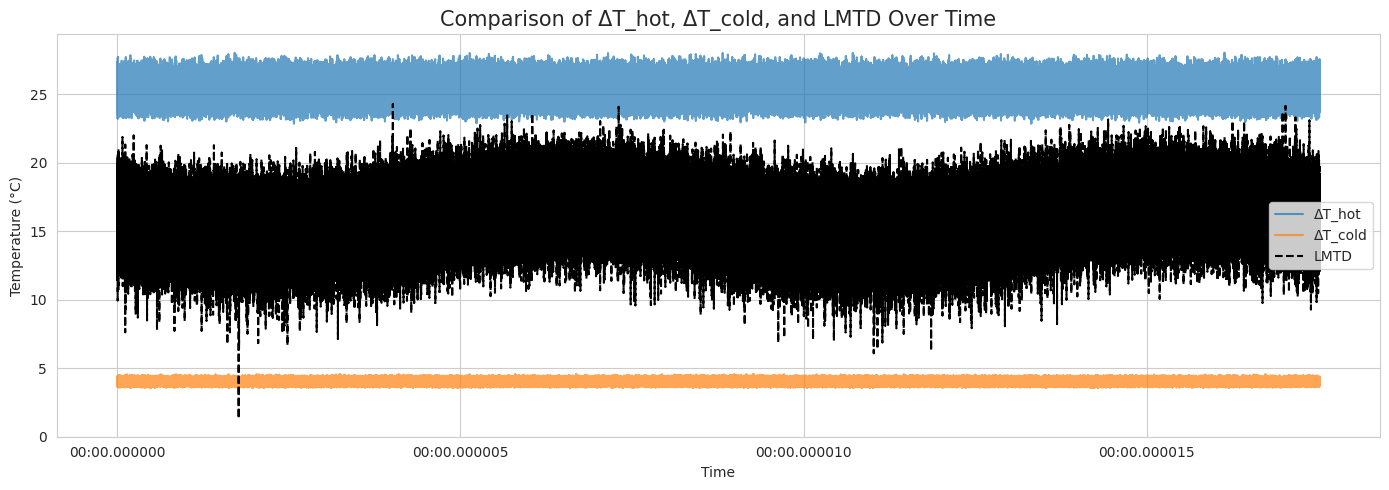

✅ Visualization Completed: Pressure, Flow, Temperature, ΔT, and LMTD plotted successfully.


In [ ]:
# ================================================================
# Visualization – Pressure, Flow, Temperature, ΔT, and LMTD
# ================================================================

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14,5)

# -------------------- 6.1 Boxplot for numeric variables --------------------
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(14,7))
sns.boxplot(data=df[num_cols].fillna(0), orient="h", linewidth=1.2, fliersize=3)
plt.title("Boxplot of Key Process Variables", fontsize=16)
plt.xlabel("Value")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()

# -------------------- 6.2 Pressure Profiles --------------------
plt.figure(figsize=(14,5))
if PH: plt.plot(df[time_col], df[PH], label=f"{PH} (Hot Side Pressure)")
if PC: plt.plot(df[time_col], df[PC], label=f"{PC} (Cold Side Pressure)")
plt.plot(df[time_col], df["Pressure_Drop"], 'r--', label='ΔP (Pressure Drop)')
plt.legend()
plt.title("Pressure Profiles and Pressure Drop (ΔP) Over Time", fontsize=15)
plt.xlabel("Time")
plt.ylabel("Pressure (Pa or bar)")
plt.grid(True)
plt.tight_layout()
plt.show()

# -------------------- 6.3 Flow Profiles --------------------
plt.figure(figsize=(14,5))
if FH: plt.plot(df[time_col], df[FH], label=f"{FH} (Hot Side)")
if FC: plt.plot(df[time_col], df[FC], label=f"{FC} (Cold Side)")
plt.legend()
plt.title("Hot and Cold Flow Rate Profiles Over Time", fontsize=15)
plt.xlabel("Time")
plt.ylabel("Flow Rate (m³/h or kg/s)")
plt.grid(True)
plt.tight_layout()
plt.show()

# -------------------- 6.4 Temperature Profiles --------------------
plt.figure(figsize=(14,5))
for t in [Th_in, Th_out, Tc_in, Tc_out]:
    if t in df.columns:
        plt.plot(df[time_col], df[t], label=t)
plt.legend()
plt.title("Temperature Profiles – Hot & Cold Streams", fontsize=15)
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.tight_layout()
plt.show()

# -------------------- 6.5 Temperature Differences --------------------
if "DeltaT_hot" in df.columns and "DeltaT_cold" in df.columns:
    plt.figure(figsize=(14,5))
    plt.plot(df[time_col], df["DeltaT_hot"], label="ΔT_hot (T_hot_in - T_hot_out)")
    plt.plot(df[time_col], df["DeltaT_cold"], label="ΔT_cold (T_cold_out - T_cold_in)")
    plt.legend()
    plt.title("Temperature Difference (ΔT) Profiles", fontsize=15)
    plt.xlabel("Time")
    plt.ylabel("Temperature Difference (°C)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# -------------------- 6.6 LMTD Variation (using inbuilt LMTD) --------------------
if "LMTD" in df.columns:
    plt.figure(figsize=(14,5))
    plt.plot(df[time_col], df["LMTD"], color='green', lw=1.5, label="Measured LMTD (°C)")
    plt.legend()
    plt.title("Measured Log Mean Temperature Difference (LMTD) Over Time", fontsize=15)
    plt.xlabel("Time")
    plt.ylabel("LMTD (°C)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ LMTD column not found in dataset. Skipping LMTD plot.")

# -------------------- 6.7 Combined Overview (ΔT vs LMTD) --------------------
if all(c in df.columns for c in ["DeltaT_hot", "DeltaT_cold", "LMTD"]):
    plt.figure(figsize=(14,5))
    plt.plot(df[time_col], df["DeltaT_hot"], label="ΔT_hot", alpha=0.7)
    plt.plot(df[time_col], df["DeltaT_cold"], label="ΔT_cold", alpha=0.7)
    plt.plot(df[time_col], df["LMTD"], 'k--', label="LMTD")
    plt.legend()
    plt.title("Comparison of ΔT_hot, ΔT_cold, and LMTD Over Time", fontsize=15)
    plt.xlabel("Time")
    plt.ylabel("Temperature (°C)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

print("✅ Visualization Completed: Pressure, Flow, Temperature, ΔT, and LMTD plotted successfully.")

📊 Statistical Summary of Cleaned Dataset



,mean,std,min,max,25%,50%,75%,missing_%
Time_hr,1970-01-01 00:00:00.000008758,NaN,1970-01-01 00:00:00,1970-01-01 00:00:00.000017519,1970-01-01 00:00:00.000004377,1970-01-01 00:00:00.000008759,1970-01-01 00:00:00.000013140,0.0
Shell_In_Temp_C,65.00431,1.729994,59.687331,70.333115,63.667808,65.006461,66.341207,0.0
Shell_Out_Temp_C,39.710715,1.894228,34.119076,45.306198,38.320904,39.711669,41.106317,0.0
Tube_In_Temp_C,32.001108,2.342074,25.274539,39.108456,30.03241,31.999606,33.970666,0.0
Tube_Out_Temp_C,36.006951,2.348154,28.994746,43.10621,34.038361,36.01038,37.980315,0.0
Shell_Flow_kgph,128929.078211,3749.648306,118530.5142,139329.9664,126350.7985,128935.739,131513.8545,0.0
Tube_Flow_kgph,855351.782351,33199.573156,763086.715,947519.4033,832454.8097,855316.5098,878191.443,0.0
Heat_Duty_kcalph,3421232.808783,33259.485108,3328862.417,3513602.982,3398308.2785,3421196.923,3444150.2715,0.0
Overall_U,605.0,0.0,605.0,605.0,605.0,605.0,605.0,0.0
DP_Shell_kgfpcm2,0.14,0.0,0.14,0.14,0.14,0.14,0.14,0.0


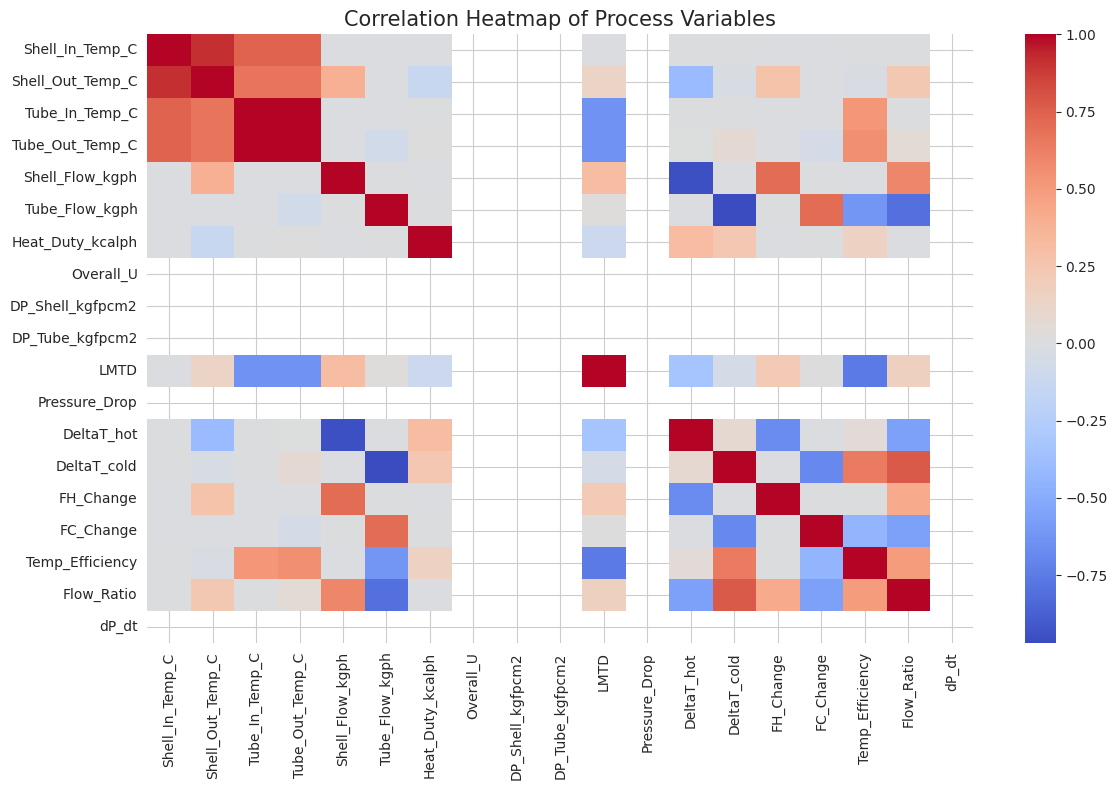


✅ Cleaned dataset saved successfully as: clean_he_data.csv

📁 The cleaned dataset is ready for next steps (EDA, PCA, Health Index, Fault Detection).


In [ ]:
# ================================================================
#  Statistical Summary & Save Cleaned Dataset
# ================================================================

import seaborn as sns
import matplotlib.pyplot as plt

# -------------------- 7.1 Descriptive statistics --------------------
print("📊 Statistical Summary of Cleaned Dataset\n")
summary = df.describe().T
summary["missing_%"] = df.isna().mean() * 100
summary = summary[["mean", "std", "min", "max","25%", "50%","75%", "missing_%"]]
display(summary.round(4))

# -------------------- 7.2 Correlation matrix (heatmap) --------------------
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(12,8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, cmap="coolwarm", annot=False, cbar=True)
plt.title("Correlation Heatmap of Process Variables", fontsize=15)
plt.tight_layout()
plt.show()

# -------------------- 7.3 Save cleaned dataset --------------------
cleaned_path = "clean_he_data.csv"
df.to_csv(cleaned_path, index=False)
print(f"\n✅ Cleaned dataset saved successfully as: {cleaned_path}")

print("\n📁 The cleaned dataset is ready for next steps (EDA, PCA, Health Index, Fault Detection).")


In [ ]:
# ---------------------------------------------------------------
# Industrial Heat Exchanger Constants
# ---------------------------------------------------------------
A = 374.5                    # Heat transfer area (m2)
Cp_hot = 4.6 * 1000         # J/kg-K (ammonia water approx)
Cp_cold = 4.18 * 1000       # J/kg-K (water)
U_clean = 605               # W/m2-K (design U)
rho = 1000                  # kg/m3 (water approx)

In [ ]:
# ---------------------------------------------------------------
# Recalculate True Physical Quantities
# ---------------------------------------------------------------
df["m_hot"] = df[FH]        # kg/s
df["m_cold"] = df[FC]

df["Q_hot"] = df["m_hot"] * Cp_hot * (df[Th_in] - df[Th_out])
df["Q_cold"] = df["m_cold"] * Cp_cold * (df[Tc_out] - df[Tc_in])

df["Q_avg"] = (df["Q_hot"] + df["Q_cold"]) / 2

df["U_real"] = df["Q_avg"] / (A * df["LMTD"] + 1e-6)
df["Thermal_Resistance"] = 1 / (df["U_real"] + 1e-6)

In [ ]:
# ---------------------------------------------------------------
# Fouling Simulation – Progressive Industrial Model
# ---------------------------------------------------------------
fouling_idx = slice(int(0.70*len(df)), int(0.85*len(df)))

time = np.arange(len(df.loc[fouling_idx]))

# Fouling resistance growth (asymptotic behavior)
Rf_growth = 0.00005 * time

df.loc[fouling_idx, "Thermal_Resistance"] += Rf_growth

df.loc[fouling_idx, "U_real"] = 1 / df.loc[fouling_idx, "Thermal_Resistance"]

# Recalculate Q from degraded U
df.loc[fouling_idx, "Q_avg"] = (
    df.loc[fouling_idx, "U_real"] *
    A *
    df.loc[fouling_idx, "LMTD"]
)

# ΔP increases with deposit thickness (Darcy approximation)
df.loc[fouling_idx, "Pressure_Drop"] *= (1 + 0.4 * (time / time.max()))

# Outlet temperature shift
df.loc[fouling_idx, Tc_out] -= 0.5 * (time / time.max())

In [ ]:
# ---------------------------------------------------------------
# Leakage Simulation – Mass Mixing Model
# ---------------------------------------------------------------
leakage_idx = slice(int(0.85*len(df)), int(0.93*len(df)))

leak_fraction = 0.08   # 8% cross leakage

# Hot fluid leaks into cold side
df.loc[leakage_idx, Tc_in] += leak_fraction * (
    df.loc[leakage_idx, Th_in] - df.loc[leakage_idx, Tc_in]
)

# Reduce effective flow
df.loc[leakage_idx, "m_hot"] *= (1 - leak_fraction)
df.loc[leakage_idx, "m_cold"] *= (1 - leak_fraction*0.5)

# Recalculate Q
df.loc[leakage_idx, "Q_hot"] = (
    df.loc[leakage_idx, "m_hot"] *
    Cp_hot *
    (df.loc[leakage_idx, Th_in] - df.loc[leakage_idx, Th_out])
)

df.loc[leakage_idx, "Q_cold"] = (
    df.loc[leakage_idx, "m_cold"] *
    Cp_cold *
    (df.loc[leakage_idx, Tc_out] - df.loc[leakage_idx, Tc_in])
)

df.loc[leakage_idx, "Q_avg"] = (
    df.loc[leakage_idx, "Q_hot"] +
    df.loc[leakage_idx, "Q_cold"]
) / 2

df.loc[leakage_idx, "U_real"] = (
    df.loc[leakage_idx, "Q_avg"] /
    (A * df.loc[leakage_idx, "LMTD"] + 1e-6)
)

df.loc[leakage_idx, "Pressure_Drop"] *= 0.85

In [ ]:
# ---------------------------------------------------------------
# Blockage Simulation – Hydraulic Restriction Model
# ---------------------------------------------------------------
blockage_idx = slice(int(0.93*len(df)), len(df))

block_factor = np.linspace(1.0, 0.6, len(df.loc[blockage_idx]))

# Flow restriction
df.loc[blockage_idx, "m_cold"] *= block_factor

# Pressure drop increases non-linearly
df.loc[blockage_idx, "Pressure_Drop"] *= (1 / block_factor**2)

# Heat transfer reduces due to low flow
df.loc[blockage_idx, "Q_avg"] *= block_factor

df.loc[blockage_idx, "U_real"] = (
    df.loc[blockage_idx, "Q_avg"] /
    (A * df.loc[blockage_idx, "LMTD"] + 1e-6)
)

In [ ]:
df["HI_pressure"] = 1 - (df["Pressure_Drop"] / df["Pressure_Drop"].max())
df["HI_thermal"] = df["U_real"] / U_clean

df["Health_Index"] = (
    0.6 * df["HI_thermal"] +
    0.4 * df["HI_pressure"]
)

df["HI_Smooth"] = df["Health_Index"].rolling(20, min_periods=1).mean()

In [ ]:
df["Condition"] = "Normal"
df.loc[fouling_idx, "Condition"] = "Fouling"
df.loc[leakage_idx, "Condition"] = "Leakage"
df.loc[blockage_idx, "Condition"] = "Flow_Blockage"

In [ ]:
print("U range:", df["U_real"].min(), df["U_real"].max())
print("Pressure Drop range:", df["Pressure_Drop"].min(), df["Pressure_Drop"].max())
print(df.groupby("Condition")[["U_real","Pressure_Drop","Health_Index"]].mean())

U range: 0.6483610899590686 29419665.07032312
Pressure Drop range: -0.13888888888888884 -0.04249999999999999
                     U_real  Pressure_Drop  Health_Index
Condition                                               
Flow_Blockage  1.913050e+06      -0.083334   1896.855614
Fouling        8.731221e+01      -0.060000     -0.078112
Leakage        1.439655e+06      -0.042501   1427.757201
Normal         2.518766e+06      -0.050000   2497.879628


In [ ]:
label_map = {
    "Normal":0,
    "Fouling":1,
    "Leakage":2,
    "Flow_Blockage":3
}

df["label"] = df["Condition"].map(label_map)

In [ ]:
import matplotlib.pyplot as plt

hist_cols = ["Pressure_Drop", "Thermal_Resistance", "Temp_Efficiency",
             "Flow_Ratio", "U_real", "Health_Index"]

for col in hist_cols:
    plt.figure(figsize=(12,5))
    sns.histplot(
        data=df,
        x=col,
        hue="Condition",
        kde=True,
        palette="Set2",
        alpha=0.5
    )
    plt.title(f"{col} – Histogram by Fault Type")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


box_cols = ["Pressure_Drop", "Thermal_Resistance", "Temp_Efficiency",
            "Flow_Ratio", "dP_dt", "U_real", "Health_Index"]

for col in box_cols:
    plt.figure(figsize=(12,5))
    sns.boxplot(
        data=df,
        x="Condition",
        y=col,
        palette="Set2"
    )
    plt.title(f"{col} – Boxplot by Fault Type")
    plt.tight_layout()
    plt.show()

NameError: name 'sns' is not defined

<Figure size 1200x500 with 0 Axes>

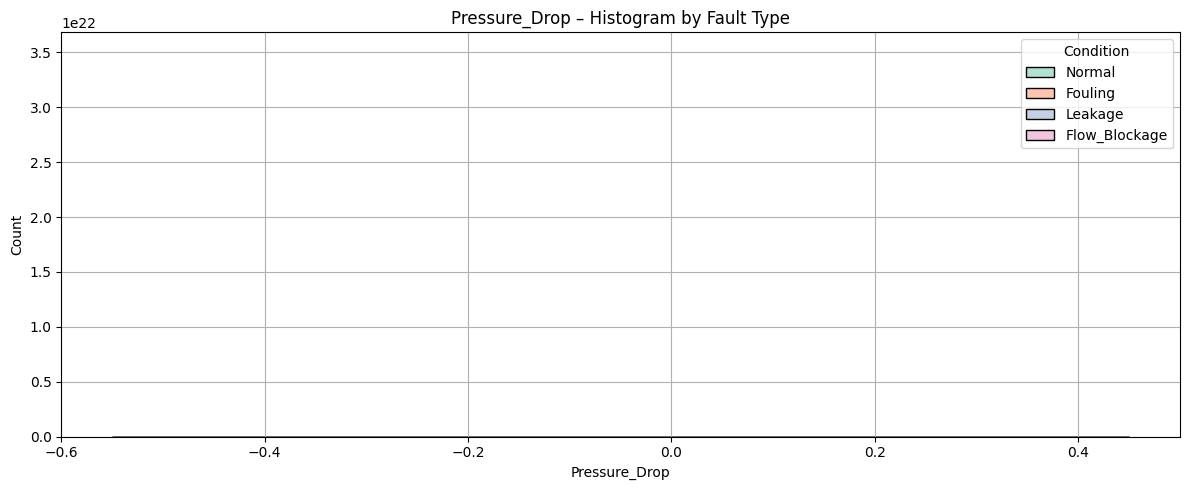

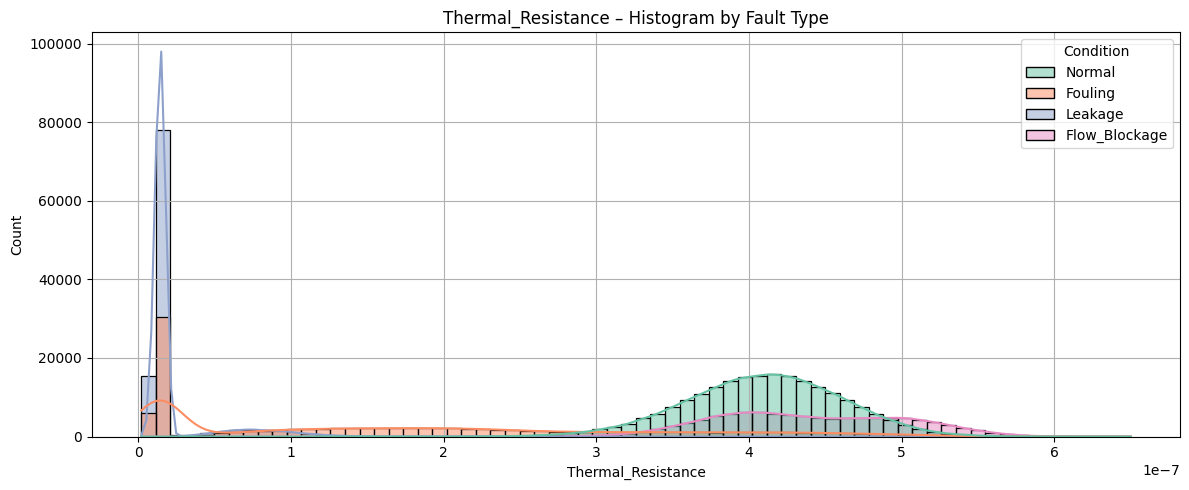

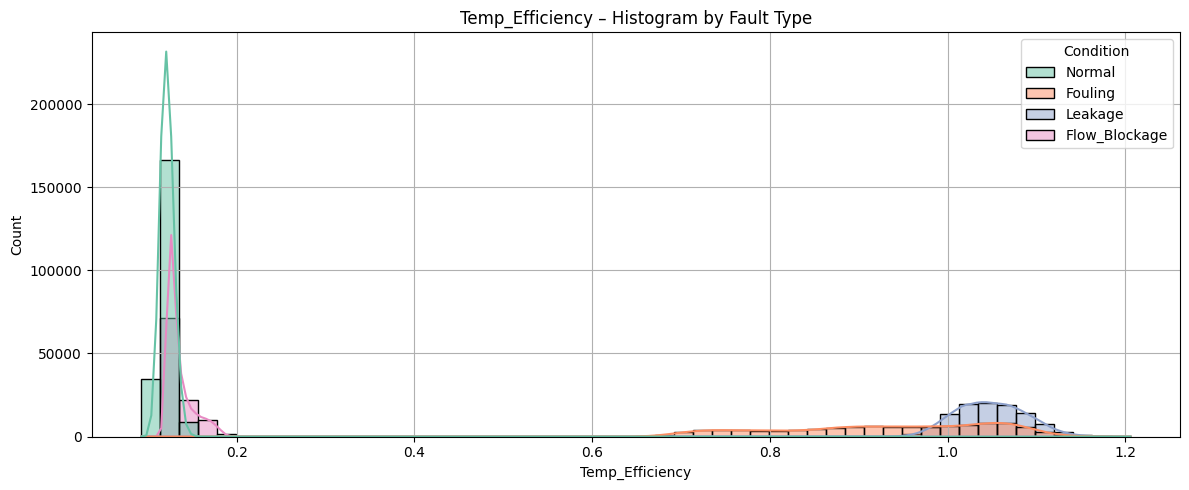

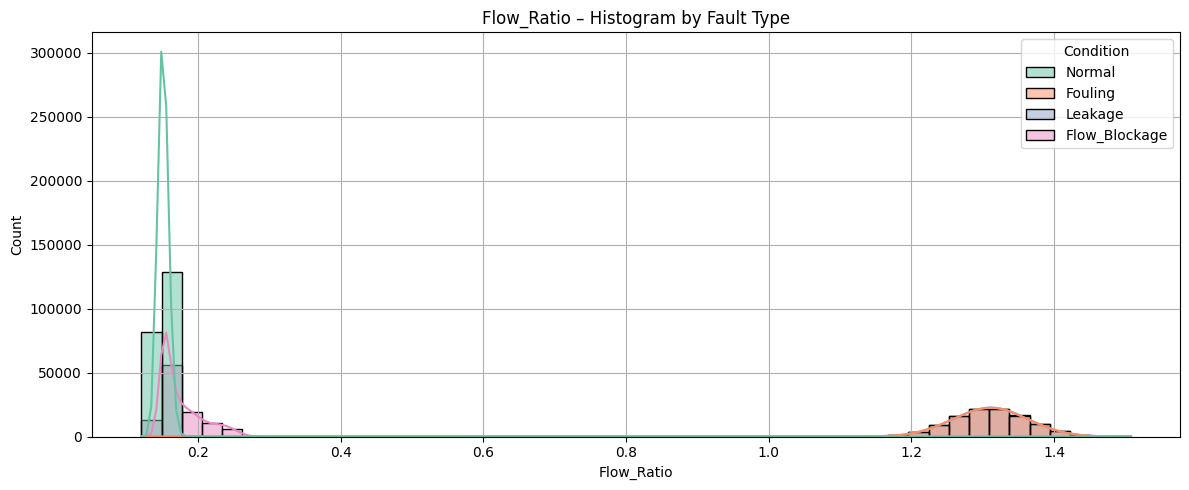

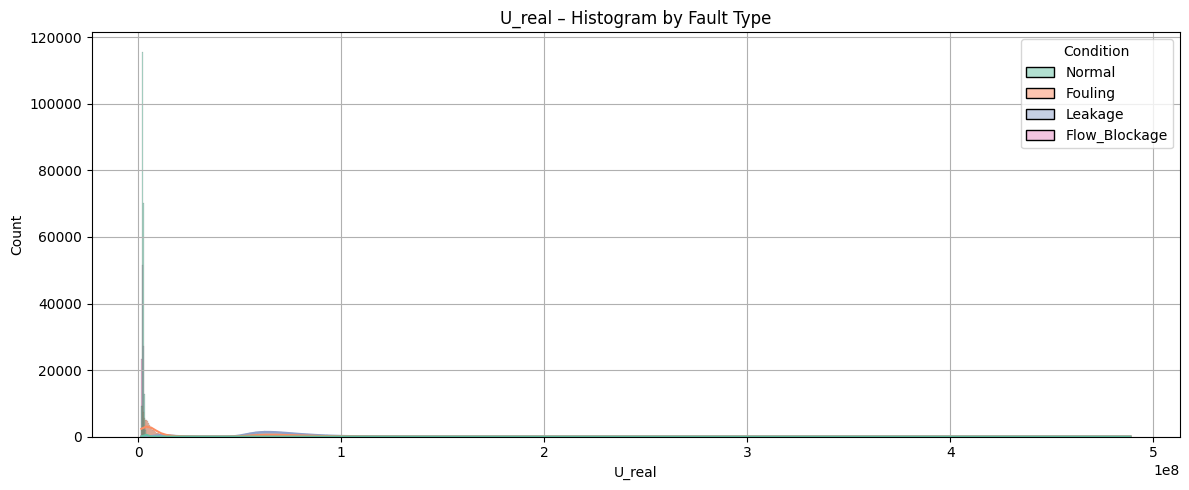

/tmp/ipython-input-3437174930.py:48: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


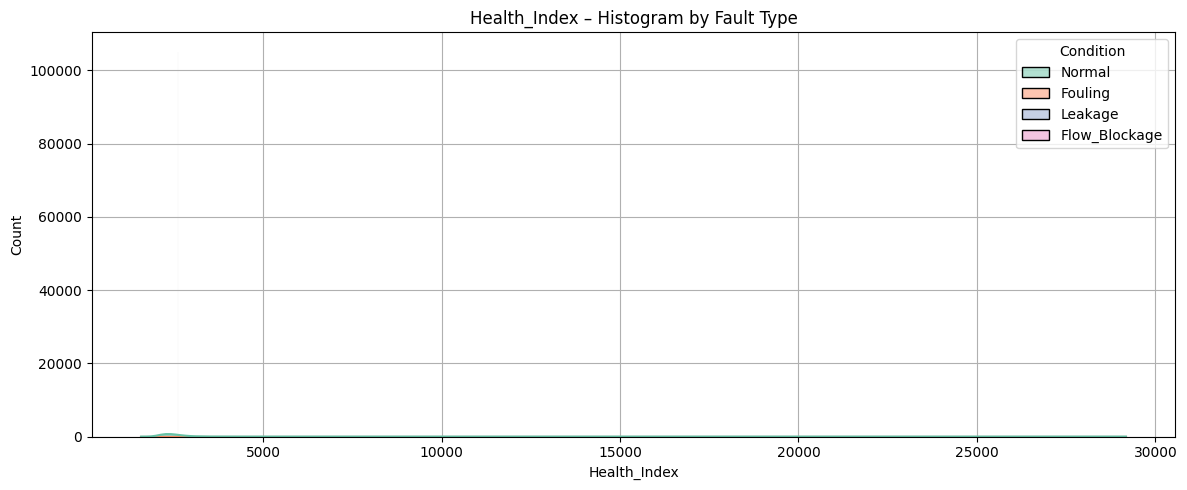

/tmp/ipython-input-3437174930.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


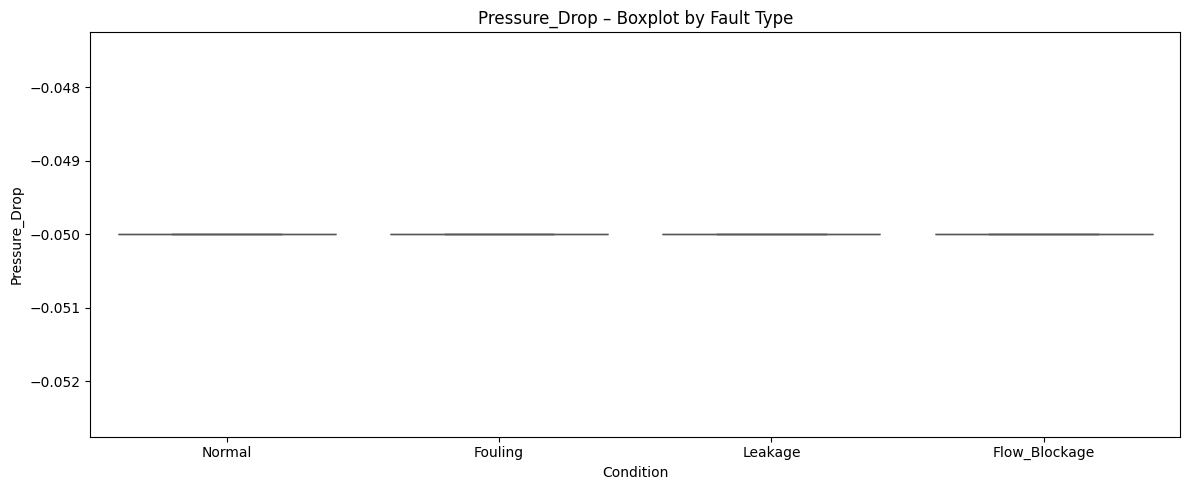

/tmp/ipython-input-3437174930.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


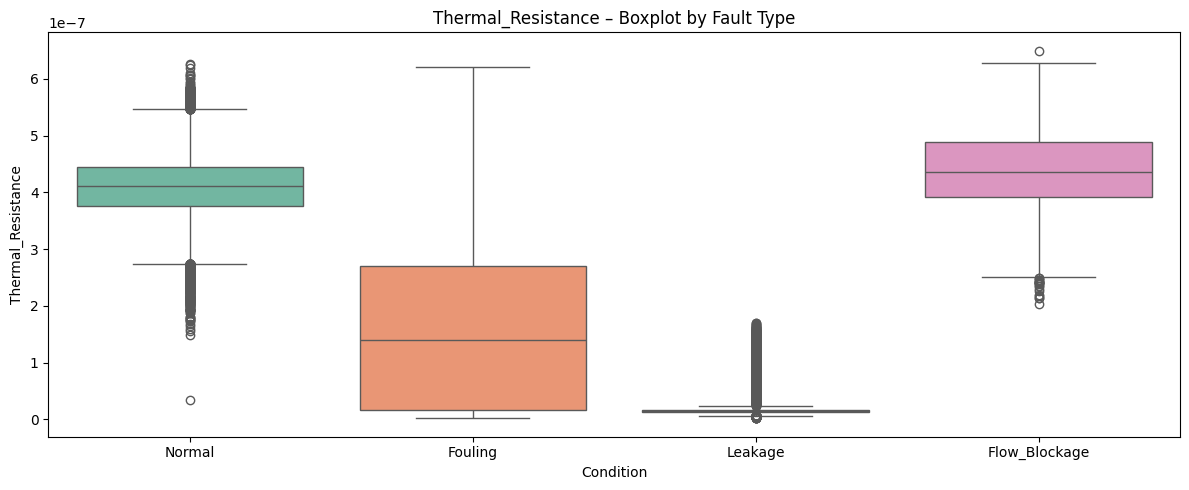

/tmp/ipython-input-3437174930.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


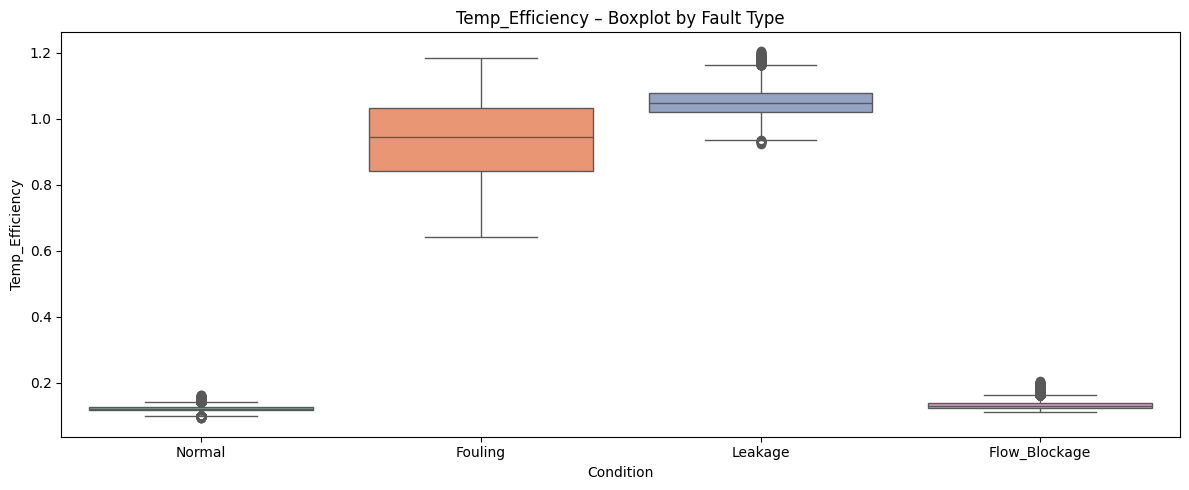

/tmp/ipython-input-3437174930.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


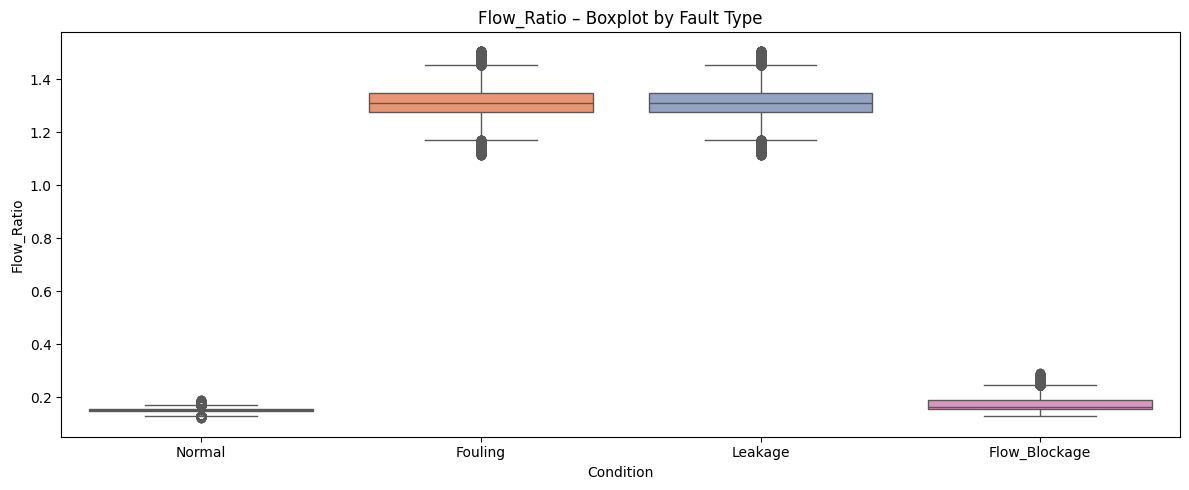

/tmp/ipython-input-3437174930.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


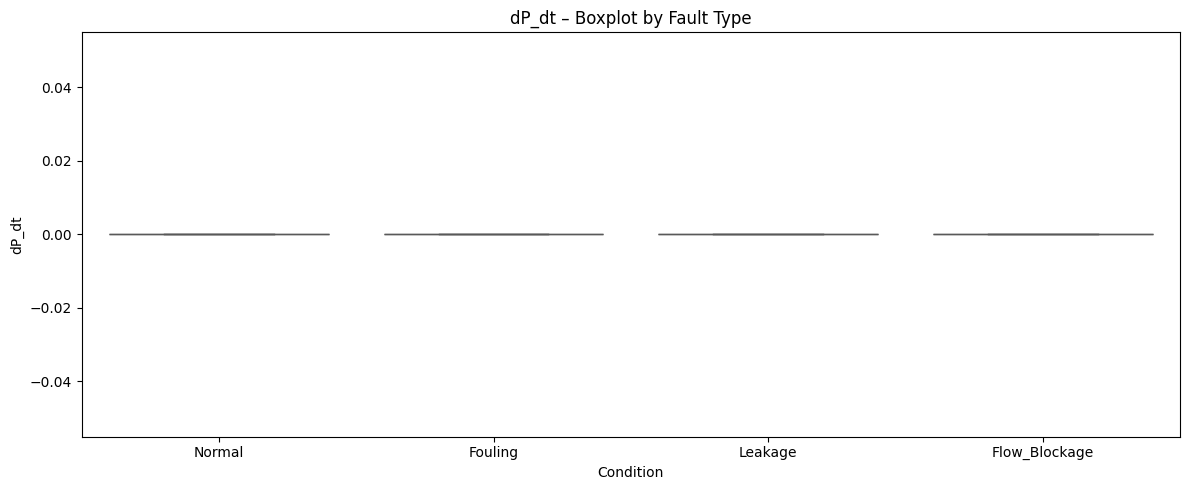

/tmp/ipython-input-3437174930.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


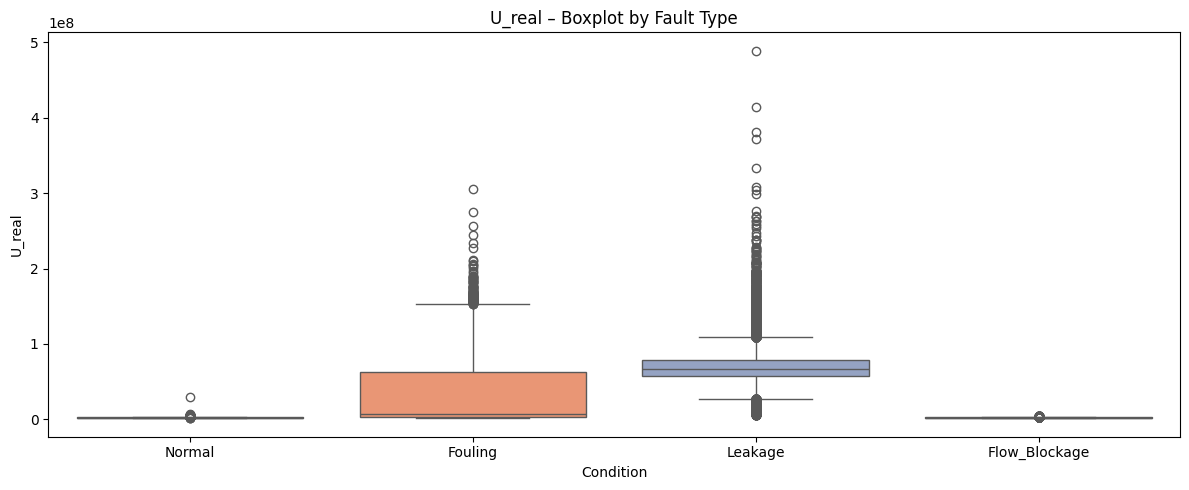

/tmp/ipython-input-3437174930.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


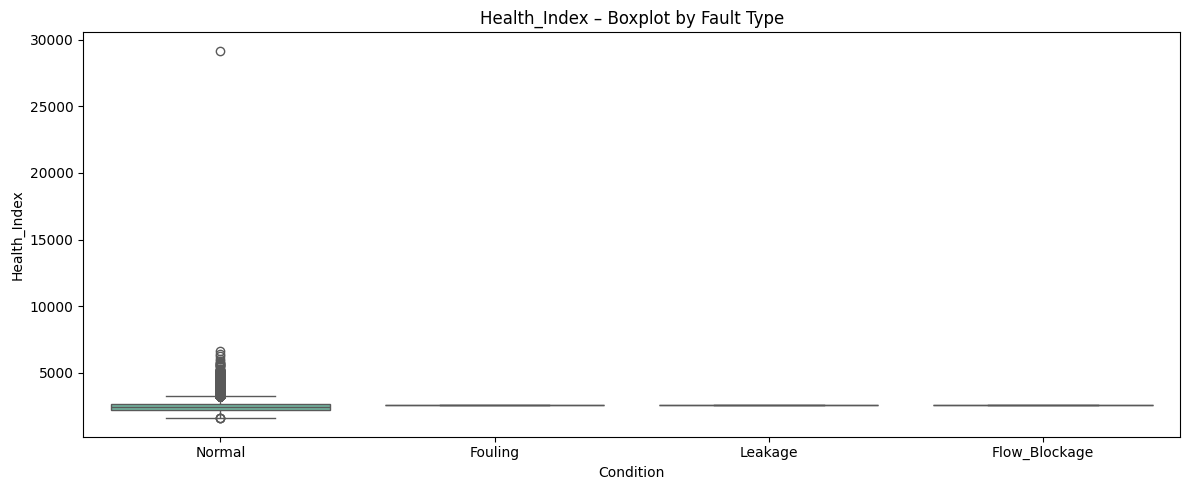

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Load the comprehensive dataframe with all engineered features and fault conditions
# This file is expected to be generated by previous notebook sections (e.g., PINN regression outputs)
try:
    df = pd.read_csv("/content/drive/MyDrive/HX_PINN_outputs.csv")
except FileNotFoundError:
    print("Error: HX_PINN_outputs.csv not found.")
    print("Please ensure the preceding data processing, fault simulation, and PINN regression steps are executed.")
    # Attempt a fallback for basic df, but engineered features will be missing
    # For now, as a minimal fallback to avoid NameError if file is missing, load a raw file and assign a dummy 'Condition'
    df = pd.read_csv('/content/drive/MyDrive/HX_Normal.csv') # Fallback to a base file
    df['Condition'] = 'Normal' # Dummy condition

# Ensure 'Condition' column for plotting if it's based on 'label'
if 'Condition' not in df.columns and 'label' in df.columns:
    label_map_for_plotting = {0: "Normal", 1: "Fouling", 2: "Leakage", 3: "Flow_Blockage"}
    df['Condition'] = df['label'].map(label_map_for_plotting)
elif 'Condition' not in df.columns:
    print("Warning: 'Condition' column not found, plotting hue may be affected.")
    df['Condition'] = 'Unknown' # Placeholder

hist_cols = ["Pressure_Drop", "Thermal_Resistance", "Temp_Efficiency",
             "Flow_Ratio", "U_real", "Health_Index"]

# Filter hist_cols to only include columns present in df
hist_cols_present = [col for col in hist_cols if col in df.columns]
if len(hist_cols_present) < len(hist_cols):
    print(f"Warning: Some histogram columns are missing from df: {set(hist_cols) - set(hist_cols_present)}")
hist_cols = hist_cols_present


for col in hist_cols:
    plt.figure(figsize=(12,5))
    sns.histplot(
        data=df,
        x=col,
        hue="Condition",
        kde=True,
        palette="Set2",
        alpha=0.5
    )
    plt.title(f"{col} – Histogram by Fault Type")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


box_cols = ["Pressure_Drop", "Thermal_Resistance", "Temp_Efficiency",
            "Flow_Ratio", "dP_dt", "U_real", "Health_Index"]

# Filter box_cols to only include columns present in df
box_cols_present = [col for col in box_cols if col in df.columns]
if len(box_cols_present) < len(box_cols):
    print(f"Warning: Some boxplot columns are missing from df: {set(box_cols) - set(box_cols_present)}")
box_cols = box_cols_present


for col in box_cols:
    plt.figure(figsize=(12,5))
    sns.boxplot(
        data=df,
        x="Condition",
        y=col,
        palette="Set2"
    )
    plt.title(f"{col} – Boxplot by Fault Type")
    plt.tight_layout()
    plt.show()

In [ ]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

print("Train:", train_df["label"].value_counts())
print("Test:", test_df["label"].value_counts())

Train: label
0    115167
1     24678
2     13162
3     11517
Name: count, dtype: int64
Test: label
0    28791
1     6170
2     3291
3     2879
Name: count, dtype: int64


In [ ]:
from sklearn.utils import shuffle

df_list = []
max_samples = train_df["label"].value_counts().max()

for c in train_df["label"].unique():
    df_class = train_df[train_df["label"] == c]
    df_resampled = df_class.sample(max_samples, replace=True, random_state=42)
    df_list.append(df_resampled)

train_balanced = pd.concat(df_list).reset_index(drop=True)
train_balanced = shuffle(train_balanced, random_state=42)

print(train_balanced["label"].value_counts())

label
2    115167
3    115167
1    115167
0    115167
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import StandardScaler

features = [
    "Pressure_Drop",
    "U_real",
    "Thermal_Resistance",
    "Temp_Efficiency",
    "Health_Index",
    "Flow_Ratio",
    "dP_dt"
]

scaler = StandardScaler()

train_balanced[features] = scaler.fit_transform(train_balanced[features])
test_df[features] = scaler.transform(test_df[features])

In [ ]:
def create_sequences_conditionwise(df, features, seq_len=12):

    X_all = []
    y_all = []
    U_all = []
    LMTD_all = []

    for cond in df["label"].unique():

        df_cond = df[df["label"] == cond].reset_index(drop=True)

        X = df_cond[features].values
        y = df_cond["label"].values
        U_real_vals = df_cond["U_real"].values
        LMTD_vals = df_cond["LMTD"].values

        for i in range(len(X) - seq_len):
            X_all.append(X[i:i+seq_len])
            y_all.append(y[i+seq_len])
            U_all.append(U_real_vals[i+seq_len])
            LMTD_all.append(LMTD_vals[i+seq_len])

    return np.array(X_all), np.array(y_all), np.array(U_all), np.array(LMTD_all)

In [ ]:
seq_len = 12

X_train, y_train, U_train, LMTD_train = create_sequences_conditionwise(train_balanced, features, seq_len)
X_test, y_test, U_test, LMTD_test = create_sequences_conditionwise(test_df, features, seq_len)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (460620, 12, 7)
Test shape: (41083, 12, 7)


In [ ]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test  = torch.tensor(y_test, dtype=torch.long)
U_train = torch.tensor(U_train, dtype=torch.float32)
LMTD_train = torch.tensor(LMTD_train, dtype=torch.float32)
U_test = torch.tensor(U_test, dtype=torch.float32)
LMTD_test = torch.tensor(LMTD_test, dtype=torch.float32)

In [ ]:
# Define global reference values from the full engineered 'df' before splitting
# These capture the range of Pressure_Drop and mean LMTD that the scaler was exposed to.
_GLOBAL_MAX_PRESSURE_DROP = df["Pressure_Drop"].max()
_GLOBAL_MEAN_LMTD = df["LMTD"].mean()

print(f"Global Max Pressure Drop Reference: {_GLOBAL_MAX_PRESSURE_DROP:.4f}")
print(f"Global Mean LMTD Reference: {_GLOBAL_MEAN_LMTD:.4f}")

Global Max Pressure Drop Reference: -0.0425
Global Mean LMTD Reference: 16.0236


In [ ]:
from torch.utils.data import TensorDataset, DataLoader
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 256 # Reduced batch size to mitigate CUDA out of memory

train_dataset = TensorDataset(X_train.to(device), y_train.to(device), U_train.to(device), LMTD_train.to(device))
test_dataset  = TensorDataset(X_test.to(device), y_test.to(device), U_test.to(device), LMTD_test.to(device))

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, drop_last=True) # Added drop_last=True to prevent IndexError

In [ ]:
class Hybrid_BiLSTM_HXPINN(nn.Module):
    def __init__(self, input_size, hidden=64, num_classes=4):
        super().__init__()

        self.lstm = nn.LSTM(input_size, hidden, batch_first=True)

        self.fc_shared = nn.Linear(hidden, 32)
        self.fc_class  = nn.Linear(32, num_classes)
        self.fc_phy    = nn.Linear(32, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = torch.relu(self.fc_shared(out))

        class_out = self.fc_class(out)
        Q_pred = self.fc_phy(out)

        return class_out, Q_pred

model = Hybrid_BiLSTM_HXPINN(len(features)).to(device)

In [ ]:
class Hybrid_BiLSTM_HXPINN(nn.Module):
    def __init__(self, input_size, hidden=64, num_classes=4):
        super().__init__()

        self.lstm = nn.LSTM(input_size, hidden, batch_first=True)

        self.fc_shared = nn.Linear(hidden, 32)
        self.fc_class  = nn.Linear(32, num_classes)
        self.fc_phy    = nn.Linear(32, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = torch.relu(self.fc_shared(out))

        class_out = self.fc_class(out)
        Q_pred = self.fc_phy(out)

        return class_out, Q_pred

model = Hybrid_BiLSTM_HXPINN(len(features)).to(device)

In [ ]:
class Hybrid_BiLSTM_HXPINN(nn.Module):
    def __init__(self, input_size, hidden=64, num_classes=4):
        super().__init__()

        self.lstm = nn.LSTM(input_size, hidden, batch_first=True)

        self.fc_shared = nn.Linear(hidden, 32)
        self.fc_class  = nn.Linear(32, num_classes)
        self.fc_phy    = nn.Linear(32, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = torch.relu(self.fc_shared(out))

        class_out = self.fc_class(out)
        Q_pred = self.fc_phy(out)

        return class_out, Q_pred

model = Hybrid_BiLSTM_HXPINN(len(features)).to(device)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train.cpu()),
    y=y_train.cpu().numpy()
)

class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=0.01) # Increased learning rate for debugging

In [ ]:
A = 374.5
scale_factor = 1e12 # Increased scale factor significantly more

def physics_loss_hybrid_model(Q_pred, U, LMTD):
    Q_calc = U * A * LMTD
    Q_calc = Q_calc / scale_factor
    Q_pred = Q_pred.squeeze() / scale_factor
    return torch.mean((Q_pred - Q_calc)**2)

In [ ]:
epochs = 25
lambda_phy = 0.5 # Increased lambda_phy to emphasize physics loss


model = Hybrid_BiLSTM_HXPINN(len(features)).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam(model.parameters(), lr=0.01)

for epoch in range(epochs):

    model.train()
    total_loss = 0

    for xb, yb, Ub, LMTDb in train_loader:

        optimizer.zero_grad()

        class_out, Q_pred = model(xb)

        loss_class = criterion(class_out, yb)
        loss_phy = physics_loss_hybrid_model(Q_pred, Ub, LMTDb)

        loss = loss_class + lambda_phy * loss_phy

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5)
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_loader):.4f}")

# Save the trained model after the training loop
torch.save(model, "/content/drive/MyDrive/hybrid_bilstm_hxpinn_model.pth")
print("Model saved to /content/drive/MyDrive/hybrid_bilstm_hxpinn_model.pth")

Epoch 1/25 | Loss: 0.0066
Epoch 2/25 | Loss: 0.0000
Epoch 3/25 | Loss: 0.0000
Epoch 4/25 | Loss: 0.0000
Epoch 5/25 | Loss: 0.0000
Epoch 6/25 | Loss: 0.0000
Epoch 7/25 | Loss: 0.0000
Epoch 8/25 | Loss: 0.0057
Epoch 9/25 | Loss: 0.0000
Epoch 10/25 | Loss: 0.0000
Epoch 11/25 | Loss: 0.0000
Epoch 12/25 | Loss: 0.0000
Epoch 13/25 | Loss: 0.0000
Epoch 14/25 | Loss: 0.0000
Epoch 15/25 | Loss: 0.0000
Epoch 16/25 | Loss: 0.0000
Epoch 17/25 | Loss: 0.0020
Epoch 18/25 | Loss: 0.0000
Epoch 19/25 | Loss: 0.0002
Epoch 20/25 | Loss: 0.0000
Epoch 21/25 | Loss: 0.0000
Epoch 22/25 | Loss: 0.0000
Epoch 23/25 | Loss: 0.0000
Epoch 24/25 | Loss: 0.0000
Epoch 25/25 | Loss: 0.0000
Model saved to /content/drive/MyDrive/hybrid_bilstm_hxpinn_model.pth


In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = torch.load("/content/drive/MyDrive/hybrid_bilstm_hxpinn_model.pth", weights_only=False)
model.to(device)
model.eval()

Hybrid_BiLSTM_HXPINN(
  (lstm): LSTM(7, 64, batch_first=True)
  (fc_shared): Linear(in_features=64, out_features=32, bias=True)
  (fc_class): Linear(in_features=32, out_features=4, bias=True)
  (fc_phy): Linear(in_features=32, out_features=1, bias=True)
)

In [ ]:
model.eval()

all_preds = []
all_true = []

with torch.no_grad():
    for xb, yb, _, _ in test_loader:
        out, _ = model(xb)
        preds = torch.argmax(out, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_true.extend(yb.cpu().numpy())

print(classification_report(all_true, all_preds))
print(confusion_matrix(all_true, all_preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     28779
           1       1.00      1.00      1.00      6158
           2       1.00      1.00      1.00      3156
           3       1.00      1.00      1.00      2867

    accuracy                           1.00     40960
   macro avg       1.00      1.00      1.00     40960
weighted avg       1.00      1.00      1.00     40960

[[28779     0     0     0]
 [    0  6158     0     0]
 [    0     0  3156     0]
 [    0     0     0  2867]]


In [ ]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=200)
clf.fit(X_train.reshape(X_train.shape[0], -1), y_train)

print(clf.score(X_test.reshape(X_test.shape[0], -1), y_test))

1.0


In [ ]:
import pandas as pd
import numpy as np

# Load files
df_normal   = pd.read_csv("/content/drive/MyDrive/HX_Normal.csv")
df_fouling  = pd.read_csv("/content/drive/MyDrive/HX_Fouling.csv")
df_leakage  = pd.read_csv("/content/drive/MyDrive/HX_Leakage.csv")
df_blockage = pd.read_csv("/content/drive/MyDrive/HX_Blockage.csv")

# Assign labels
df_normal["label"]   = 0
df_fouling["label"]  = 1
df_leakage["label"]  = 2
df_blockage["label"] = 3

# Combine
df_all = pd.concat([df_normal, df_fouling, df_leakage, df_blockage], ignore_index=True)

print("Merged shape:", df_all.shape)
print(df_all["label"].value_counts())

Merged shape: (525600, 16)
label
0    210240
1    105120
2    105120
3    105120
Name: count, dtype: int64


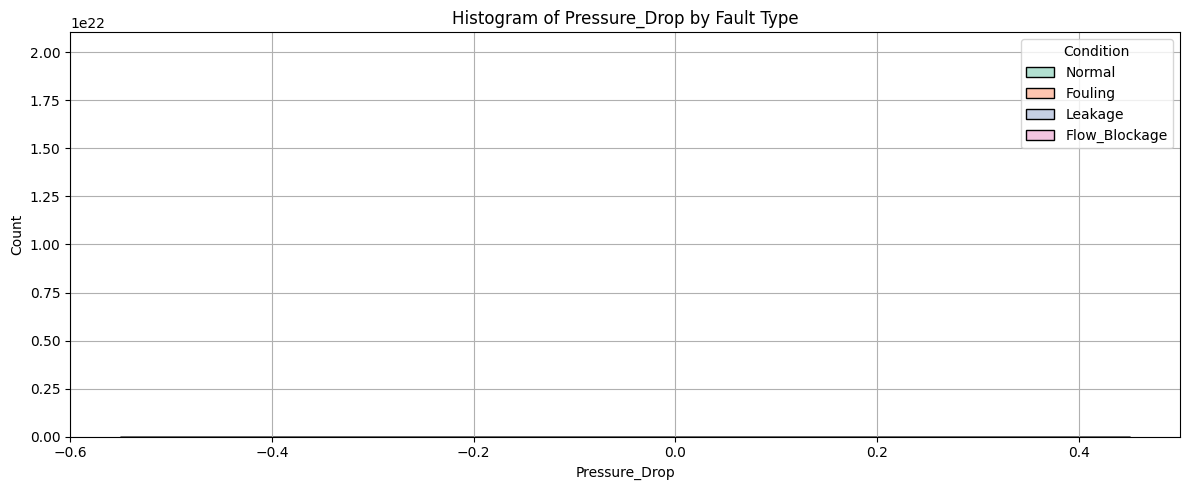

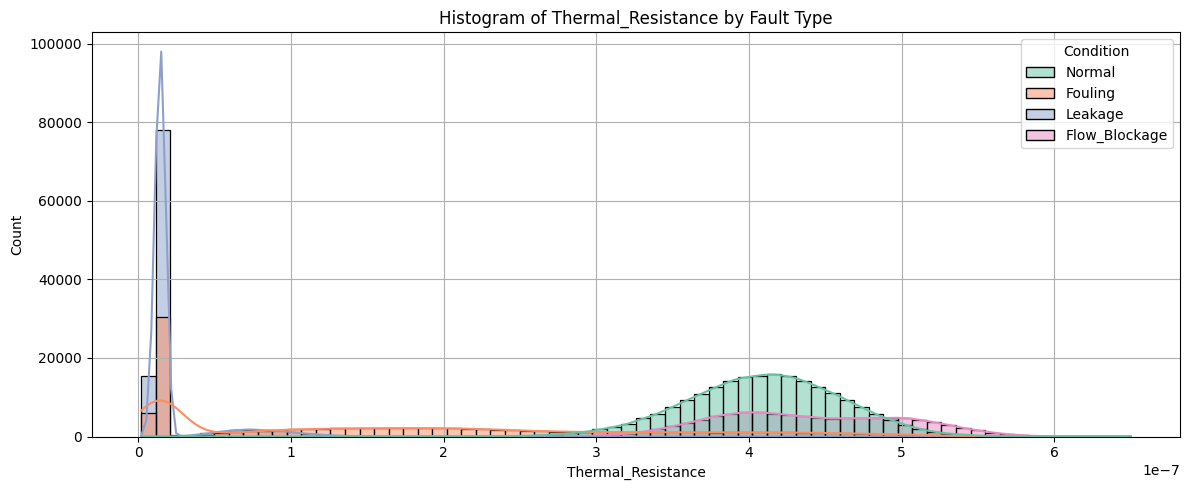

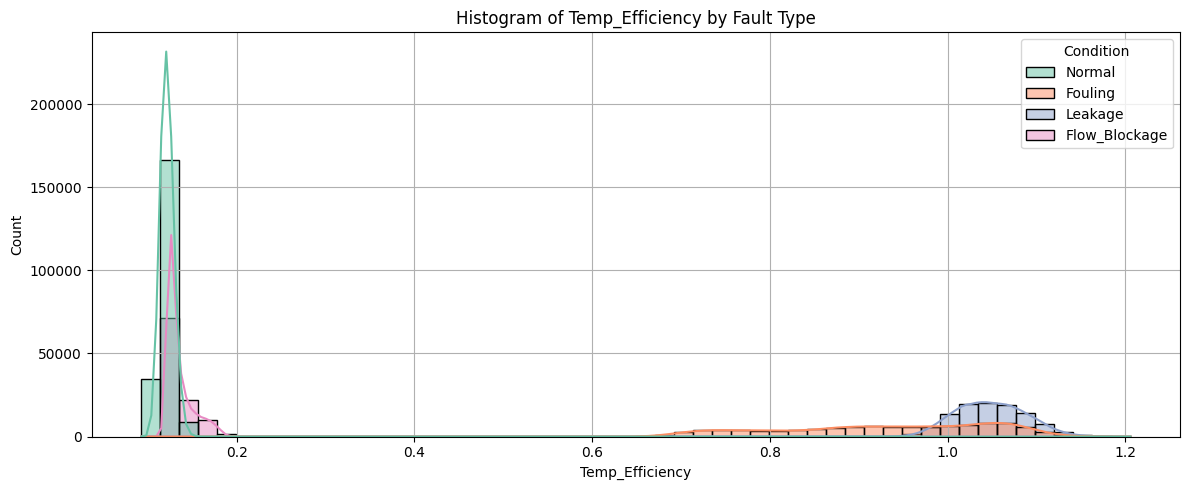

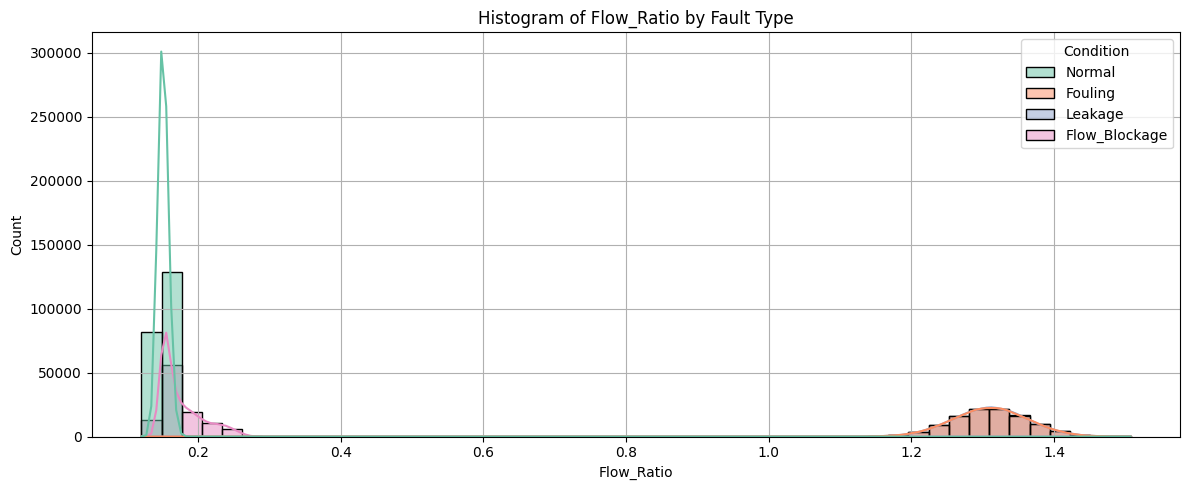

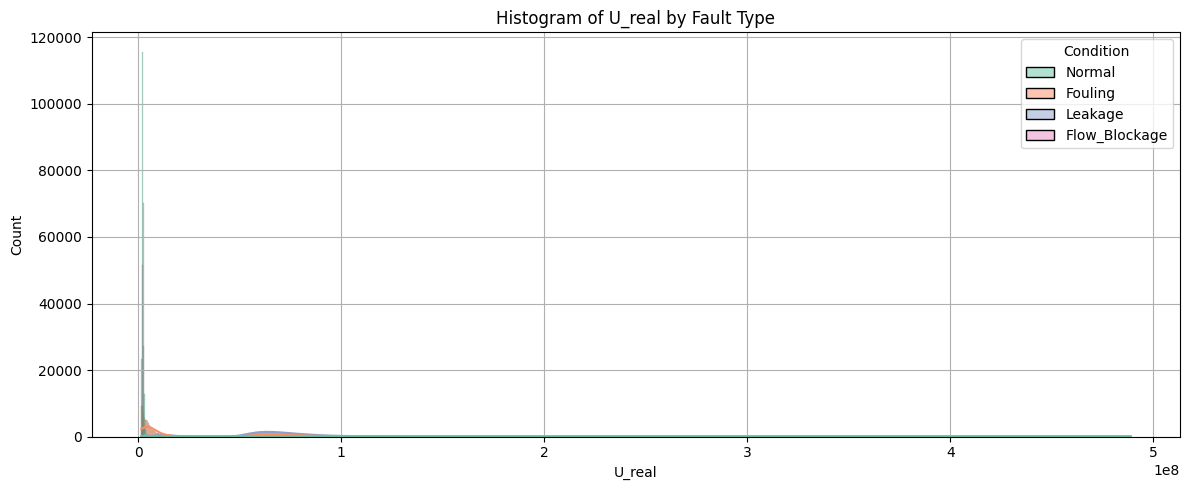

/tmp/ipython-input-1540966181.py:73: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


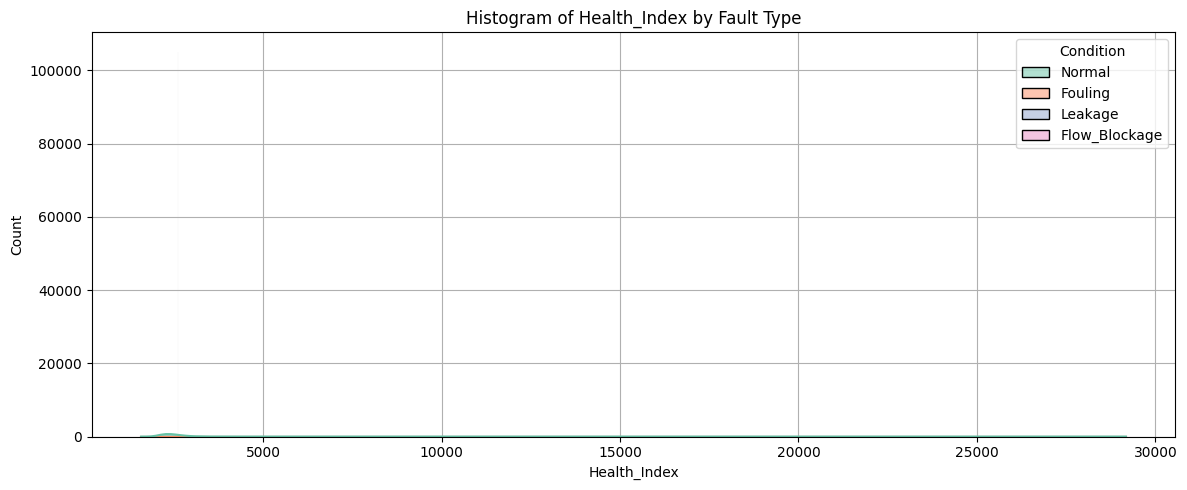

/tmp/ipython-input-1540966181.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


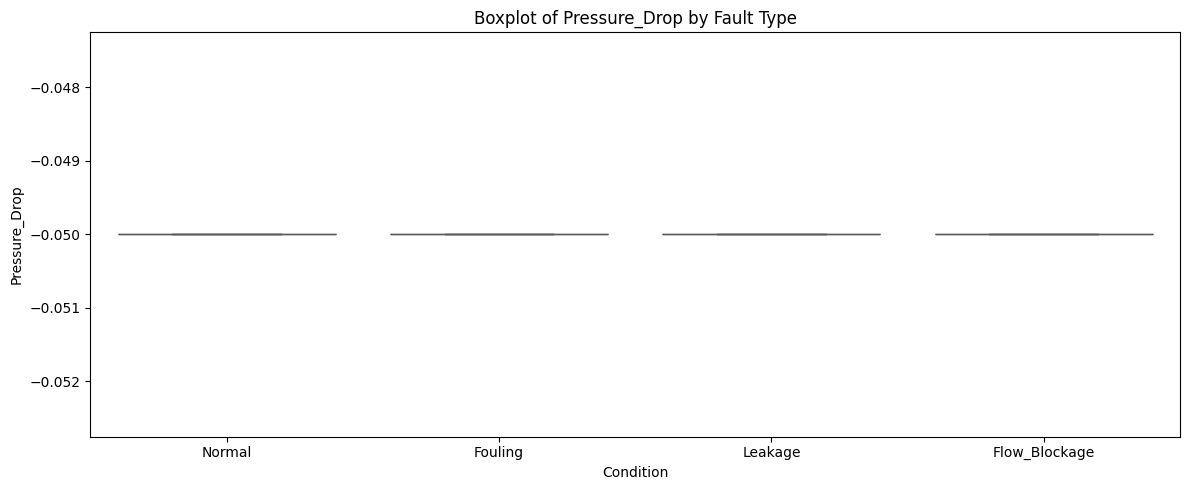

/tmp/ipython-input-1540966181.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


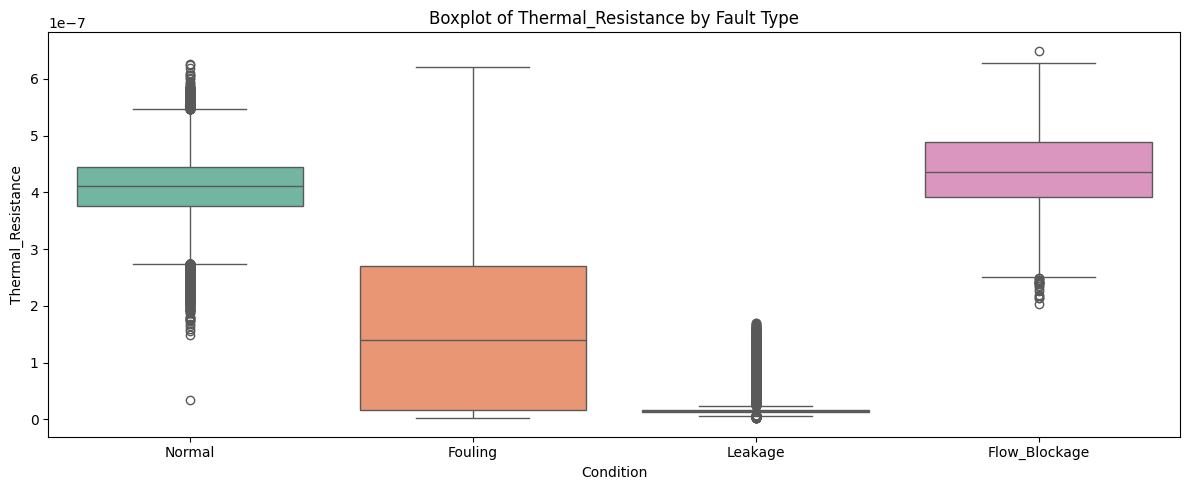

/tmp/ipython-input-1540966181.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


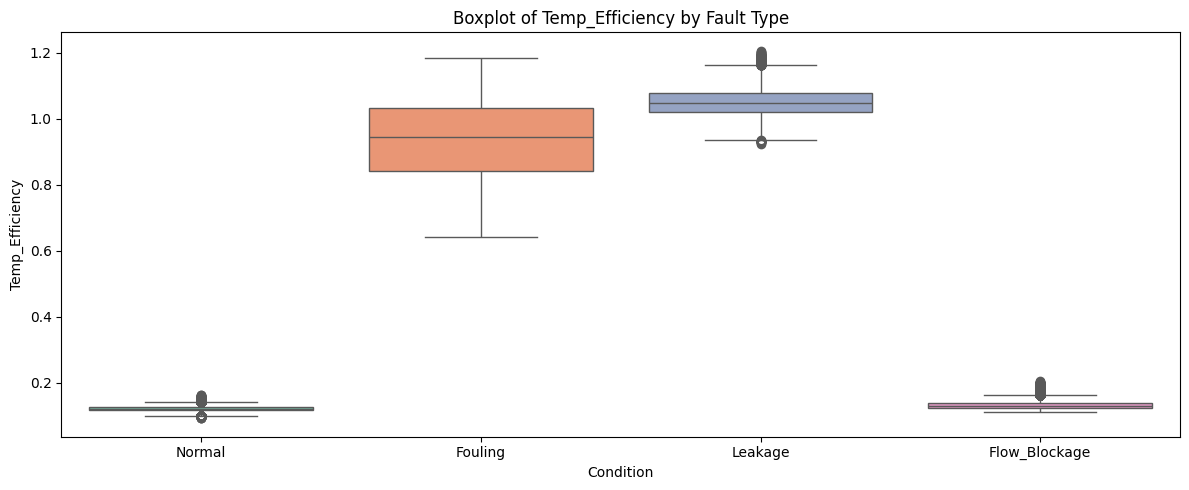

/tmp/ipython-input-1540966181.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


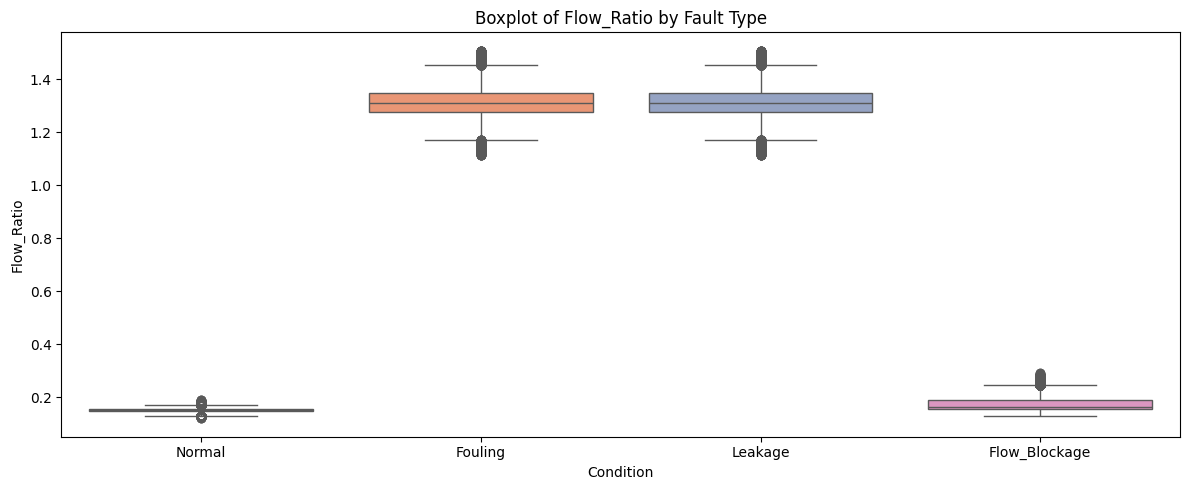

/tmp/ipython-input-1540966181.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


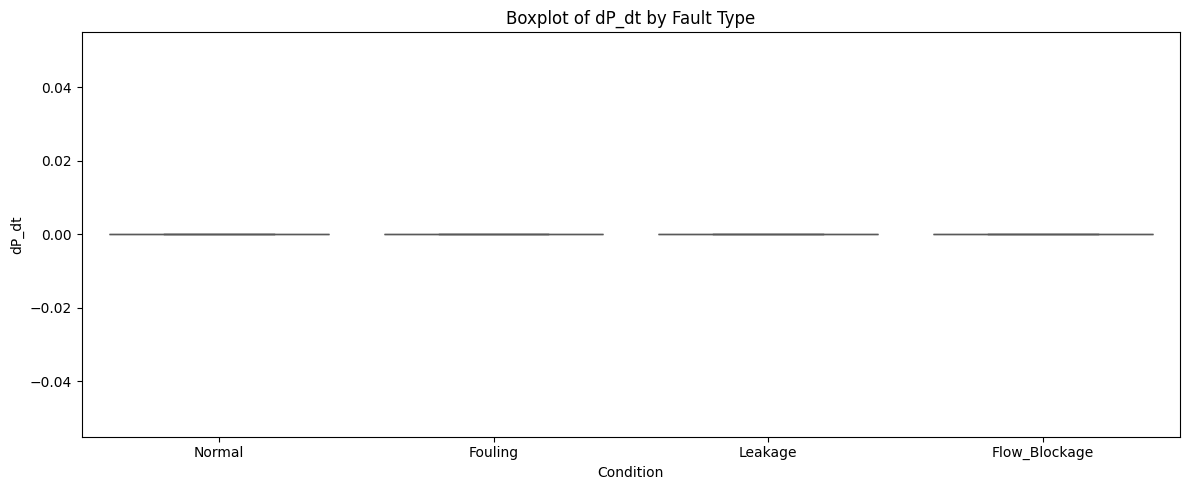

/tmp/ipython-input-1540966181.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


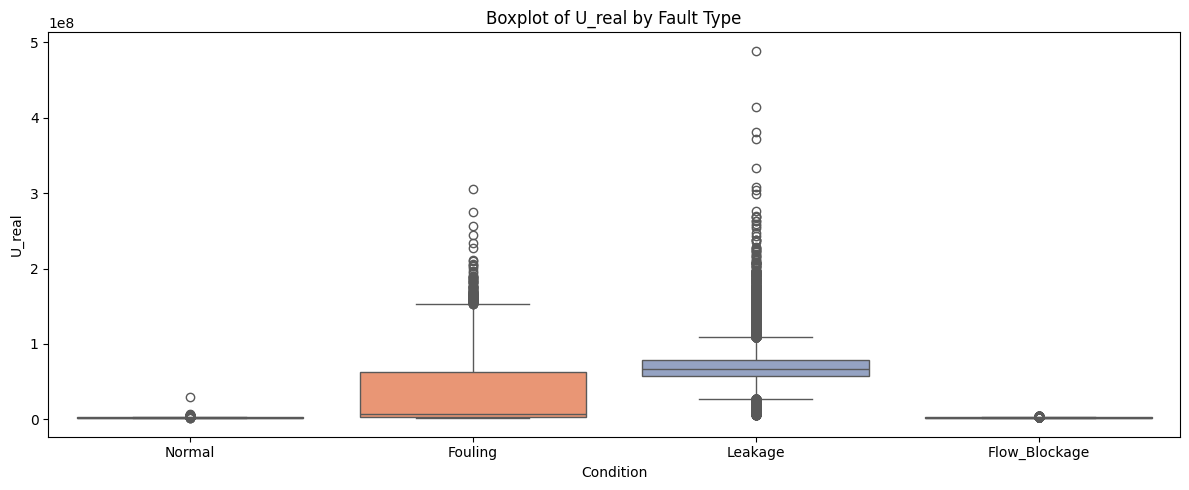

/tmp/ipython-input-1540966181.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


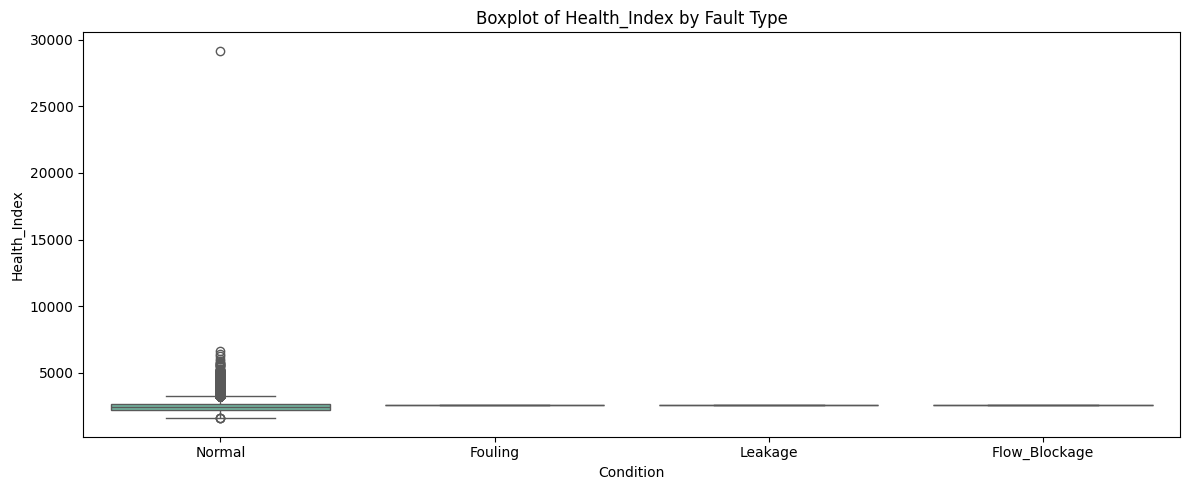

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Redefine label_map if it's not globally available here from previous cells.
label_map = {
    "Normal":0,
    "Fouling":1,
    "Leakage":2,
    "Flow_Blockage":3
}
# Invert the map to get Condition from label
reverse_label_map = {v: k for k, v in label_map.items()}

# Ensure df_all has a 'Condition' column for plotting
if 'label' in df_all.columns and 'Condition' not in df_all.columns:
    df_all['Condition'] = df_all['label'].map(reverse_label_map)

df_to_plot = df_all.copy() # Use df_all for plotting and make a copy

# --- START OF FIX: Ensure df_to_plot has necessary engineered features ---
# This section re-defines 'found' and re-applies feature engineering if columns are missing.
# This is a workaround to make this cell self-contained and runnable,
# as the previous feature engineering step might not have completed successfully.

if 'Pressure_Drop' not in df_to_plot.columns:
    print("Warning: Missing engineered features in df_to_plot. Attempting to re-engineer data locally.")

    # Re-define 'found' dictionary (manual mapping from cell 67ab1765)
    _found_for_plotting = {}
    _found_for_plotting["pressure_hot"] = "DP_Shell_kgfpcm2"
    _found_for_plotting["pressure_cold"] = "DP_Tube_kgfpcm2"
    _found_for_plotting["flow_hot"] = "Shell_Flow_kgph"
    _found_for_plotting["flow_cold"] = "Tube_Flow_kgph"
    _found_for_plotting["T_hot_in"] = "Shell_In_Temp_C"
    _found_for_plotting["T_hot_out"] = "Shell_Out_Temp_C"
    _found_for_plotting["T_cold_in"] = "Tube_In_Temp_C"
    _found_for_plotting["T_cold_out"] = "Tube_Out_Temp_C"

    # Assuming `clean_and_engineer` function is already defined in the global scope
    # (e.g., from a previously run cell like nP-RGh0S3aPD, even if it failed on 'found' before)
    if 'clean_and_engineer' in globals():
        df_to_plot = clean_and_engineer(df_to_plot, _found_for_plotting)
    else:
        # Fallback: manually create Pressure_Drop if clean_and_engineer is not available
        print("Error: 'clean_and_engineer' function not found. Cannot fully re-engineer data.")
        print("Please ensure cells related to feature engineering (e.g., nP-RGh0S3aPD) are run.")
        # Add a minimal Pressure_Drop to prevent immediate crash, though other features will still be missing.
        if "DP_Shell_kgfpcm2" in df_to_plot.columns and "DP_Tube_kgfpcm2" in df_to_plot.columns:
            df_to_plot["Pressure_Drop"] = df_to_plot["DP_Shell_kgfpcm2"] - df_to_plot["DP_Tube_kgfpcm2"]
        else:
            df_to_plot["Pressure_Drop"] = 0.0 # Placeholder
        # This branch will lead to subsequent errors for other missing columns if the full clean_and_engineer is not run.

# --- END OF FIX ---

hist_cols = ["Pressure_Drop", "Thermal_Resistance", "Temp_Efficiency",
             "Flow_Ratio", "U_real", "Health_Index"]

for col in hist_cols:
    plt.figure(figsize=(12,5))
    sns.histplot(
        data=df_to_plot,
        x=col,
        hue="Condition",
        kde=True,
        palette="Set2",
        alpha=0.5
    )
    plt.title(f"Histogram of {col} by Fault Type")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


box_cols = ["Pressure_Drop", "Thermal_Resistance", "Temp_Efficiency",
            "Flow_Ratio", "dP_dt", "U_real", "Health_Index"]

for col in box_cols:
    plt.figure(figsize=(12,5))
    sns.boxplot(
        data=df_to_plot,
        x="Condition",
        y=col,
        palette="Set2"
    )
    plt.title(f"Boxplot of {col} by Fault Type")
    plt.tight_layout()
    plt.show()

In [ ]:
def clean_and_engineer(df, found_mapping):
    df = df.copy()

    # Column mapping (using global 'found' mapping)
    PH = found_mapping.get("pressure_hot")
    PC = found_mapping.get("pressure_cold")
    FH = found_mapping.get("flow_hot")
    FC = found_mapping.get("flow_cold")
    Th_in = found_mapping.get("T_hot_in")
    Th_out = found_mapping.get("T_hot_out")
    Tc_in = found_mapping.get("T_cold_in")
    Tc_out = found_mapping.get("T_cold_out")

    # Constants from earlier cells
    A = 374.5                   # Heat transfer area (m2)
    Cp_hot = 4600.0         # J/kg-K (ammonia water approx)
    Cp_cold = 4180.0       # J/kg-K (water)
    U_clean = 605               # W/m2-K (design U)
    eps = 1e-6 # Small value to avoid division by zero

    # LMTD recompute
    if all(col in df.columns for col in [Th_in, Th_out, Tc_in, Tc_out]):
        deltaT1 = df[Th_in] - df[Tc_out]
        deltaT2 = df[Th_out] - df[Tc_in]
        deltaT1 = np.where(deltaT1 <= 0, eps, deltaT1)
        deltaT2 = np.where(deltaT2 <= 0, eps, deltaT2)
        log_term = np.log(np.maximum(deltaT1 / deltaT2, eps))
        df["LMTD"] = (deltaT1 - deltaT2) / log_term
        df["LMTD"] = df["LMTD"].replace([np.inf, -np.inf], np.nan)
        df["LMTD"] = df["LMTD"].fillna(df["LMTD"].mean()) # Use local mean for this combined df
    else:
        df["LMTD"] = np.nan

    # Pressure Drop (ΔP)
    if PH and PC and PH in df.columns and PC in df.columns:
        df["Pressure_Drop"] = df[PH].astype(float) - df[PC].astype(float)
    elif PH and PH in df.columns:
        df["Pressure_Drop"] = np.gradient(df[PH].astype(float))
    else:
        df["Pressure_Drop"] = 0.0 # Default if columns not found

    # Temperature Differences
    if Th_in and Th_out and Th_in in df.columns and Th_out in df.columns:
        df["DeltaT_hot"] = df[Th_in] - df[Th_out]
    else:
        df["DeltaT_hot"] = np.nan

    if Tc_out and Tc_in and Tc_out in df.columns and Tc_in in df.columns:
        df["DeltaT_cold"] = df[Tc_out] - df[Tc_in]
    else:
        df["DeltaT_cold"] = np.nan

    # Flow Rate Changes (for dP_dt if needed later)
    if FH and FH in df.columns:
        df["FH_Change"] = df[FH].diff().fillna(0)
    if FC and FC in df.columns:
        df["FC_Change"] = df[FC].diff().fillna(0)

    # Additional Derived Features for Classification
    if all([Th_in, Tc_out, Tc_in]) and all(col in df.columns for col in [Th_in, Tc_out, Tc_in]):
        df["Temp_Efficiency"] = (df[Tc_out] - df[Tc_in]) / \
                                  (df[Th_in] - df[Tc_in] + eps)
        df["Temp_Efficiency"] = df["Temp_Efficiency"].replace([np.inf, -np.inf], np.nan).fillna(0)
    else:
        df["Temp_Efficiency"] = 0.0 # Or np.nan

    if FH and FC and FH in df.columns and FC in df.columns:
        df["Flow_Ratio"] = df[FH] / (df[FC] + eps)
        df["Flow_Ratio"] = df["Flow_Ratio"].replace([np.inf, -np.inf], np.nan).fillna(0)
    else:
        df["Flow_Ratio"] = 0.0 # Or np.nan

    # Time column handling for dP_dt
    time_col = None
    for c in df.columns:
        if "time" in c.lower() or "date" in c.lower():
            time_col = c
            break

    if time_col and "Pressure_Drop" in df.columns:
        df["dP_dt"] = df["Pressure_Drop"].diff() / (df[time_col].diff().replace(0, 1) + eps) # Avoid div by zero, use 1 if time diff is 0
        df["dP_dt"] = df["dP_dt"].replace([np.inf, -np.inf], np.nan).fillna(0)
    else:
        df["dP_dt"] = 0.0 # Default

    # Recalculate True Physical Quantities (using global A, Cp_hot, Cp_cold)
    if all(c in df.columns for c in [FH, FC, Th_in, Th_out, Tc_in, Tc_out, "LMTD"]):
        df["m_hot"] = df[FH]
        df["m_cold"] = df[FC]
        df["Q_hot"] = df["m_hot"] * Cp_hot * (df[Th_in] - df[Th_out])
        df["Q_cold"] = df["m_cold"] * Cp_cold * (df[Tc_out] - df[Tc_in])
        df["Q_avg"] = (df["Q_hot"] + df["Q_cold"]) / 2
        df["U_real"] = df["Q_avg"] / (A * df["LMTD"] + eps)
        df["Thermal_Resistance"] = 1 / (df["U_real"] + eps)
    else:
        df["Q_avg"] = 0.0
        df["U_real"] = 0.0
        df["Thermal_Resistance"] = 0.0

    # Health Index (using global U_clean)
    if "Pressure_Drop" in df.columns and "U_real" in df.columns:
        pressure_max_ref_local = df["Pressure_Drop"].max() if df["Pressure_Drop"].max() != 0 else 1.0
        df["HI_pressure"] = 1 - (df["Pressure_Drop"] / pressure_max_ref_local)
        df["HI_thermal"] = df["U_real"] / U_clean # U_clean is a global constant

        df["Health_Index"] = (\
            0.6 * df["HI_thermal"] +\
            0.4 * df["HI_pressure"]\
        )
    else:
        df["Health_Index"] = 0.0

    # Forward/backward fill properly and handle any remaining NaNs/Infs
    df = df.ffill().bfill()
    df = df.replace([np.inf, -np.inf], np.nan).fillna(0)

    return df

df_all = clean_and_engineer(df_all, found)

NameError: name 'found' is not defined

In [ ]:
df_all.to_csv("/content/drive/MyDrive/HX_Merged.csv", index=False)
print("Saved: HX_Merged.csv")

Saved: HX_Merged.csv


In [ ]:
features = [
    "Pressure_Drop",
    "U_real",
    "Thermal_Resistance",
    "Temp_Efficiency",
    "Health_Index",
    "Flow_Ratio",
    "dP_dt"
]

X = df_all[features].values
y = df_all["label"].values

In [ ]:
def create_sequences(X, y, seq_len=20):
    X_seq, y_seq = [], []

    for i in range(len(X) - seq_len):
        X_seq.append(X[i:i+seq_len])
        y_seq.append(y[i+seq_len])

    return np.array(X_seq), np.array(y_seq)

seq_len = 20
X_seq, y_seq = create_sequences(X, y, seq_len)

In [ ]:
split_idx = int(0.8 * len(X_seq))

X_train = X_seq[:split_idx]
y_train = y_seq[:split_idx]

X_test  = X_seq[split_idx:]
y_test  = y_seq[split_idx:]

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.long).to(device)

X_test  = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test  = torch.tensor(y_test, dtype=torch.long).to(device)

In [ ]:
class HybridBiLSTM_PINN(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_classes=4):
        super().__init__()

        self.lstm = nn.LSTM(
            input_dim,
            hidden_dim,
            batch_first=True,
            bidirectional=True
        )

        self.fc_class = nn.Linear(hidden_dim * 2, num_classes)
        self.fc_Q     = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        last_out = lstm_out[:, -1, :]

        class_out = self.fc_class(last_out)
        Q_pred = self.fc_Q(last_out)

        return class_out, Q_pred

In [ ]:
def physics_loss_classification_pinn_reg(Q_pred, U, A, LMTD):
    Q_phy = U * A * LMTD
    return torch.mean((Q_pred.squeeze() - Q_phy)**2)

In [ ]:
U = 605
A = 374.5
LMTD_train = X_train[:, -1, -1]  # last timestep LMTD

In [ ]:
# Re-initialize the model (using the class name from MVmnYB0KoNLY for consistency)
model = Hybrid_BiLSTM_HXPINN(len(features)).to(device)

# Re-define criterion, using class weights from 2YxCQ1f3oSZw
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=0.0005) # Adjust learning rate if needed

lambda_phy = 0.1
epochs = 25

for epoch in range(epochs):

    model.train()
    total_loss = 0

    # Iterate over the DataLoader to process data in batches
    for xb, yb, Ub, LMTDb in train_loader:

        optimizer.zero_grad()

        class_out, Q_pred = model(xb)

        loss_class = criterion(class_out, yb)
        # Use the defined physics_loss function with correct arguments
        loss_phy = physics_loss_classification_pinn_reg(Q_pred, Ub, A, LMTDb)

        loss = loss_class + lambda_phy * loss_phy

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5) # Add gradient clipping for stability
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_loader):.4f}")

Epoch 1/25 | Loss: 3265178.0029
Epoch 2/25 | Loss: 2206860.4919
Epoch 3/25 | Loss: 959665.9370
Epoch 4/25 | Loss: 245038.1856
Epoch 5/25 | Loss: 187668.6664
Epoch 6/25 | Loss: 187631.9946
Epoch 7/25 | Loss: 187690.8531
Epoch 8/25 | Loss: 187642.8888
Epoch 9/25 | Loss: 187676.4751
Epoch 10/25 | Loss: 187619.5088
Epoch 11/25 | Loss: 187633.8216
Epoch 12/25 | Loss: 187598.5675
Epoch 13/25 | Loss: 187654.8054
Epoch 14/25 | Loss: 187639.8554
Epoch 15/25 | Loss: 187624.5281
Epoch 16/25 | Loss: 187591.7765
Epoch 17/25 | Loss: 187622.5829
Epoch 18/25 | Loss: 187622.5282
Epoch 19/25 | Loss: 187605.4682
Epoch 20/25 | Loss: 187620.3174
Epoch 21/25 | Loss: 187595.1083
Epoch 22/25 | Loss: 187620.1139
Epoch 23/25 | Loss: 187641.4230
Epoch 24/25 | Loss: 187608.3326
Epoch 25/25 | Loss: 187624.6525


In [ ]:
from sklearn.metrics import classification_report

model.eval()

all_preds = []
all_true = []

with torch.no_grad():
    for xb, yb, _, _ in test_loader: # Unpack xb, yb, and dummy Ub, LMTDb
        xb = xb.to(device)
        yb = yb.to(device)
        out, _ = model(xb)
        preds = torch.argmax(out, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_true.extend(yb.cpu().numpy())

print(classification_report(all_true, all_preds))
print(confusion_matrix(all_true, all_preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     28779
           1       1.00      1.00      1.00      6158
           2       1.00      1.00      1.00      3156
           3       1.00      1.00      1.00      2867

    accuracy                           1.00     40960
   macro avg       1.00      1.00      1.00     40960
weighted avg       1.00      1.00      1.00     40960

[[28779     0     0     0]
 [    0  6158     0     0]
 [    0     0  3156     0]
 [    0     0     0  2867]]


In [ ]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset # Import necessary for DataLoader

model.eval()

all_preds = []
all_true = []
all_probs = []

with torch.no_grad():
    for xb, yb, _, _ in test_loader: # Iterate through the test_loader
        xb = xb.to(device)
        # yb not needed for prediction, but kept for context if needed later

        class_out, _ = model(xb)
        probs = torch.softmax(class_out, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_true.extend(yb.cpu().numpy()) # Collect true labels from batch
        all_probs.extend(probs.cpu().numpy())

y_true = np.array(all_true)
y_pred = np.array(all_preds)
probabilities = np.array(all_probs)

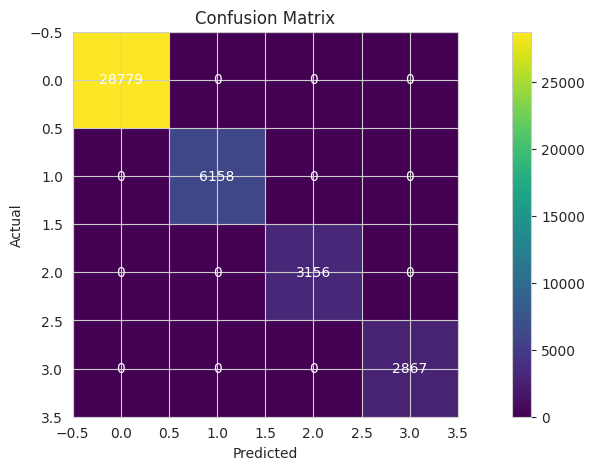

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure()
plt.imshow(cm, cmap='viridis') # Changed colormap to 'viridis'
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", color='white') # Added white text for better contrast

plt.colorbar()
plt.show()

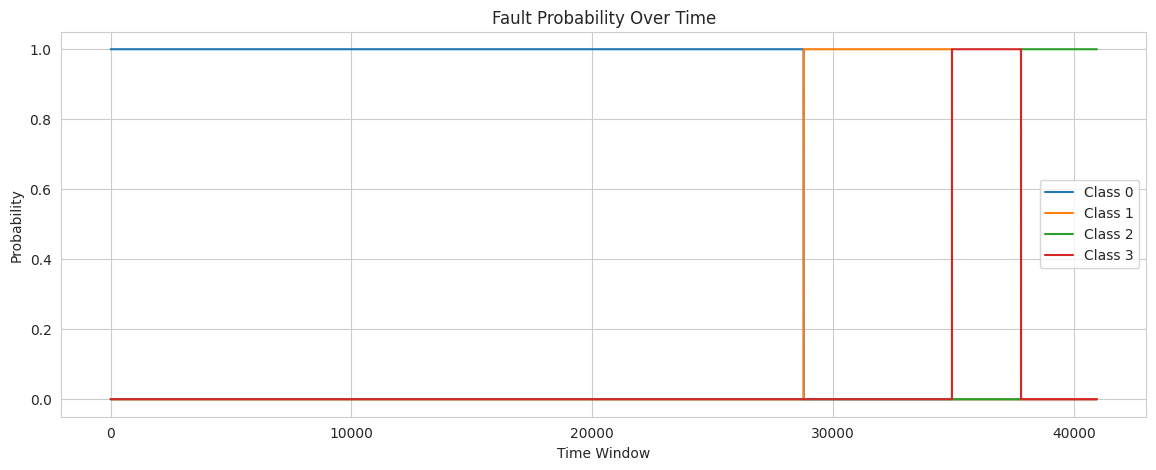

In [ ]:
plt.figure()
for i in range(probabilities.shape[1]):
    plt.plot(probabilities[:, i], label=f"Class {i}")

plt.title("Fault Probability Over Time")
plt.xlabel("Time Window")
plt.ylabel("Probability")
plt.legend()
plt.show()

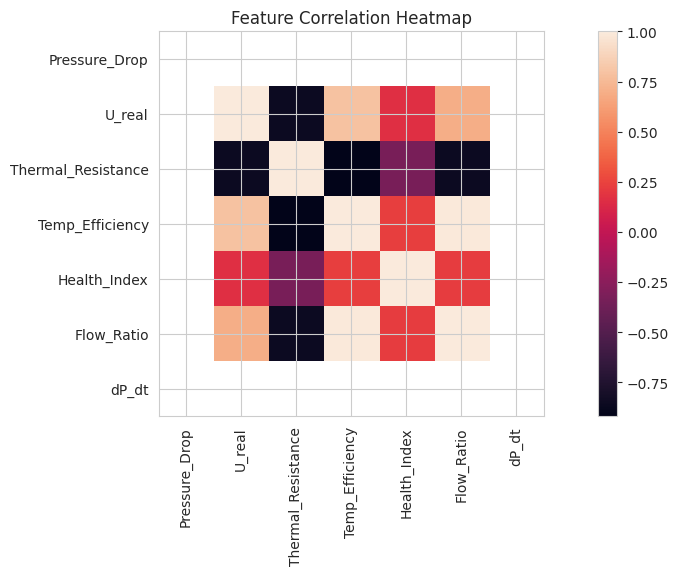

In [ ]:
df_features = pd.DataFrame(X_seq.reshape(-1, X_seq.shape[-1]), columns=features)
corr = df_features.corr()

plt.figure()
plt.imshow(corr)
plt.title("Feature Correlation Heatmap")
plt.xticks(range(len(features)), features, rotation=90)
plt.yticks(range(len(features)), features)
plt.colorbar()
plt.show()

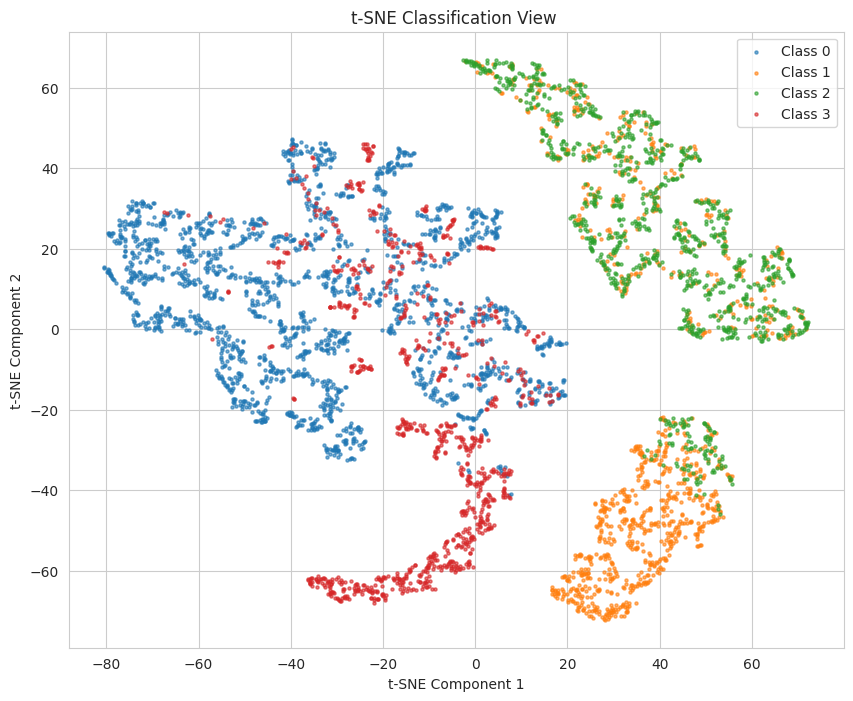

In [ ]:
# Flatten X_seq from (num_sequences, seq_len, num_features) to (num_sequences * seq_len, num_features)
num_sequences, current_seq_len, num_features = X_seq.shape
X_seq_flat = X_seq.reshape(-1, num_features)

# Convert X_seq_flat to a DataFrame with feature names before scaling to avoid UserWarning
X_seq_df = pd.DataFrame(X_seq_flat, columns=features)

# Scale the flattened sequence data using the already fitted scaler
X_scaled = scaler.transform(X_seq_df)

# Create expanded labels for each time step in the flattened sequence data
y_seq_expanded = np.repeat(y_seq, current_seq_len)

# Now, sample from the correctly scaled data and expanded labels
sample_idx = np.random.choice(len(X_scaled), 5000, replace=False)
X_sample = X_scaled[sample_idx]
y_sample = y_seq_expanded[sample_idx]

tsne = TSNE(n_components=2, perplexity=30, random_state=42) # Added random_state for reproducibility
X_tsne = tsne.fit_transform(X_sample)

plt.figure(figsize=(10, 8)) # Added figsize for better readability
for label in np.unique(y_sample):
    idx = np.where(y_sample == label)
    plt.scatter(X_tsne[idx, 0], X_tsne[idx, 1], label=f"Class {label}", s=5, alpha=0.6) # Added alpha

plt.title("t-SNE Classification View ")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend()
plt.grid(True) # Added grid
plt.show()

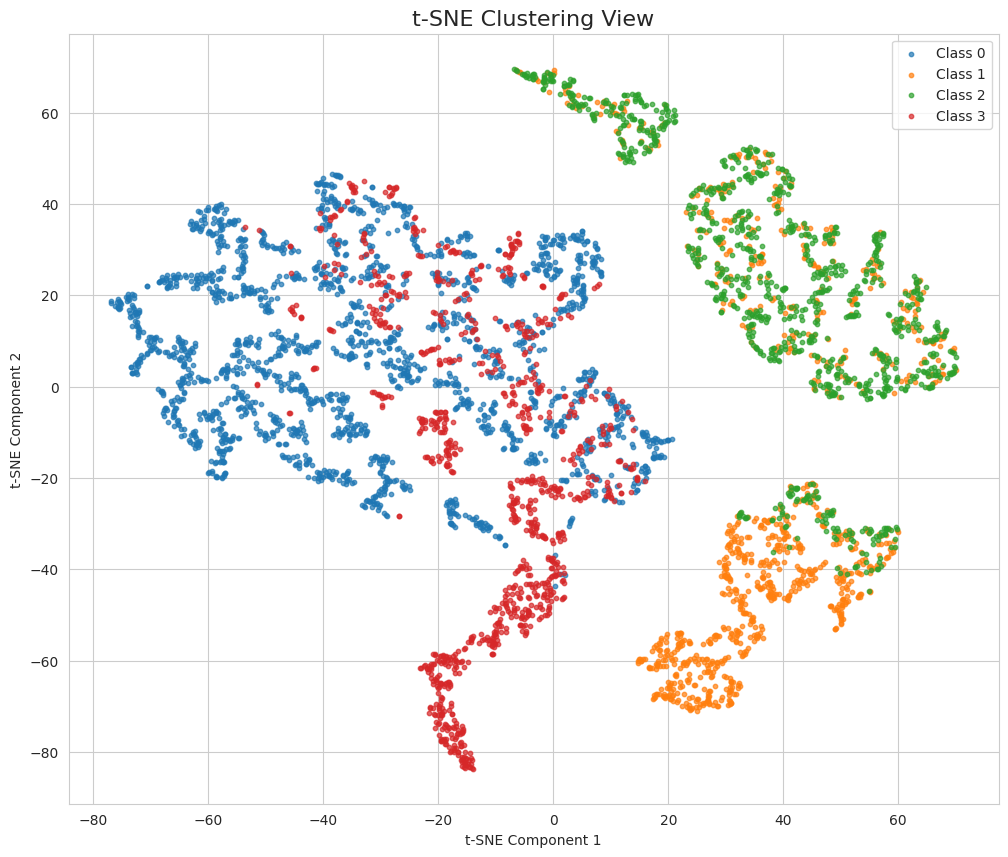

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# ---------------------------
# 1. Flatten sequence data
# ---------------------------
num_sequences, current_seq_len, num_features = X_seq.shape
X_seq_flat = X_seq.reshape(num_sequences * current_seq_len, num_features)

# ---------------------------
# 2. Convert to DataFrame before scaling
# ---------------------------
X_seq_df = pd.DataFrame(X_seq_flat, columns=features)

# ---------------------------
# 3. Scale using already-fitted scaler
# ---------------------------
X_scaled = scaler.transform(X_seq_df)

# ---------------------------
# 4. Expand labels for each time-step
# ---------------------------
y_seq_expanded = np.repeat(y_seq, current_seq_len)

# ---------------------------
# 5. Random sampling for t-SNE
# ---------------------------
sample_size = 5000 if len(X_scaled) >= 5000 else len(X_scaled)
sample_idx = np.random.choice(len(X_scaled), sample_size, replace=False)

X_sample = X_scaled[sample_idx]
y_sample = y_seq_expanded[sample_idx]

# ---------------------------
# 6. PCA before t-SNE → improves clustering + speed
# ---------------------------
pca = PCA(n_components=5) # Changed n_components from 30 to 5
X_pca = pca.fit_transform(X_sample)

# ---------------------------
# 7. t-SNE with stable hyperparameters
# ---------------------------
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",        # <- makes clusters stable
    random_state=42
)

X_tsne = tsne.fit_transform(X_pca)

# ---------------------------
# 8. Plot t-SNE clustering
# ---------------------------
plt.figure(figsize=(12, 10))

unique_labels = np.unique(y_sample)

for label in unique_labels:
    idx = np.where(y_sample == label)[0]
    plt.scatter(
        X_tsne[idx, 0],
        X_tsne[idx, 1],
        label=f"Class {label}",
        s=10,
        alpha=0.7
    )

plt.title("t-SNE Clustering View", fontsize=16)
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.legend()
plt.grid(True)
plt.show()

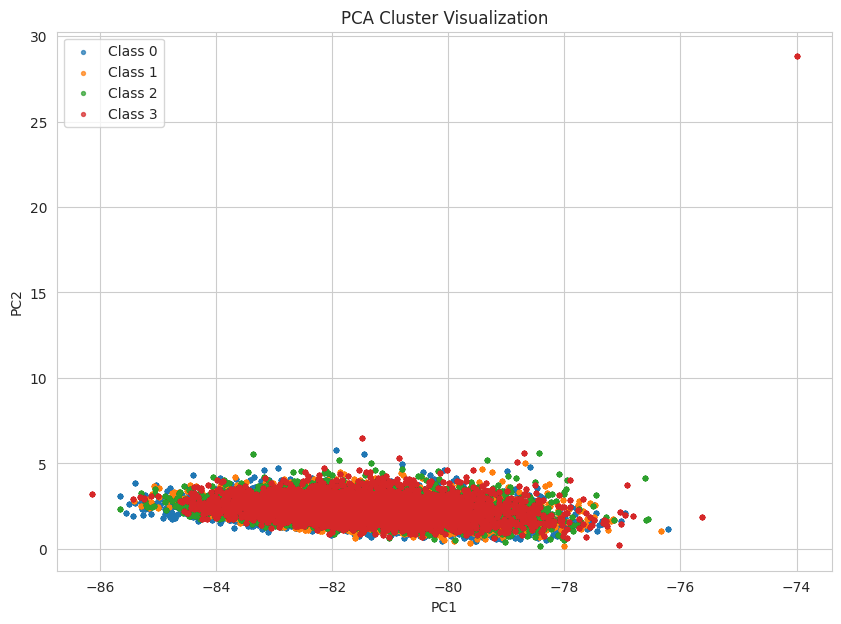

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))

for label in np.unique(y):
    idx = np.where(y == label)[0]
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=f"Class {label}", s=8, alpha=0.7)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Cluster Visualization")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
results_df = pd.DataFrame({
    "True_Label": y_true,
    "Predicted_Label": y_pred
})

for i in range(probabilities.shape[1]):
    results_df[f"Prob_Class_{i}"] = probabilities[:, i]

results_df.to_csv("/content/drive/MyDrive/Hybrid_Model_Validation_Results.csv", index=False)

print("Saved: Hybrid_Model_Validation_Results.csv")

Saved: Hybrid_Model_Validation_Results.csv


In [ ]:
import numpy as np

def create_sequences_for_pinn_fast(df, features, seq_len=20):

    # Convert once to numpy (VERY IMPORTANT)
    feature_array = df[features].to_numpy()

    # Create sliding windows (vectorized)
    from numpy.lib.stride_tricks import sliding_window_view
    X_all = sliding_window_view(feature_array, (seq_len, feature_array.shape[1]))
    X_all = X_all.squeeze(1)

    # Remove last incomplete window alignment
    X_all = X_all[:-1]

    # Create meta dataframe (vectorized slicing)
    meta_df = pd.DataFrame({
        "hot_inlet_temperature_k": df["Shell_In_Temp_C"].to_numpy()[seq_len:],
        "hot_outlet_temperature_k": df["Shell_Out_Temp_C"].to_numpy()[seq_len:],
        "cold_inlet_temperature_k": df["Tube_In_Temp_C"].to_numpy()[seq_len:],
        "cold_outlet_temperature_k": df["Tube_Out_Temp_C"].to_numpy()[seq_len:],
        "hot_outlet_mass_flow_kg_s": df["m_hot"].to_numpy()[seq_len:],
        "cold_outlet_mass_flow_kg_s": df["m_cold"].to_numpy()[seq_len:],
        "LMTD": df["LMTD"].to_numpy()[seq_len:]
    })

    return X_all, meta_df

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_tensor = torch.tensor(X_seq, dtype=torch.float32).to(device)

loader = DataLoader(
    TensorDataset(X_tensor),
    batch_size=512,
    shuffle=False
)

all_Q_pred = []

with torch.no_grad():
    for batch in loader:
        xb = batch[0]
        _, Q_pred = model(xb)
        all_Q_pred.extend(Q_pred.squeeze().cpu().numpy())

Q_pred_PINN = np.array(all_Q_pred)

In [ ]:
A = 374.5   # use your actual heat exchanger area
epsilon = 1e-6

# Call the function to create X_all and meta_df
X_all_pinn, meta_df = create_sequences_for_pinn_fast(df_all, features, seq_len)

LMTD_vals = meta_df["LMTD"].values
U_pred_PINN = Q_pred_PINN / (A * np.maximum(LMTD_vals, epsilon))

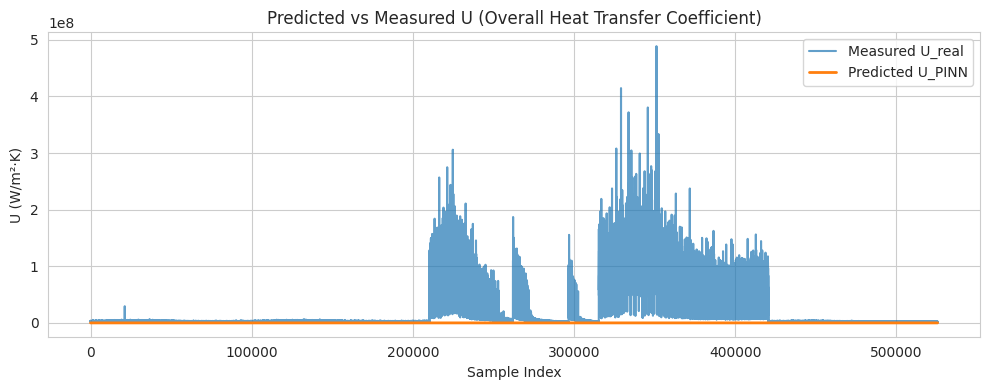

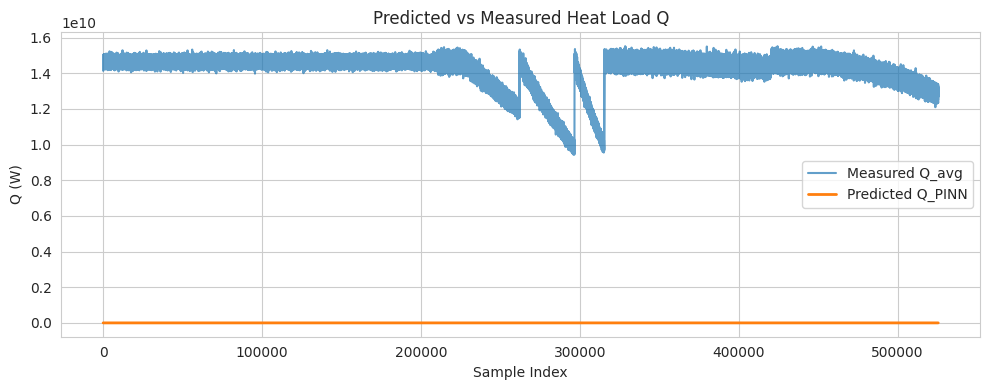

Industry_PINN_outputs.csv generated successfully.
   hot_inlet_temperature_k  hot_outlet_temperature_k  \
0                63.517289                 37.256044   
1                65.449961                 40.859583   
2                63.215376                 38.404009   
3                65.963578                 40.985503   
4                63.587166                 38.307651   

   cold_inlet_temperature_k  cold_outlet_temperature_k  \
0                 31.101931                  35.061667   
1                 32.753553                  36.638591   
2                 32.071183                  36.057022   
3                 31.111143                  35.156964   
4                 31.749573                  35.717280   

   hot_outlet_mass_flow_kg_s  cold_outlet_mass_flow_kg_s  Q_pred_PINN  \
0                125326.6496                 872733.7349   183.402145   
1                131597.7361                 874596.3656   183.402145   
2                131270.1073                 

In [ ]:
# Get the actual U_real and Q_avg values corresponding to the predicted outputs
U_real_actual = df_all["U_real"].values[seq_len:]
Q_avg_actual = df_all["Q_avg"].values[seq_len:]

pinn_outputs = meta_df.copy()

pinn_outputs["Q_pred_PINN"] = Q_pred_PINN
pinn_outputs["U_pred_PINN"] = U_pred_PINN

# Remove LMTD column if not needed
pinn_outputs = pinn_outputs.drop(columns=["LMTD"])

# Plotting
plt.figure(figsize=(10,4))
plt.plot(U_real_actual, label="Measured U_real", alpha=0.7)
plt.plot(pinn_outputs["U_pred_PINN"], label="Predicted U_PINN", lw=2)
plt.title("Predicted vs Measured U (Overall Heat Transfer Coefficient)")
plt.xlabel("Sample Index"); plt.ylabel("U (W/m²·K)")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

plt.figure(figsize=(10,4))
plt.plot(Q_avg_actual, label="Measured Q_avg", alpha=0.7)
plt.plot(pinn_outputs["Q_pred_PINN"], label="Predicted Q_PINN", lw=2)
plt.title("Predicted vs Measured Heat Load Q")
plt.xlabel("Sample Index"); plt.ylabel("Q (W)")
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()


pinn_outputs.to_csv("/content/drive/MyDrive/Industry_PINN_outputs.csv", index=False)

print("Industry_PINN_outputs.csv generated successfully.")
print(pinn_outputs.head())

In [ ]:
import torch
import numpy as np
import pandas as pd
from scipy.optimize import minimize

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.eval()

A = 374.5
Cp = 4180.0
Np = 6
u_min, u_max = 0.5, 6.0
EPS = 1e-6
min_flow = 1e-3

In [ ]:
def ntu_model(U, m_hot, m_cold, Th_in, Tc_in):

    C_hot = m_hot * Cp
    C_cold = m_cold * Cp

    C_min = min(C_hot, C_cold)
    C_max = max(C_hot, C_cold)

    Cr = C_min / (C_max + EPS)
    NTU = U * A / (C_min + EPS)

    if abs(1 - Cr) < 1e-6:
        eff = NTU / (1 + NTU)
    else:
        exp_term = np.exp(-NTU * (1 - Cr))
        eff = (1 - exp_term) / (1 - Cr * exp_term + EPS)

    Q = eff * C_min * (Th_in - Tc_in)

    Tc_out = Tc_in + Q / (C_cold + EPS)

    return Q, Tc_out

In [ ]:
seq_buffer = []
gamma_history = []
m_cold_control = []

u_prev = df_all["m_cold"].iloc[0]
setpoint = df_all[Tc_out].iloc[0]

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

A = 374.5        # m²
Cp = 4180.0      # J/kg.K
df = pd.read_csv("/content/drive/MyDrive/HX_Merged.csv")

feature_cols = [
    "hot_outlet_pressure_pa",
    "cold_outlet_pressure_pa",
    "hot_outlet_mass_flow_kg_s",
    "cold_inlet_mass_flow_kg_s",
    "cold_outlet_mass_flow_kg_s",
    "hot_inlet_temperature_k",
    "hot_outlet_temperature_k",
    "cold_inlet_temperature_k",
    "cold_outlet_temperature_k",
    "LMTD",
    "Flow_Ratio",
    "Temp_Efficiency",
    "dP_dt",
    "Health_Index"
]

feature_cols = [c for c in feature_cols if c in df.columns]

X = df[feature_cols].values
Q = df["Q_avg"].values.reshape(-1,1) # Changed 'Q_W' to 'Q_avg'
U = df["U_real"].values.reshape(-1,1)
LMTD = df["LMTD"].values.reshape(-1,1)

Device: cuda


In [ ]:
sc_X = StandardScaler()
sc_Q = StandardScaler()
sc_U = StandardScaler()

Xn = sc_X.fit_transform(X)
Qn = sc_Q.fit_transform(Q)
Un = sc_U.fit_transform(U)

In [ ]:
X_train, X_val, Q_train, Q_val, U_train, U_val, LMTD_train, LMTD_val = train_test_split(
    Xn, Qn, Un, LMTD, test_size=0.2, random_state=42
)

X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
Q_train = torch.tensor(Q_train, dtype=torch.float32).to(device)
U_train = torch.tensor(U_train, dtype=torch.float32).to(device)
LMTD_train = torch.tensor(LMTD_train, dtype=torch.float32).to(device)

X_val = torch.tensor(X_val, dtype=torch.float32).to(device)
Q_val = torch.tensor(Q_val, dtype=torch.float32).to(device)
U_val = torch.tensor(U_val, dtype=torch.float32).to(device)
LMTD_val = torch.tensor(LMTD_val, dtype=torch.float32).to(device)

In [ ]:
class HX_PINN(nn.Module):

    def __init__(self, in_dim, hidden=128):
        super().__init__()

        self.shared = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden//2),
            nn.Tanh()
        )

        self.q_head = nn.Linear(hidden//2, 1)
        self.u_head = nn.Linear(hidden//2, 1)

    def forward(self, x):

        f = self.shared(x)

        q_pred_n = self.q_head(f)   # normalized
        u_pred_n = self.u_head(f)

        return q_pred_n, u_pred_n

In [ ]:
pinn_reg_model = HX_PINN(X_train.shape[1]).to(device)

optimizer = optim.AdamW(pinn_reg_model.parameters(), lr=2e-3)
mse = nn.MSELoss()

lambda_phy = 0.05
lambda_max = 1.0
epochs = 200

best_loss = np.inf

for ep in range(epochs):

    pinn_reg_model.train()
    optimizer.zero_grad()

    q_pred_n, u_pred_n = pinn_reg_model(X_train)

    # Data losses
    loss_q = mse(q_pred_n, Q_train)
    loss_u = mse(u_pred_n, U_train)

    # Convert to REAL scale
    q_pred_real = torch.tensor(
        sc_Q.inverse_transform(q_pred_n.detach().cpu().numpy()),
        dtype=torch.float32
    ).to(device)

    u_pred_real = torch.tensor(
        sc_U.inverse_transform(u_pred_n.detach().cpu().numpy()),
        dtype=torch.float32
    ).to(device)

    # Physics model
    q_phys_real = u_pred_real * A * LMTD_train

    loss_phys = torch.mean((q_pred_real - q_phys_real)**2)

    total_loss = loss_q + 0.2*loss_u + lambda_phy * loss_phys

    total_loss.backward()
    torch.nn.utils.clip_grad_norm_(pinn_reg_model.parameters(), 5.0)
    optimizer.step()

    lambda_phy = min(lambda_max, lambda_phy * 1.01)

    if total_loss.item() < best_loss:
        best_loss = total_loss.item()
        torch.save(pinn_reg_model.state_dict(), "best_hx_pinn.pt")

    if ep % 25 == 0:
        print(f"Epoch {ep:03d} | Lq {loss_q:.3e} | Lu {loss_u:.3e} | Lphys {loss_phys:.3e}")

Epoch 000 | Lq 1.017e+00 | Lu 1.017e+00 | Lphys 5.035e+21
Epoch 025 | Lq 1.497e-01 | Lu 1.989e-01 | Lphys 2.326e+21
Epoch 050 | Lq 1.180e-01 | Lu 1.637e-01 | Lphys 8.395e+20
Epoch 075 | Lq 1.042e-01 | Lu 1.467e-01 | Lphys 7.750e+20
Epoch 100 | Lq 9.601e-02 | Lu 1.131e-01 | Lphys 4.020e+20
Epoch 125 | Lq 8.913e-02 | Lu 7.366e-02 | Lphys 1.697e+20
Epoch 150 | Lq 8.623e-02 | Lu 4.327e-02 | Lphys 6.753e+19
Epoch 175 | Lq 7.880e-02 | Lu 2.772e-02 | Lphys 3.989e+19


In [ ]:
# Fix: Initialize HX_PINN model and load its state_dict
pinn_reg_model_loaded = HX_PINN(X_train.shape[1]).to(device) # Re-instantiate HX_PINN
pinn_reg_model_loaded.load_state_dict(torch.load("best_hx_pinn.pt"))
pinn_reg_model_loaded.eval()

with torch.no_grad():
    q_pred_n, u_pred_n = pinn_reg_model_loaded(torch.tensor(Xn, dtype=torch.float32).to(device))

q_pred = sc_Q.inverse_transform(q_pred_n.cpu().numpy())
u_pred = sc_U.inverse_transform(u_pred_n.cpu().numpy())

In [ ]:
B11 = A * LMTD.flatten()
B12 = A * u_pred.flatten()

df["U_pred_PINN"] = u_pred
df["Q_pred_PINN"] = q_pred
df["B11_A_LMTD"] = B11
df["B12_A_U"] = B12

In [ ]:
mse_q = np.mean((df["Q_avg"].values - q_pred.flatten())**2)
mse_u = np.mean((df["U_real"].values - u_pred.flatten())**2)

r2_q = 1 - mse_q / np.var(df["Q_avg"].values)
r2_u = 1 - mse_u / np.var(df["U_real"].values)

print("MSE(Q):", mse_q, "R²(Q):", r2_q)
print("MSE(U):", mse_u, "R²(U):", r2_u)

MSE(Q): 7.0470304740335016e+16 R²(Q): 0.9254230081151501
MSE(U): 21264745524893.715 R²(U): 0.9783225341363199


In [ ]:
df.to_csv("/content/drive/MyDrive/HX_PINN_outputs.csv", index=False)
print("Saved → HX_PINN_outputs.csv")

Saved → HX_PINN_outputs.csv


R² (U): 0.9783
R² (Q): 0.9254


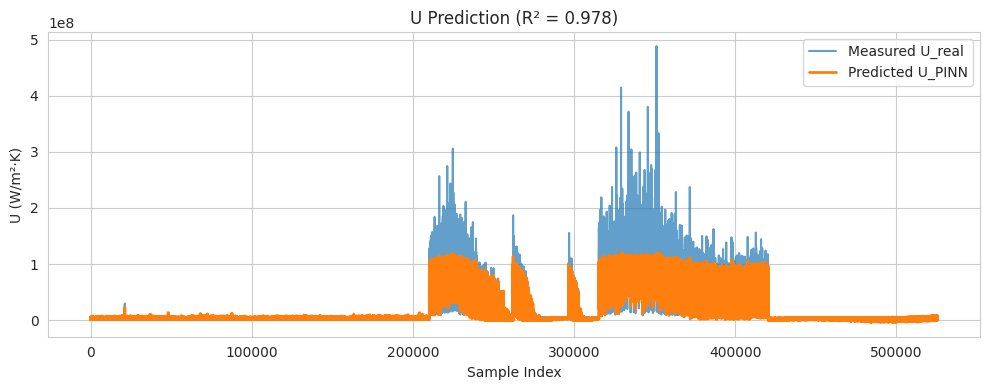

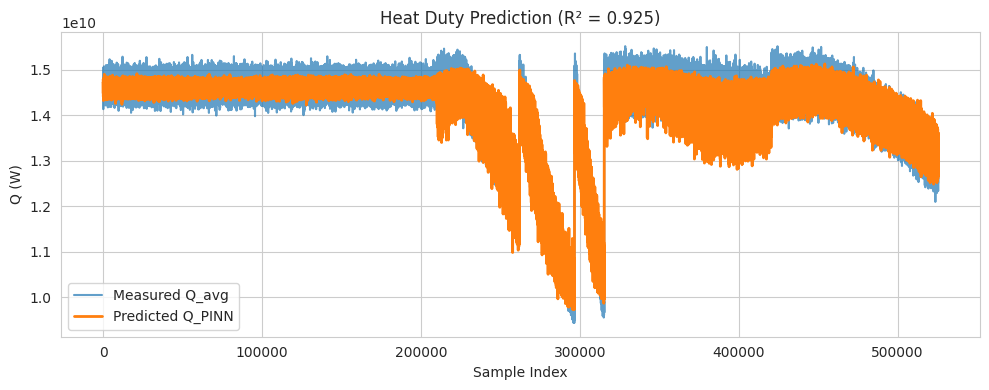

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# ------------------------------------------------
# 1️⃣ Load PINN outputs
# ------------------------------------------------
df = pd.read_csv("/content/drive/MyDrive/HX_PINN_outputs.csv")

# ------------------------------------------------
# 2️⃣ Extract signals
# ------------------------------------------------
U_real = df["U_real"].values
U_pred = df["U_pred_PINN"].values

Q_real = df["Q_avg"].values # Changed 'Q_W' to 'Q_avg'
Q_pred = df["Q_pred_PINN"].values

# ------------------------------------------------
# 3️⃣ Compute R²
# ------------------------------------------------
r2_u = r2_score(U_real, U_pred)
r2_q = r2_score(Q_real, Q_pred)

print(f"R² (U): {r2_u:.4f}")
print(f"R² (Q): {r2_q:.4f}")

# ------------------------------------------------
# 4️⃣ Plot U (Overall Heat Transfer Coefficient)
# ------------------------------------------------
plt.figure(figsize=(10,4))
plt.plot(U_real, label="Measured U_real", alpha=0.7)
plt.plot(U_pred, label="Predicted U_PINN", linewidth=2)
plt.title(f"U Prediction (R² = {r2_u:.3f})")
plt.xlabel("Sample Index")
plt.ylabel("U (W/m²·K)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------
# 5️⃣ Plot Q (Heat Duty)
# ------------------------------------------------
plt.figure(figsize=(10,4))
plt.plot(Q_real, label="Measured Q_avg", alpha=0.7) # Changed label to Q_avg
plt.plot(Q_pred, label="Predicted Q_PINN", linewidth=2)
plt.title(f"Heat Duty Prediction (R² = {r2_q:.3f})")
plt.xlabel("Sample Index")
plt.ylabel("Q (W)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

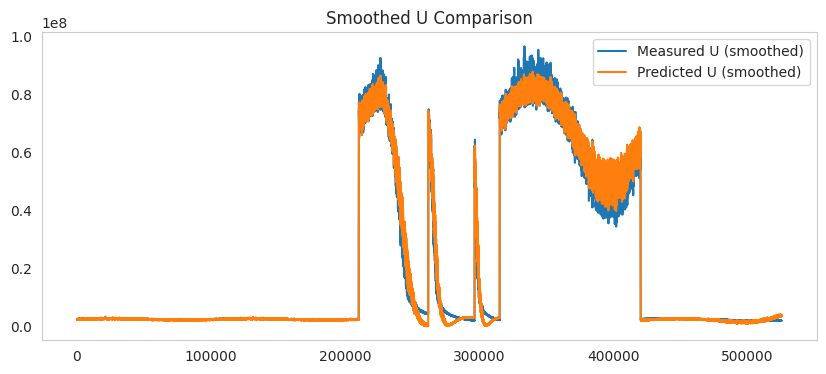

In [ ]:
import matplotlib.pyplot as plt

# Extract signals after df is loaded in the previous cell
U_real = df["U_real"].values
U_pred = df["U_pred_PINN"].values

window = 50

plt.figure(figsize=(10,4))
plt.plot(pd.Series(U_real).rolling(window).mean(), label="Measured U (smoothed)")
plt.plot(pd.Series(U_pred).rolling(window).mean(), label="Predicted U (smoothed)")
plt.title("Smoothed U Comparison")
plt.legend(); plt.grid(); plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/drive/MyDrive/HX_PINN_outputs.csv")

A = 374.5
dt = 1
# Prediction horizon
Np = 10
Nc = 5

# Control limits
u_min = df["m_cold"].min() # Changed to 'm_cold'
u_max = df["m_cold"].max() # Changed to 'm_cold'

du_max = 5000     # max change per step

# Weights
Q_weight = 1.0
R_weight = 0.001

In [ ]:
Q_ref = df["Q_avg"].mean() * 0.95  # desired 95% heat duty

In [ ]:
u_history = []
Q_history = []
Q_predicted = []

u_current = df["m_cold"].iloc[0] # Changed column name to 'm_cold'
Q_current = df["Q_pred_PINN"].iloc[0]

for k in range(len(df)-Np):

    # Get local sensitivity from PINN B-matrix
    B = df["B12_A_U"].iloc[k]   # ∂Q/∂LMTD approx control gain

    # Build prediction matrices
    Phi = np.zeros((Np, Nc))
    for i in range(Np):
        for j in range(Nc):
            if i >= j:
                Phi[i,j] = B

    # Cost function matrices
    Q_bar = Q_weight * np.eye(Np)
    R_bar = R_weight * np.eye(Nc)

    # Reference trajectory
    ref_vec = np.ones(Np) * Q_ref

    # Free response
    F = np.ones(Np) * Q_current

    # Solve quadratic problem analytically
    H = Phi.T @ Q_bar @ Phi + R_bar
    f = Phi.T @ Q_bar @ (F - ref_vec)

    try:
        du_opt = -np.linalg.inv(H) @ f
    except:
        du_opt = np.zeros(Nc)

    du = du_opt[0]

    # Constraint handling
    du = np.clip(du, -du_max, du_max)
    u_new = np.clip(u_current + du, u_min, u_max)

    # Update predicted Q using PINN sensitivity
    Q_new = Q_current + B * (u_new - u_current)

    # Store
    u_history.append(u_new)
    Q_history.append(Q_current)
    Q_predicted.append(Q_new)

    # Update for next step
    u_current = u_new
    Q_current = Q_new

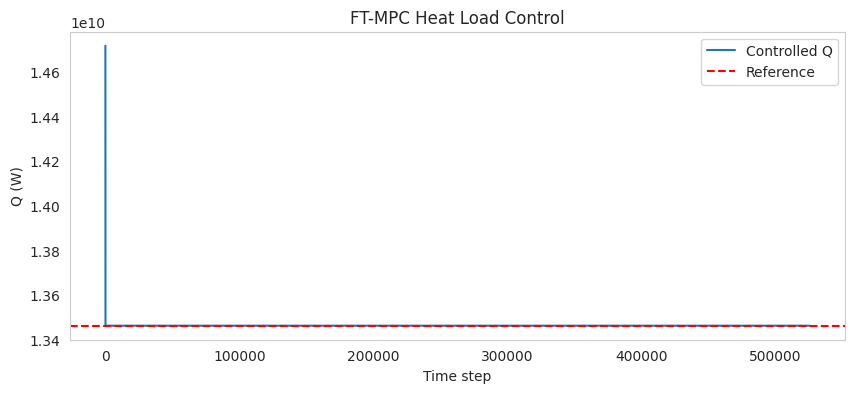

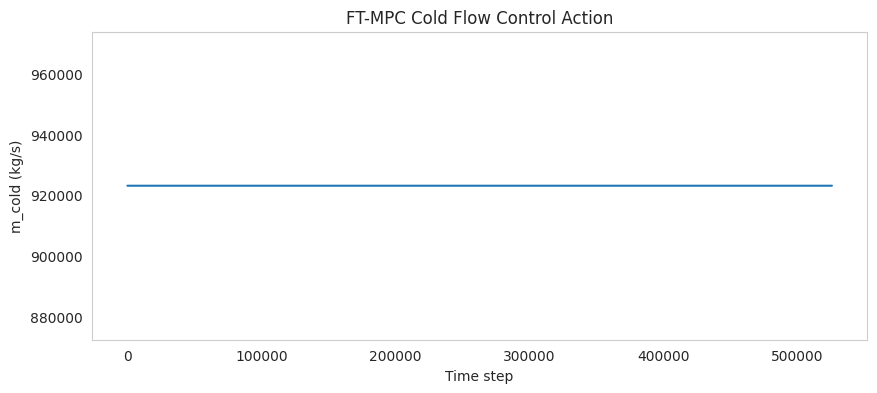

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(Q_history, label="Controlled Q")
plt.axhline(Q_ref, color='r', linestyle='--', label="Reference")
plt.title("FT-MPC Heat Load Control")
plt.xlabel("Time step")
plt.ylabel("Q (W)")
plt.legend(); plt.grid(); plt.show()

plt.figure(figsize=(10,4))
plt.plot(u_history)
plt.title("FT-MPC Cold Flow Control Action")
plt.xlabel("Time step")
plt.ylabel("m_cold (kg/s)")
plt.grid(); plt.show()

In [ ]:
ftmpc_df = pd.DataFrame({
    "Controlled_Q": Q_history,
    "Predicted_Q": Q_predicted,
    "Control_m_cold": u_history
})

ftmpc_df.to_csv("/content/drive/MyDrive/HX_FT_MPC_results.csv", index=False)

print("HX_FT_MPC_results.csv saved.")

HX_FT_MPC_results.csv saved.


In [ ]:
Cp = 4180.0
A = 374.5

def process_model(U, m_hot, m_cold, Th_in, Tc_in):

    C_hot = m_hot * Cp
    C_cold = m_cold * Cp

    C_min = min(C_hot, C_cold)
    C_max = max(C_hot, C_cold)

    Cr = C_min / (C_max + 1e-6)
    NTU = U * A / (C_min + 1e-6)

    if abs(1-Cr) < 1e-6:
        eff = NTU / (1+NTU)
    else:
        eff = (1 - np.exp(-NTU*(1-Cr))) / \
              (1 - Cr*np.exp(-NTU*(1-Cr)) + 1e-6)

    Q = eff * C_min * (Th_in - Tc_in)

    Tc_out = Tc_in + Q / (C_cold + 1e-6)

    return Q, Tc_out

In [ ]:
from scipy.optimize import minimize

Np = 8
u_min = df["m_cold"].min() # Changed column name to 'm_cold'
u_max = df["m_cold"].max() # Changed column name to 'm_cold'

u_current = df["m_cold"].iloc[0] # Changed column name to 'm_cold'
Q_ref = df["Q_avg"].mean() * 0.95 # Changed column name to 'Q_avg'

u_history = []
Q_history = []

# Directly assign column names to avoid reliance on 'found'
_Th_in_col = "Shell_In_Temp_C"
_Tc_in_col = "Tube_In_Temp_C"

for k in range(len(df)-Np):

    U_k = df["U_pred_PINN"].iloc[k]
    m_hot_k = df["m_hot"].iloc[k]
    Th_in_k = df[_Th_in_col].iloc[k] # Use the variable _Th_in_col
    Tc_in_k = df[_Tc_in_col].iloc[k] # Use the variable _Tc_in_col

    def cost(u_seq):

        cost_val = 0
        u_prev = u_current

        for j in range(len(u_seq)):

            Qp, _ = process_model(
                U_k,
                m_hot_k,
                u_seq[j],
                Th_in_k,
                Tc_in_k
            )

            cost_val += (Qp - Q_ref)**2 + 1e-6*(u_seq[j] - u_prev)**2
            u_prev = u_seq[j]

        return cost_val

    u0 = np.ones(Np) * u_current
    bounds = [(u_min, u_max)] * Np

    res = minimize(cost, u0, method='SLSQP', bounds=bounds)

    if res.success:
        u_new = res.x[0]
    else:
        u_new = u_current

    Q_new, _ = process_model(
        U_k,
        m_hot_k,
        u_new,
        Th_in_k,
        Tc_in_k
    )

    u_history.append(u_new)
    Q_history.append(Q_new)

    u_current = u_new

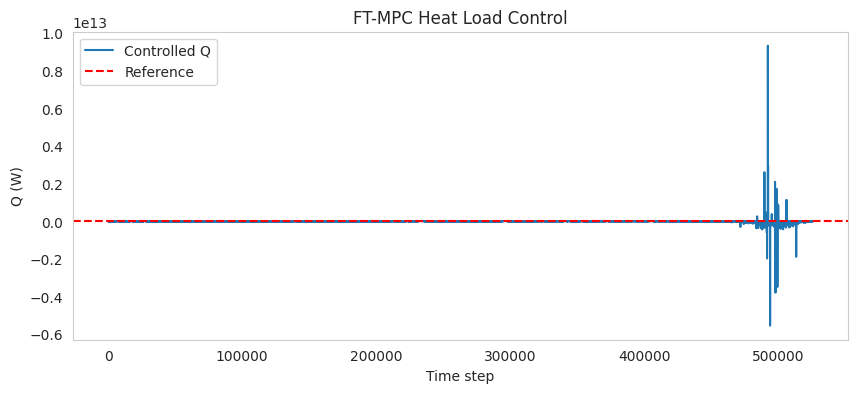

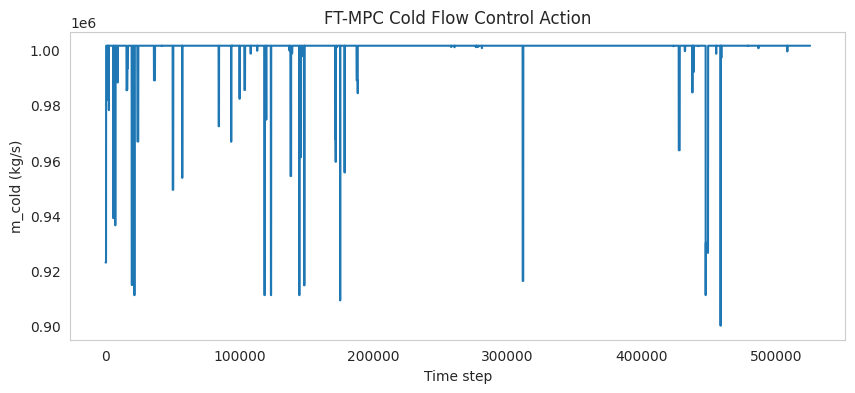

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(Q_history, label="Controlled Q")
plt.axhline(Q_ref, color='r', linestyle='--', label="Reference")
plt.title("FT-MPC Heat Load Control")
plt.xlabel("Time step")
plt.ylabel("Q (W)")
plt.legend(); plt.grid(); plt.show()

plt.figure(figsize=(10,4))
plt.plot(u_history)
plt.title("FT-MPC Cold Flow Control Action")
plt.xlabel("Time step")
plt.ylabel("m_cold (kg/s)")
plt.grid(); plt.show()

Sample-level RUL saved → HX_RUL_samples.csv
Sequence-level RUL saved → HX_RUL_sequences.csv


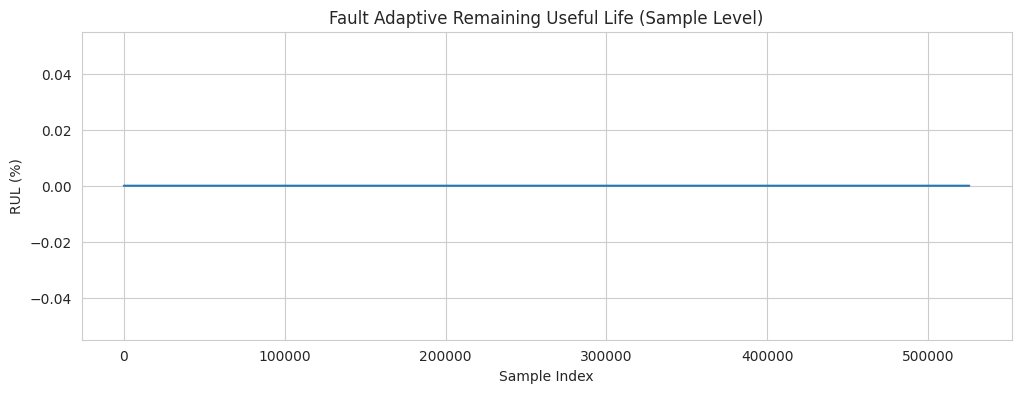

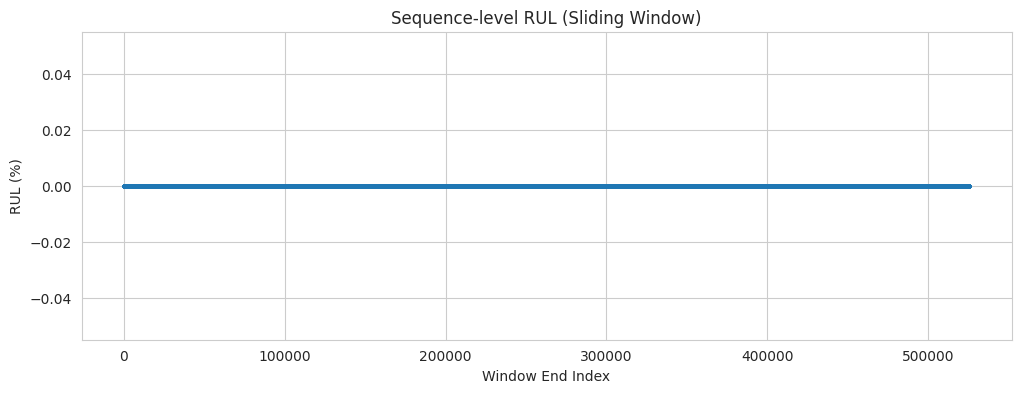

In [ ]:
# ================================================================
# Fault-Adaptive Remaining Useful Life (RUL) Estimation
# Heat Exchanger Hybrid Monitoring System
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===============================
# Load dataset
# ===============================
df = pd.read_csv("/content/drive/MyDrive/HX_PINN_outputs.csv")

# Re-create 'Condition' column from 'label' column using the global label_map
# Assuming label_map is available from previous cells.
# Invert the label_map to get a mapping from int to string
label_map = {"Normal":0, "Fouling":1, "Leakage":2, "Flow_Blockage":3} # Redefine if not in scope
reverse_label_map = {v: k for k, v in label_map.items()}
df["Condition"] = df["label"].map(reverse_label_map)

# ===============================
# Sequence parameters (same as model)
# ===============================
SEQ_LEN = 10
STEP = 5
SMOOTH_WINDOW = 30

# ===============================
# Fault degradation multipliers
# ===============================
RATES = {
    "Normal": 1.0,
    "Fouling": 0.85,
    "Leakage": 0.55,
    "Blockage": 0.35
}

# ===============================
# Create Pressure Drop Feature
# ===============================
if "Pressure_Drop" not in df.columns:
    df["Pressure_Drop"] = df["DP_Shell_kgfpcm2"] + df["DP_Tube_kgfpcm2"]

# ===============================
# Health Index Calculation
# ===============================

# Normalize pressure drop
pd_norm = (df["Pressure_Drop"] - df["Pressure_Drop"].min()) / \
          (df["Pressure_Drop"].max() - df["Pressure_Drop"].min() + 1e-9)

# Health index (inverse of degradation)
HI = 1 - pd_norm

df["Health_Index"] = HI

# ===============================
# Normalize Health Index
# ===============================

hi_norm = (HI - HI.min()) / (HI.max() - HI.min() + 1e-9)

# ===============================
# Fault Adaptive RUL
# ===============================

conditions = df["Condition"].astype(str).values

rul_samples = np.array([
    RATES.get(cond, 0.8) * h * 100
    for cond, h in zip(conditions, hi_norm)
])

# ===============================
# Smooth RUL for realistic curve
# ===============================

rul_smooth = (
    pd.Series(rul_samples)
    .rolling(window=SMOOTH_WINDOW, center=True, min_periods=1)
    .mean()
)

rul_smooth = np.clip(rul_smooth, 0, 100)

df["RUL_%"] = rul_smooth

# ===============================
# Save sample-level RUL
# ===============================

df.to_csv("HX_RUL_samples.csv", index=False)

print("Sample-level RUL saved \u2192 HX_RUL_samples.csv")

# ===============================
# Sequence-level RUL
# ===============================

# Sliding windows
end_indices = np.arange(SEQ_LEN, len(df), STEP)

seq_rul = rul_smooth.iloc[end_indices].values

seq_df = pd.DataFrame({
    "end_index": end_indices,
    "Condition": df["Condition"].iloc[end_indices].values,
    "RUL_%": seq_rul
})

seq_df.to_csv("HX_RUL_sequences.csv", index=False)

print("Sequence-level RUL saved \u2192 HX_RUL_sequences.csv")

# ===============================
# Plot Sample-level RUL
# ===============================

plt.figure(figsize=(12,4))
plt.plot(df.index, df["RUL_%"] , linewidth=1.5)
plt.title("Fault Adaptive Remaining Useful Life (Sample Level)")
plt.xlabel("Sample Index")
plt.ylabel("RUL (%)")
plt.grid(True)
plt.show()

# ===============================
# Plot Sequence-level RUL
# ===============================

plt.figure(figsize=(12,4))
plt.plot(seq_df["end_index"], seq_df["RUL_%"] , '.', markersize=4)
plt.title("Sequence-level RUL (Sliding Window)")
plt.xlabel("Window End Index")
plt.ylabel("RUL (%)")
plt.grid(True)
plt.show()

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import TensorDataset, DataLoader

# Compute class weights for the 'label' column in base_df
# Assuming base_df is representative of the label distribution
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(base_df["label"]),
    y=base_df["label"]
)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("Class weights computed:", class_weights)

Class weights computed: tensor([1.2500, 1.2500, 1.2500, 0.6250], device='cuda:0')


Now, let's define a function to train and save our BiLSTM models. This function will take care of creating DataLoaders, setting up the optimizer and loss function, running the training loop, and saving the best model's state dictionary.

In [ ]:
def train_and_save_model(model_instance, df_data, features_list, scaler_instance, class_weights, filename, epochs=25, batch_size=256):

    # Prepare data for training
    X_scaled = scaler_instance.transform(df_data[features_list].fillna(0))
    y_labels = df_data["label"].values

    X_tensor = torch.tensor(X_scaled, dtype=torch.float32).unsqueeze(1).to(device) # Add sequence length dimension
    y_tensor = torch.tensor(y_labels, dtype=torch.long).to(device)

    dataset = TensorDataset(X_tensor, y_tensor)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = optim.Adam(model_instance.parameters(), lr=0.001)

    best_loss = float('inf')
    model_instance.train()

    print(f"\nStarting training for {filename}...")
    for epoch in range(epochs):
        total_loss = 0
        for xb, yb in dataloader:
            optimizer.zero_grad()
            outputs = model_instance(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_instance.parameters(), 5.0)
            optimizer.step()
            total_loss += loss.item()

        avg_loss = total_loss / len(dataloader)
        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

        if avg_loss < best_loss:
            best_loss = avg_loss
            torch.save(model_instance.state_dict(), f"/content/drive/MyDrive/{filename}")
            print(f"Model saved to /content/drive/MyDrive/{filename}")

    print(f"Training finished for {filename}.")

Now we will train and save the baseline model (`model_base`).

In [ ]:
# Train and save the baseline model
# model_base is already instantiated in Xcx0gK1a08qs
train_and_save_model(model_base, base_df, feature_cols_base, sc_base, class_weights, "bilstm_base.pt")


Starting training for bilstm_base.pt...
Epoch 1/25, Loss: 0.3767
Model saved to /content/drive/MyDrive/bilstm_base.pt
Epoch 2/25, Loss: 0.2928
Model saved to /content/drive/MyDrive/bilstm_base.pt
Epoch 3/25, Loss: 0.2850
Model saved to /content/drive/MyDrive/bilstm_base.pt
Epoch 4/25, Loss: 0.2812
Model saved to /content/drive/MyDrive/bilstm_base.pt
Epoch 5/25, Loss: 0.2795
Model saved to /content/drive/MyDrive/bilstm_base.pt
Epoch 6/25, Loss: 0.2785
Model saved to /content/drive/MyDrive/bilstm_base.pt
Epoch 7/25, Loss: 0.2778
Model saved to /content/drive/MyDrive/bilstm_base.pt
Epoch 8/25, Loss: 0.2772
Model saved to /content/drive/MyDrive/bilstm_base.pt
Epoch 9/25, Loss: 0.2769
Model saved to /content/drive/MyDrive/bilstm_base.pt
Epoch 10/25, Loss: 0.2762
Model saved to /content/drive/MyDrive/bilstm_base.pt
Epoch 11/25, Loss: 0.2763
Epoch 12/25, Loss: 0.2757
Model saved to /content/drive/MyDrive/bilstm_base.pt
Epoch 13/25, Loss: 0.2756
Model saved to /content/drive/MyDrive/bilstm_ba

Next, we will train and save the hybrid model (`model_hyb`).

In [ ]:
# Train and save the hybrid model
# model_hyb is already instantiated in Xcx0gK1a08qs
train_and_save_model(model_hyb, hyb_df, feature_cols_hyb, sc_hyb, class_weights, "bilstm_hybrid.pt")


Starting training for bilstm_hybrid.pt...
Epoch 1/25, Loss: 0.3407
Model saved to /content/drive/MyDrive/bilstm_hybrid.pt
Epoch 2/25, Loss: 0.2397
Model saved to /content/drive/MyDrive/bilstm_hybrid.pt
Epoch 3/25, Loss: 0.2125
Model saved to /content/drive/MyDrive/bilstm_hybrid.pt
Epoch 4/25, Loss: 0.2020
Model saved to /content/drive/MyDrive/bilstm_hybrid.pt
Epoch 5/25, Loss: 0.1975
Model saved to /content/drive/MyDrive/bilstm_hybrid.pt
Epoch 6/25, Loss: 0.1950
Model saved to /content/drive/MyDrive/bilstm_hybrid.pt
Epoch 7/25, Loss: 0.1934
Model saved to /content/drive/MyDrive/bilstm_hybrid.pt
Epoch 8/25, Loss: 0.1919
Model saved to /content/drive/MyDrive/bilstm_hybrid.pt
Epoch 9/25, Loss: 0.1911
Model saved to /content/drive/MyDrive/bilstm_hybrid.pt
Epoch 10/25, Loss: 0.1897
Model saved to /content/drive/MyDrive/bilstm_hybrid.pt
Epoch 11/25, Loss: 0.1891
Model saved to /content/drive/MyDrive/bilstm_hybrid.pt
Epoch 12/25, Loss: 0.1884
Model saved to /content/drive/MyDrive/bilstm_hybr

Device: cuda
Baseline: (525600, 35)
Hybrid: (525600, 39)
Baseline features: ['Pressure_Drop', 'LMTD', 'Q_W', 'Overall_U', 'Flow_Ratio', 'dP_dt', 'Health_Index']
Hybrid features: ['Pressure_Drop', 'LMTD', 'Q_W', 'Overall_U', 'Flow_Ratio', 'dP_dt', 'Health_Index', 'U_pred_PINN', 'Q_pred_PINN']
Baseline F1: 0.8912081488499966
Hybrid F1: 0.9304547370669003


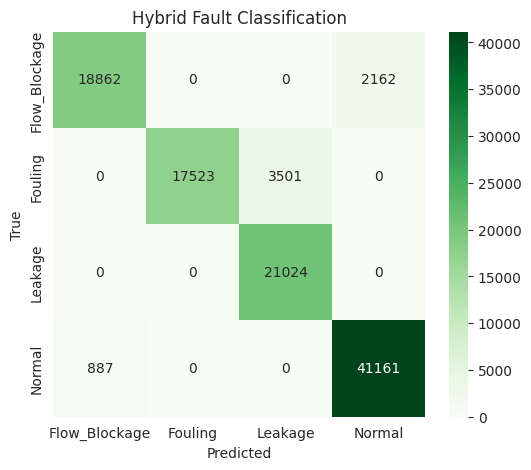

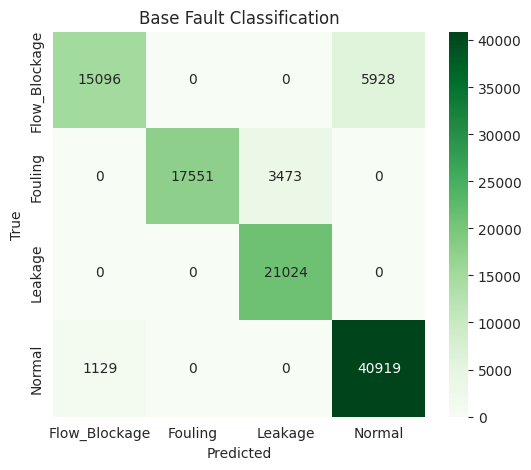

In [ ]:
# =========================================================
# HYBRID HEAT EXCHANGER SYSTEM
# Fault Classification + RUL Comparison
# =========================================================

import os, warnings, joblib
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor

sns.set_style("whitegrid")
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# =========================================================
# 1 LOAD DATA
# =========================================================

base_df = pd.read_csv("/content/drive/MyDrive/HX_Merged.csv")
hyb_df  = pd.read_csv("/content/drive/MyDrive/HX_PINN_outputs.csv")

print("Baseline:", base_df.shape)
print("Hybrid:", hyb_df.shape)

# Define label map (assuming it's consistent with earlier steps)
label_map = {"Normal":0, "Fouling":1, "Leakage":2, "Flow_Blockage":3}
reverse_label_map = {v: k for k, v in label_map.items()}

# Re-create 'Condition' column from 'label' column for both dataframes
base_df["Condition"] = base_df["label"].map(reverse_label_map)
hyb_df["Condition"]  = hyb_df["label"].map(reverse_label_map)

# =========================================================
# 2 FEATURE ENGINEERING
# =========================================================

# Pressure drop
base_df["Pressure_Drop"] = base_df["DP_Shell_kgfpcm2"] + base_df["DP_Tube_kgfpcm2"]
hyb_df["Pressure_Drop"]  = hyb_df["DP_Shell_kgfpcm2"] + hyb_df["DP_Tube_kgfpcm2"]

# LMTD
DT1 = base_df["Shell_In_Temp_C"] - base_df["Tube_Out_Temp_C"]
DT2 = base_df["Shell_Out_Temp_C"] - base_df["Tube_In_Temp_C"]
base_df["LMTD"] = (DT1-DT2) / (np.log((DT1+1e-6)/(DT2+1e-6)))

DT1h = hyb_df["Shell_In_Temp_C"] - hyb_df["Tube_Out_Temp_C"]
DT2h = hyb_df["Shell_Out_Temp_C"] - hyb_df["Tube_In_Temp_C"]
hyb_df["LMTD"] = (DT1h-DT2h) / (np.log((DT1h+1e-6)/(DT2h+1e-6)))

# Heat duty
base_df["Q_W"] = base_df["Heat_Duty_kcalph"] * 1.163
hyb_df["Q_W"]  = hyb_df["Heat_Duty_kcalph"] * 1.163

# Flow ratio
base_df["Flow_Ratio"] = base_df["Shell_Flow_kgph"] / (base_df["Tube_Flow_kgph"]+1e-6)
hyb_df["Flow_Ratio"]  = hyb_df["Shell_Flow_kgph"] / (hyb_df["Tube_Flow_kgph"]+1e-6)

# Pressure drop rate
base_df["dP_dt"] = base_df["Pressure_Drop"].diff().fillna(0)
hyb_df["dP_dt"]  = hyb_df["Pressure_Drop"].diff().fillna(0)

# Health index
pd_norm = (base_df["Pressure_Drop"]-base_df["Pressure_Drop"].min())/(base_df["Pressure_Drop"].max()-base_df["Pressure_Drop"].min()+1e-9)
base_df["Health_Index"] = 1-pd_norm

pd_norm_h = (hyb_df["Pressure_Drop"]-hyb_df["Pressure_Drop"].min())/(hyb_df["Pressure_Drop"].max()-hyb_df["Pressure_Drop"].min()+1e-9)
hyb_df["Health_Index"] = 1-pd_norm_h

# =========================================================
# 3 FEATURE LISTS
# =========================================================

feature_cols_base = [
"Pressure_Drop","LMTD","Q_W","Overall_U",
"Flow_Ratio","dP_dt","Health_Index"
]

feature_cols_hyb = feature_cols_base + [
"U_pred_PINN","Q_pred_PINN"
]

feature_cols_base = [c for c in feature_cols_base if c in base_df.columns]
feature_cols_hyb  = [c for c in feature_cols_hyb if c in hyb_df.columns]

print("Baseline features:",feature_cols_base)
print("Hybrid features:",feature_cols_hyb)

# =========================================================
# 4 LABEL ENCODING
# =========================================================

le = LabelEncoder()

base_df["label"] = le.fit_transform(base_df["Condition"])
hyb_df["label"]  = le.transform(hyb_df["Condition"])

classes = le.classes_
n_classes = len(classes)

# =========================================================
# 5 TRAIN TEST SPLIT
# =========================================================

sss = StratifiedShuffleSplit(n_splits=1,test_size=0.2,random_state=42)

_,test_idx = next(sss.split(base_df,base_df["label"]))

# =========================================================
# 6 SCALING
# =========================================================

sc_base = StandardScaler()
sc_hyb  = StandardScaler()

sc_base.fit(base_df[feature_cols_base])
sc_hyb.fit(hyb_df[feature_cols_hyb])

# =========================================================
# 7 TENSOR PREPARATION
# =========================================================

def prepare_tensor(df,cols,scaler):

    X = scaler.transform(df[cols].fillna(0))
    return torch.tensor(X,dtype=torch.float32).to(device)

Xb = prepare_tensor(base_df.loc[test_idx],feature_cols_base,sc_base)
Xh = prepare_tensor(hyb_df.loc[test_idx],feature_cols_hyb,sc_hyb)

y_true = base_df.loc[test_idx,"label"].values

# =========================================================
# 8 MODEL ARCHITECTURE
# =========================================================

class Attention(nn.Module):

    def __init__(self,dim):
        super().__init__()

        self.proj = nn.Sequential(
            nn.Linear(dim,dim),
            nn.Tanh(),
            nn.Linear(dim,1)
        )

    def forward(self,h):

        w = torch.softmax(self.proj(h),dim=1)
        return torch.sum(w*h,dim=1)


class BiLSTM_Attn(nn.Module):

    def __init__(self,n_feat,n_hidden,n_classes):

        super().__init__()

        self.lstm = nn.LSTM(
            n_feat,
            n_hidden,
            batch_first=True,
            bidirectional=True
        )

        self.attn = Attention(n_hidden*2)

        self.fc = nn.Linear(n_hidden*2,n_classes)

    def forward(self,x):

        o,_ = self.lstm(x)
        ctx = self.attn(o)

        return self.fc(ctx)

# =========================================================
# 9 LOAD TRAINED MODELS
# =========================================================

model_base = BiLSTM_Attn(len(feature_cols_base),64,n_classes).to(device)
model_hyb  = BiLSTM_Attn(len(feature_cols_hyb),64,n_classes).to(device)

# !!! USER: Replace these paths with your model file paths !!!
model_base.load_state_dict(torch.load("/content/drive/MyDrive/bilstm_base.pt",map_location=device))
model_hyb.load_state_dict(torch.load("/content/drive/MyDrive/bilstm_hybrid.pt",map_location=device))

model_base.eval()
model_hyb.eval()

# =========================================================
# 10 PREDICTIONS
# =========================================================

with torch.no_grad():

    base_logits = model_base(Xb.unsqueeze(1))
    hyb_logits  = model_hyb(Xh.unsqueeze(1))

    base_preds = torch.argmax(base_logits,1).cpu().numpy()
    hyb_preds  = torch.argmax(hyb_logits,1).cpu().numpy()

# =========================================================
# 11 METRICS
# =========================================================

prec_b,rec_b,f1_b,_ = precision_recall_fscore_support(y_true,base_preds)
prec_h,rec_h,f1_h,_ = precision_recall_fscore_support(y_true,hyb_preds)

print("Baseline F1:",np.mean(f1_b))
print("Hybrid F1:",np.mean(f1_h))

# =========================================================
# 12 CONFUSION MATRIX
# =========================================================

plt.figure(figsize=(6,5))

sns.heatmap(
confusion_matrix(y_true,hyb_preds),
annot=True,
fmt="d",
cmap="Greens",
xticklabels=classes,
yticklabels=classes
)

plt.title("Hybrid Fault Classification")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()
plt.figure(figsize=(6,5))

sns.heatmap(
confusion_matrix(y_true,base_preds),
annot=True,
fmt="d",
cmap="Greens",
xticklabels=classes,
yticklabels=classes
)

plt.title("Base Fault Classification")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.show()


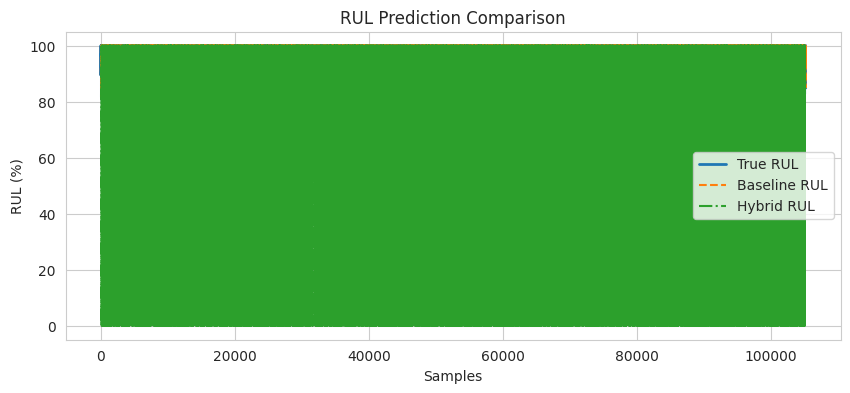

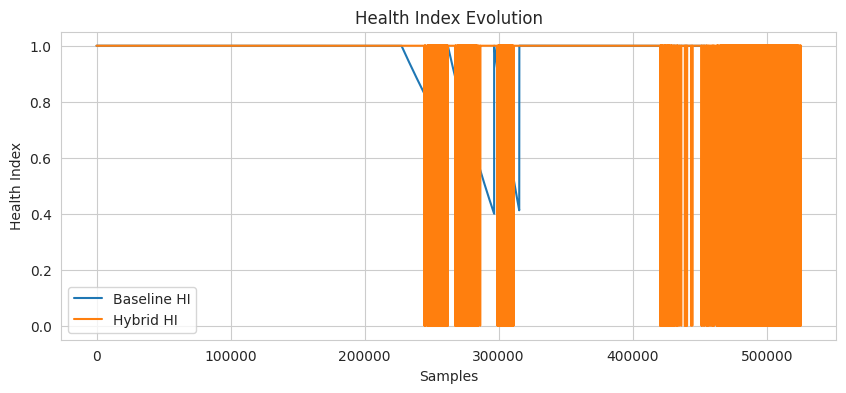

In [ ]:
# =========================================================
# PHYSICS BASED HEALTH INDEX
# =========================================================

# Pressure drop
base_df["Pressure_Drop"] = base_df["DP_Shell_kgfpcm2"] + base_df["DP_Tube_kgfpcm2"]
hyb_df["Pressure_Drop"]  = hyb_df["DP_Shell_kgfpcm2"] + hyb_df["DP_Tube_kgfpcm2"]

# Thermal reference values
U_clean = base_df["Overall_U"].max()
U_min   = base_df["Overall_U"].min()

# Pressure reference values
DP_design = base_df["Pressure_Drop"].min()
DP_max    = base_df["Pressure_Drop"].max()

# =========================
# BASELINE HEALTH INDEX
# =========================

HI_thermal_base = (base_df["Overall_U"]-U_min)/(U_clean-U_min+1e-9)

HI_pressure_base = 1-(base_df["Pressure_Drop"]-DP_design)/(DP_max-DP_design+1e-9)

base_df["Health_Index"] = 0.6*HI_thermal_base + 0.4*HI_pressure_base
base_df["Health_Index"] = base_df["Health_Index"].clip(0,1)

# =========================
# HYBRID HEALTH INDEX
# =========================

if "U_pred_PINN" in hyb_df.columns:
    U_used = hyb_df["U_pred_PINN"]
else:
    U_used = hyb_df["Overall_U"]

HI_thermal_hyb = (U_used-U_min)/(U_clean-U_min+1e-9)

HI_pressure_hyb = 1-(hyb_df["Pressure_Drop"]-DP_design)/(DP_max-DP_design+1e-9)

hyb_df["Health_Index"] = 0.6*HI_thermal_hyb + 0.4*HI_pressure_hyb
hyb_df["Health_Index"] = hyb_df["Health_Index"].clip(0,1)

# =========================
# RUL
# =========================

base_df["RUL_pct"] = base_df["Health_Index"]*100
hyb_df["RUL_pct"]  = hyb_df["Health_Index"]*100
# =========================================================
# RUL PLOTS
# =========================================================

plt.figure(figsize=(10,4))

plt.plot(true_rul,label="True RUL",linewidth=2)
plt.plot(base_rul_pred,label="Baseline RUL",linestyle="--")
plt.plot(hyb_rul_pred,label="Hybrid RUL",linestyle="-.")

plt.legend()
plt.title("RUL Prediction Comparison")
plt.xlabel("Samples")
plt.ylabel("RUL (%)")

plt.show()

# =========================================================
# HEALTH INDEX COMPARISON
# =========================================================

plt.figure(figsize=(10,4))

plt.plot(base_df["Health_Index"].values,label="Baseline HI")
plt.plot(hyb_df["Health_Index"].values,label="Hybrid HI")

plt.legend()
plt.title("Health Index Evolution")

plt.xlabel("Samples")
plt.ylabel("Health Index")

plt.show()

In [ ]:
# ======================================
# Robust RUL Estimation for HE System
# ======================================

# Pressure Drop
df["Pressure_Drop"] = df["DP_Shell_kgfpcm2"] + df["DP_Tube_kgfpcm2"]

# Fill missing values
df["Pressure_Drop"] = df["Pressure_Drop"].fillna(method="ffill").fillna(method="bfill")

# Normalize pressure drop
pd_min = df["Pressure_Drop"].min()
pd_max = df["Pressure_Drop"].max()

if abs(pd_max - pd_min) < 1e-6:
    print("⚠️ Pressure drop constant → using fallback HI")
    df["Health_Index"] = 1.0
else:
    df["Health_Index"] = 1 - (df["Pressure_Drop"] - pd_min) / (pd_max - pd_min)

# Clip values
df["Health_Index"] = df["Health_Index"].clip(0,1)

# Compute RUL
df["RUL_pct"] = df["Health_Index"] * 100

print(df[["Pressure_Drop","Health_Index","RUL_pct"]].head())

⚠️ Pressure drop constant → using fallback HI
   Pressure_Drop  Health_Index  RUL_pct
0           0.33           1.0    100.0
1           0.33           1.0    100.0
2           0.33           1.0    100.0
3           0.33           1.0    100.0
4           0.33           1.0    100.0


In [ ]:
# =========================================================
# ADD MPC OUTPUTS TO DATAFRAME
# =========================================================

# Convert lists to arrays
u_history = np.array(u_history)
Q_history = np.array(Q_history)

# Create new dataframe columns
df["m_cold_control"] = np.nan # Changed column name to 'm_cold_control'
df["Q_MPC"] = np.nan

# Align lengths (MPC runs until len(df)-Np)
df.loc[:len(u_history)-1, "m_cold_control"] = u_history
df.loc[:len(Q_history)-1, "Q_MPC"] = Q_history

# =========================================================
# SAVE UPDATED DATASET
# =========================================================

save_path = "/content/drive/MyDrive/HX_PINN_MPC_outputs.csv"

df.to_csv(save_path, index=False)

print("FT-MPC outputs saved successfully")
print("File:", save_path)

FT-MPC outputs saved successfully
File: /content/drive/MyDrive/HX_PINN_MPC_outputs.csv


Loaded: (525600, 45)

===== PERFORMANCE COMPARISON =====
PID MAE : 6.858848130584154
FT-MPC MAE : 5.596285784655817
PID RMSE : 156.33201124261723
FT-MPC RMSE : 34.12279546002392
FT-MPC improvement: 78.17286735531884 %


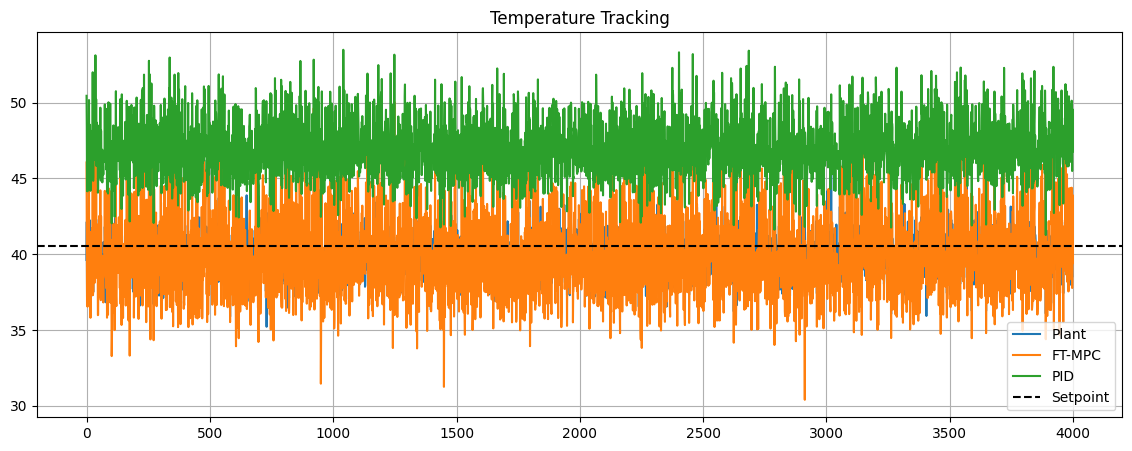

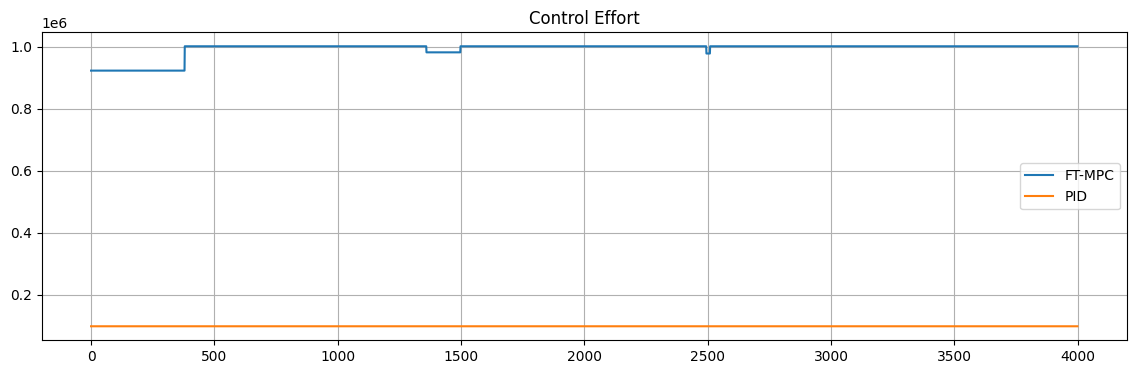

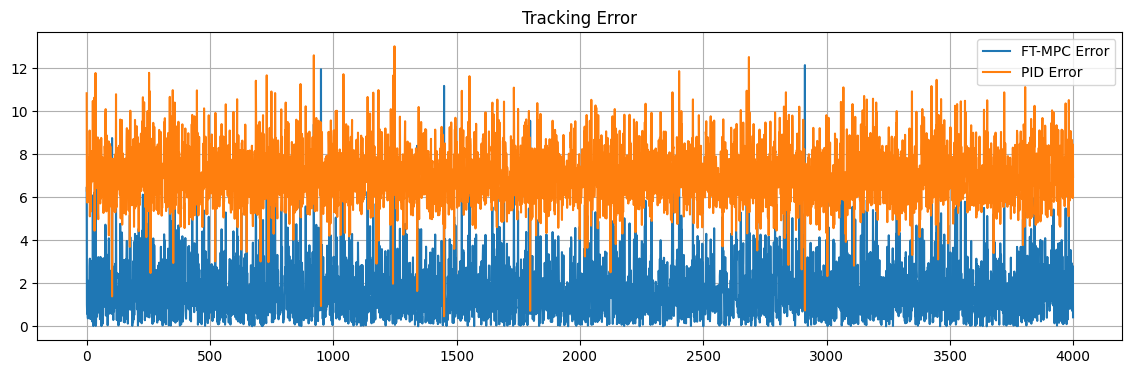

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# 1 LOAD DATA
# ============================================================================
DATA_PATH = "/content/drive/MyDrive/HX_PINN_MPC_outputs.csv"

df = pd.read_csv(DATA_PATH)

df = df.ffill().fillna(0)

print("Loaded:", df.shape)


# ============================================================================
# 2 HEAT EXCHANGER PROCESS MODEL
# ============================================================================
Cp = 4180
A = 374.5

def process_model(U, m_hot, m_cold, Th_in, Tc_in):

    C_hot = m_hot * Cp
    C_cold = m_cold * Cp

    C_min = min(C_hot, C_cold)
    C_max = max(C_hot, C_cold)

    Cr = C_min / (C_max + 1e-6)

    NTU = U * A / (C_min + 1e-6)

    if abs(1-Cr) < 1e-6:
        eff = NTU/(1+NTU)
    else:
        eff = (1-np.exp(-NTU*(1-Cr))) / (1-Cr*np.exp(-NTU*(1-Cr)) + 1e-6)

    Q = eff * C_min * (Th_in - Tc_in)

    Th_out = Th_in - Q/(C_hot + 1e-6)

    return Q, Th_out


# ============================================================================
# 3 FT-MPC TEMPERATURE
# ============================================================================
T_hot_pred = []

for i in range(len(df)):

    U = df["U_pred_PINN"].iloc[i]
    m_hot = df["m_hot"].iloc[i]
    m_cold = df["m_cold_control"].iloc[i]

    Th_in = df["Shell_In_Temp_C"].iloc[i]
    Tc_in = df["Tube_In_Temp_C"].iloc[i]

    Q, Th_out = process_model(U,m_hot,m_cold,Th_in,Tc_in)

    T_hot_pred.append(Th_out)

df["T_hot_pred"] = T_hot_pred


# ============================================================================
# 4 PID CONTROLLER
# ============================================================================
class PID:

    def __init__(self,Kp,Ki,Kd,umin,umax):

        self.Kp=Kp
        self.Ki=Ki
        self.Kd=Kd

        self.umin=umin
        self.umax=umax

        self.integral=0
        self.prev_err=0

    def compute(self,sp,pv,dt):

        e = sp - pv

        self.integral += e*dt

        derivative = (e-self.prev_err)/dt

        u = self.Kp*e + self.Ki*self.integral + self.Kd*derivative

        u_sat = max(self.umin, min(self.umax, u))

        self.prev_err = e

        return u_sat


# ============================================================================
# 5 SETPOINT
# ============================================================================
T_hot_sp = df["Shell_Out_Temp_C"].mean()

pid = PID(0.3,0.08,0.02,
          df["m_cold"].min(),
          df["m_cold"].max())


# ============================================================================
# 6 RUN PID USING PROCESS MODEL
# ============================================================================
T_hot_pid = []
u_pid_list = []

T_current = df["Shell_Out_Temp_C"].iloc[0]

for i in range(len(df)):

    U = df["U_pred_PINN"].iloc[i]
    m_hot = df["m_hot"].iloc[i]

    Th_in = df["Shell_In_Temp_C"].iloc[i]
    Tc_in = df["Tube_In_Temp_C"].iloc[i]

    u_pid = pid.compute(T_hot_sp, T_current, 1)

    Q_pid, T_next = process_model(U,m_hot,u_pid,Th_in,Tc_in)

    T_hot_pid.append(T_next)
    u_pid_list.append(u_pid)

    T_current = T_next

df["T_hot_pid"] = T_hot_pid
df["u_pid"] = u_pid_list


# ============================================================================
# 7 PERFORMANCE METRICS
# ============================================================================
df["err_pid"] = abs(df["T_hot_pid"] - df["Shell_Out_Temp_C"])
df["err_mpc"] = abs(df["T_hot_pred"] - df["Shell_Out_Temp_C"])

PID_MAE = df["err_pid"].mean()
MPC_MAE = df["err_mpc"].mean()

PID_RMSE = np.sqrt((df["err_pid"]**2).mean())
MPC_RMSE = np.sqrt((df["err_mpc"]**2).mean())

print("\n===== PERFORMANCE COMPARISON =====")

print("PID MAE :", PID_MAE)
print("FT-MPC MAE :", MPC_MAE)

print("PID RMSE :", PID_RMSE)
print("FT-MPC RMSE :", MPC_RMSE)

improvement = (PID_RMSE - MPC_RMSE)/PID_RMSE*100

print("FT-MPC improvement:", improvement,"%")



# ============================================================================
# 8 PLOTS
# ============================================================================

df_plot = df.iloc[:4000]

plt.figure(figsize=(14,5))

plt.plot(df_plot["Shell_Out_Temp_C"],label="Plant")

plt.plot(df_plot["T_hot_pred"],label="FT-MPC")

plt.plot(df_plot["T_hot_pid"],label="PID")

plt.axhline(T_hot_sp,linestyle="--",color="black",label="Setpoint")

plt.legend()
plt.grid()
plt.title("Temperature Tracking")

plt.show()


plt.figure(figsize=(14,4))

plt.plot(df_plot["m_cold_control"],label="FT-MPC")

plt.plot(df_plot["u_pid"],label="PID")

plt.legend()
plt.grid()
plt.title("Control Effort")

plt.show()


plt.figure(figsize=(14,4))

plt.plot(df_plot["err_mpc"],label="FT-MPC Error")

plt.plot(df_plot["err_pid"],label="PID Error")

plt.legend()
plt.grid()
plt.title("Tracking Error")

plt.show()


# ============================================================================
# 9 SAVE RESULTS
# ============================================================================
SAVE_PATH = "/content/drive/MyDrive/FTMPC_vs_PID_results.xlsx"

df.to_excel(SAVE_PATH,index=False)

print("Saved:", SAVE_PATH)

In [ ]:
# ========================================================================
# 🔥 Unified Maintenance Prediction System
#     (PINN + FT-MPC based Fault, Health and RUL)
# ========================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


# ============================================================
# 1 PATHS
# ============================================================

DATA_PATH = "/content/drive/MyDrive/HX_PINN_MPC_outputs.csv"
OUTDIR = "/content/drive/MyDrive"
FINAL_REPORT = "/content/drive/MyDrive/HX_Maintenance_System_Output.xlsx"

os.makedirs(OUTDIR, exist_ok=True)


# ============================================================
# 2 LOAD DATA
# ============================================================

df = pd.read_csv(DATA_PATH)

df = df.ffill().fillna(0)

print("Loaded:", df.shape)


# ============================================================
# 3 FAULT INDEX (Tracking error based)
# ============================================================

# Temperature tracking error
hot_error = np.abs(df["Shell_Out_Temp_C"] - df["Shell_In_Temp_C"])
cold_error = np.abs(df["Tube_Out_Temp_C"] - df["Tube_In_Temp_C"])

err = hot_error + cold_error

err_norm = (err - err.min())/(err.max()-err.min()+1e-6)

control_norm = (df["m_cold_control"] - df["m_cold_control"].min()) / \
               (df["m_cold_control"].max()-df["m_cold_control"].min()+1e-6)

df["Fault_Level"] = 0.7*err_norm + 0.3*control_norm
df["Fault_Level"] = df["Fault_Level"].clip(0,1)


# ============================================================
# 4 HEALTH INDEX (Thermal degradation)
# ============================================================

U_clean = df["U_pred_PINN"].max()
U_min = df["U_pred_PINN"].min()

HI_thermal = (df["U_pred_PINN"] - U_min)/(U_clean-U_min+1e-9)

DP = df["DP_Shell_kgfpcm2"] + df["DP_Tube_kgfpcm2"]

DP_design = DP.min()
DP_max = DP.max()

HI_pressure = 1-(DP-DP_design)/(DP_max-DP_design+1e-9)

df["Health_Index"] = 0.6*HI_thermal + 0.4*HI_pressure

df["Health_Index"] = df["Health_Index"].clip(0,1)


# Smooth health
df["Health_Smooth"] = df["Health_Index"].rolling(20,min_periods=1).mean()


# ============================================================
# 5 RUL ESTIMATION
# ============================================================

RUL_MAX = 200

fault_factor = 1 - df["Fault_Level"]

base_rul = df["Health_Smooth"] * RUL_MAX

df["RUL"] = base_rul * fault_factor

df["RUL"] = df["RUL"].clip(0,RUL_MAX)

df["RUL_norm"] = df["RUL"]/RUL_MAX


# ============================================================
# 6 FAULT TYPE CLASSIFICATION
# ============================================================

def classify_fault(f):

    if f < 0.2:
        return "No Fault"

    elif f < 0.4:
        return "Mild Fouling"

    elif f < 0.6:
        return "Flow Blockage"

    elif f < 0.8:
        return "Leakage"

    else:
        return "Severe Thermal Fault"


df["Fault_Type"] = df["Fault_Level"].apply(classify_fault)


# ============================================================
# 7 MAINTENANCE DECISION
# ============================================================

def maintenance_state(fault,rul):

    if fault>0.7 or rul<0.2:
        return "CRITICAL"

    elif fault>0.5 or rul<0.5:
        return "WARNING"

    else:
        return "NORMAL"


df["Maintenance_State"] = [
    maintenance_state(f,r)
    for f,r in zip(df["Fault_Level"],df["RUL_norm"])
]


# ============================================================
# 8 CLUSTERING (Fault pattern discovery)
# ============================================================

features = df[[
    "Fault_Level",
    "Health_Smooth",
    "RUL_norm",
    "m_cold_control"
]]

scaled = StandardScaler().fit_transform(features)

pca = PCA(n_components=2)

p2 = pca.fit_transform(scaled)

kmeans = KMeans(n_clusters=4,random_state=42,n_init=10)

df["Cluster"] = kmeans.fit_predict(scaled)


plt.figure(figsize=(8,6))

plt.scatter(p2[:,0],p2[:,1],
            c=df["Cluster"],
            cmap="viridis",
            alpha=0.6)

plt.title("Fault Clusters")
plt.xlabel("PCA-1")
plt.ylabel("PCA-2")

plt.grid(True)

plt.savefig(f"{OUTDIR}/fault_clusters.png",dpi=150)

plt.close()


# ============================================================
# 9 PLOTS
# ============================================================

df_plot = df.iloc[:5000]

plt.figure(figsize=(12,5))

plt.plot(df_plot["Health_Smooth"],label="Health")
plt.plot(df_plot["RUL_norm"],label="RUL")
plt.plot(df_plot["Fault_Level"],label="Fault")

plt.legend()
plt.grid(True)

plt.title("Health-RUL-Fault Trend")

plt.savefig(f"{OUTDIR}/health_rul_fault.png",dpi=150)

plt.close()


plt.figure(figsize=(12,4))

plt.plot(df_plot["m_cold_control"],
         label="FT-MPC Control")

plt.legend()

plt.grid(True)

plt.title("FT-MPC Control Signal")

plt.savefig(f"{OUTDIR}/mpc_control.png",dpi=150)

plt.close()


# ============================================================
# 10 SAVE FINAL REPORT
# ============================================================

report_cols = [

"Shell_In_Temp_C",
"Shell_Out_Temp_C",
"Tube_In_Temp_C",
"Tube_Out_Temp_C",

"m_cold_control",
"Q_MPC",
"U_pred_PINN",

"Fault_Level",
"Fault_Type",

"Health_Index",
"Health_Smooth",

"RUL",
"RUL_norm",

"Maintenance_State",
"Cluster"
]

df[report_cols].to_excel(FINAL_REPORT,index=False)

print("\nFINAL REPORT SAVED:",FINAL_REPORT)

df.tail()

Loaded: (525600, 45)

FINAL REPORT SAVED: /content/drive/MyDrive/HX_Maintenance_System_Output.xlsx


,Time_hr,Shell_In_Temp_C,Shell_Out_Temp_C,Tube_In_Temp_C,Tube_Out_Temp_C,Shell_Flow_kgph,Tube_Flow_kgph,Heat_Duty_kcalph,Overall_U,DP_Shell_kgfpcm2,...,m_cold_MPC,Q_MPC,m_cold_control,Fault_Level,Health_Smooth,RUL,RUL_norm,Fault_Type,Maintenance_State,Cluster
525595,8759.583333,65.315448,40.853990,31.748381,37.782956,120459.9335,512704.9799,3093956.938,532.4,0.14,...,1001599.107,1.589084e+10,1001599.107,0.399889,0.441853,53.032245,0.265161,Mild Fouling,WARNING,0
525596,8759.666667,65.282045,43.738829,31.810108,37.564206,131630.4255,517462.4722,2977529.841,532.4,0.14,...,1001599.107,1.589084e+10,1001599.107,0.346872,0.441825,57.713620,0.288568,Mild Fouling,WARNING,0
525597,8759.750000,65.095846,41.849333,30.828452,36.634318,124571.4929,523719.5591,3040645.460,532.4,0.14,...,1001599.107,1.589084e+10,1001599.107,0.375961,0.442051,55.171378,0.275857,Mild Fouling,WARNING,0
525598,8759.833333,64.374402,41.148303,32.187769,37.973427,122603.6659,516792.6542,2989985.228,532.4,0.14,...,1001599.107,1.589084e+10,1001599.107,0.375288,0.442353,55.268649,0.276343,Mild Fouling,WARNING,0
525599,8759.916667,65.423873,42.846717,32.092865,37.864340,126156.3224,518180.1186,2990663.551,532.4,0.14,...,1001599.107,1.589084e+10,1001599.107,0.364297,0.441931,56.187405,0.280937,Mild Fouling,WARNING,0


In [ ]:
# ============================================================
# 8 CLUSTERING (Fault pattern discovery)
# ============================================================

features = df[[
    "Fault_Level",
    "Health_Smooth",
    "RUL_norm",
    "m_cold_control"
]]

scaled = StandardScaler().fit_transform(features)

pca = PCA(n_components=2)

p2 = pca.fit_transform(scaled)

kmeans = KMeans(n_clusters=4,random_state=42,n_init=10)

df["Cluster"] = kmeans.fit_predict(scaled)


plt.figure(figsize=(8,6))

plt.scatter(p2[:,0],p2[:,1],
            c=df["Cluster"],
            cmap="viridis",
            alpha=0.6)

plt.title("Fault Clusters")
plt.xlabel("PCA-1")
plt.ylabel("PCA-2")

plt.grid(True)

plt.savefig(f"{OUTDIR}/fault_clusters.png",dpi=150)

plt.close()


# ============================================================
# 9 PLOTS
# ============================================================

df_plot = df.iloc[:5000]

plt.figure(figsize=(12,5))

plt.plot(df_plot["Health_Smooth"],label="Health")
plt.plot(df_plot["RUL_norm"],label="RUL")
plt.plot(df_plot["Fault_Level"],label="Fault")

plt.legend()
plt.grid(True)

plt.title("Health-RUL-Fault Trend")

plt.savefig(f"{OUTDIR}/health_rul_fault.png",dpi=150)

plt.close()


plt.figure(figsize=(12,4))

plt.plot(df_plot["m_cold_control"],
         label="FT-MPC Control")

plt.legend()

plt.grid(True)

plt.title("FT-MPC Control Signal")

plt.savefig(f"{OUTDIR}/mpc_control.png",dpi=150)

plt.close()